# Task 3 — Gender and Usage Classification

**Selected models:** the single Gender MixUp 0.20 / 30-epoch refit and the single teacher-only Usage E8 refit. Final assessment is recorded in [07_task3_part2_final_evaluation.ipynb](07_task3_part2_final_evaluation.ipynb).

**Replay:** **Run All** reads the saved records and rebuilds the analysis below. It does not start training or new inference.

**Training code map:** the companion notebooks launch training; the Python files below implement it.

| Layer | Exact implementation | Responsibility |
|---|---|---|
| Experiment declarations | [config.py](../src/fashion/train/config.py): `Task3BaselineConfig`; [task3_experiments.py](../src/fashion/train/task3_experiments.py); target-specific modules in [src/fashion/train/](../src/fashion/train/) | Define the baseline and each child recipe, including folds, loss, augmentation and epoch budget. |
| Neural model definitions | [model.py](../src/fashion/train/model.py): `Task3BaselineCNN`, `Task3GeM3CNN` and alternative architectures | Build the scratch CNNs. The final Usage model uses average pooling; the final Gender model uses GeM pooling. |
| Run entry points | [task3_training/README.md](task3_training/README.md); [baseline runner](task3_training/smallcnn_baseline_training.ipynb); [child runner](task3_training/smallcnn_child_experiments.ipynb) | Map the original experiment notebooks and their local or Colab runtime. Each runner sets up data, calls its training module and saves outputs. |
| Baseline and child orchestration | [task3_baseline.py](../src/fashion/train/task3_baseline.py): `run_task3_baseline_cv`, `run_task3_baseline_fold`; [task3_experiments.py](../src/fashion/train/task3_experiments.py): `run_task3_child_cv` | Fit the declared recipes on the saved development folds and record fold predictions and metrics. |
| Gender follow-up orchestration | [MixUp](../src/fashion/train/task3_gender_mixup.py): `run_gender_mixup_screen`; [SAM25 screen](../src/fashion/train/task3_gender_sam25.py): `run_gender_sam25_screen`; [five-fold MixUp](../src/fashion/train/task3_gender_mixup_cv.py): `run_gender_mixup_cv` | Test regularisation on the corrected-label basis, then compare the fixed MixUp and SAM25 recipes on all five development folds. |
| Usage expansion orchestration | [120 additions](../src/fashion/train/task3_usage_expanded.py): `run_expanded_usage`; [687 additions](../src/fashion/train/task3_usage_expanded_v2.py): `run_expanded_usage_v2`; [MixUp + SAM](../src/fashion/train/task3_usage_mixup_sam.py): `run_usage_mixup_sam`; [replacement follow-up](../src/fashion/train/task3_usage_replaced_v3.py) | Select each approved dataset version explicitly and compare predictions on the retained teacher folds. |
| Optimisation and input processing | [task3_baseline.py](../src/fashion/train/task3_baseline.py); [mixup.py](../src/fashion/train/mixup.py); [sam.py](../src/fashion/train/sam.py); [images.py](../src/fashion/data/images.py) | Run the fold training loop, apply the requested MixUp/SAM policy, and use the shared image transform. Full-development refits have their own loops in the modules below. |
| Full-development refits | [Gender runner](task3_training/gender_mixup_refit.ipynb) → [task3_gender_mixup_refit.py](../src/fashion/train/task3_gender_mixup_refit.py): `run_gender_mixup_refit`; [Usage E1 runner](task3_training/usage_e1_refit.ipynb) → [task3_usage_e1_refit.py](../src/fashion/train/task3_usage_e1_refit.py): `run_usage_e1_refit`; [Usage E8 runner](task3_training/usage_e8_refit.ipynb) → [task3_usage_e8_refit.py](../src/fashion/train/task3_usage_e8_refit.py): `run_usage_e8_refit` | Train fresh weights after fixing the recipes: 30 epochs for Gender and Usage, with no validation-based checkpoint selection. E1 is the Usage comparison; E8 is the accepted model. |
| Saved training outputs | [registry.py](../src/fashion/train/registry.py); [runs.csv](../results/runs.csv); [training evidence](../results/evidence/task3/); [selected Gender evidence](../reports/task3/gender_mixup_selection_20260911/); [Usage package](../results/task3/usage_model/) | Preserve run records, histories, checkpoints, settings and class order. The selected Gender identity is recorded separately from the SAM comparison package. |

**Training flow:** experiment settings → companion training notebook → target-specific runner → training loop → registry, checkpoint and evidence → analysis in this notebook.

**A. Replay the completed analysis:** open `notebooks/06_task3_part1_gender_usage.ipynb`, select the repository `.venv` kernel, then choose **Restart Kernel and Run All Cells**.

**B. Run a training experiment:** open its notebook from [the runner index](task3_training/README.md). For Colab runners, select the stated GPU, check `BRANCH`, and run the setup and training cells in order. Setup fetches code from GitHub and reuses the saved ZIPs in `MyDrive/MLA2/data/`. Local runners use the repository `.venv` kernel. Keep the runner's named parent runs, saved folds, class map and output folder.

**C. Follow the final-model call chains:**

- Gender development: [gender_mixup_five_fold.ipynb](task3_training/gender_mixup_five_fold.ipynb) → `task3_gender_mixup_cv.run_gender_mixup_cv` → `task3_baseline.run_task3_baseline_fold`.
- Gender selected refit: [gender_mixup_refit.ipynb](task3_training/gender_mixup_refit.ipynb) → `task3_gender_mixup_refit.run_gender_mixup_refit` → [selected checkpoint](../reports/task3/gender_mixup_selection_20260911/refit/t3_gender_name_truth_mixup_alpha020_refit_20260911T041436Z_3af0b94e/final_epoch.pt). Its saved training receipt is kept intact; the development choice is recorded in [development_selection.json](../reports/task3/gender_mixup_selection_20260911/development_selection.json).
- Usage final refit: [usage_e8_refit.ipynb](task3_training/usage_e8_refit.ipynb) → `task3_usage_e8_refit.run_usage_e8_refit` → [original final_epoch.pt](../results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt) → [packaged final_epoch.pt](../results/task3/usage_model/final_epoch.pt).

### Development study

The development study began with two targets drawn from the same product images, but their
errors led to different lines of investigation. Gender required stronger image features,
careful label review and reduced memorisation. Usage required attention to rare classes;
improved weighting and position tolerance still left failures that additional retail images
did not resolve. This notebook follows those decisions through the saved experiments,
including the alternatives that failed and the costs of the retained changes.

The account starts with the shared data audit and baseline. It then traces Gender from
pooling through MixUp and SAM comparisons to the selected MixUp 0.20 recipe, followed by Usage from class weighting to data expansion
and the teacher-only E8 refit. Each comparison retains its own folds, labels and evaluation
population so that changes in the evidence remain distinct from changes in the model.


## 1. Runtime setup

The comparison rests on a fixed collection of saved evidence. The local environment and
file checks below establish that the tables and figures refer to that same collection.


### Find the project and select its environment


In [2]:
import os
import sys
from pathlib import Path

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
REPO_DIR = next(path for path in candidates if (path/'src/fashion').is_dir())
assert Path(sys.prefix).resolve() == (REPO_DIR/'.venv').resolve(), 'Select the project .venv kernel'
os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
sys.path.insert(0, str(REPO_DIR / "src"))
TASK3_EVIDENCE_ROOT = REPO_DIR/'results/evidence/task3'
PACK = REPO_DIR/'reports/task3/main_report_20260906'
USAGE_HISTORY = REPO_DIR/'reports/task3/usage_final_e1_20260907'
USAGE_FINAL = REPO_DIR/'reports/task3/usage_final_e8_refit_20260907'
FIGURES = REPO_DIR/'results/figures/task3/main_analysis'
FIGURES.mkdir(parents=True, exist_ok=True)
print('Repository:', REPO_DIR)
print('Python:', sys.executable)

Repository: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda
Python: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/.venv/bin/python


### Load libraries and verify saved files
Older file locks also list final-evaluation assets. The helper rejects those paths before reading files. Only development and training assets are verified here.


In [3]:
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image, ImageEnhance, ImageOps
from fashion.task3_development import verify_development_files, selection_tables
from fashion.task3_development import verify_mixup_selection

pd.set_option('display.max_colwidth', 90)
plt.rcParams.update({'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
evidence_lock = json.loads((PACK/'evidence_lock.json').read_text())
analysis_assets = json.loads((PACK/'analysis_assets.json').read_text())
checked = verify_development_files(REPO_DIR, {**evidence_lock['files'], **analysis_assets})
registry = pd.read_csv(PACK/'results/runs.csv', keep_default_na=False).set_index('run_id', drop=False)
classical_registry = pd.read_csv(PACK/'results/classical_runs.csv', keep_default_na=False).set_index('run_id', drop=False)
registry = pd.concat([registry, classical_registry.loc[~classical_registry.index.isin(registry.index)]])
assert not registry.index.duplicated().any()
MIXUP_REVIEW = REPO_DIR/'reports/task3/gender_mixup_selection_20260911'
selection, selection_metrics, selection_intervals = selection_tables(REPO_DIR)
print(f'Checked {checked} development assets and the new selection tables.')


Checked 136 development assets and the new selection tables.


## 2. Data and comparison rules

Before comparing learners, we fixed the data conditions under which a gain would be judged.
All candidates use the saved split, preventing an apparent improvement from coming from
an easier allocation of product families.


### Read the canonical data contract


In [4]:
splits = pd.read_csv(REPO_DIR / 'data/processed/splits.csv', keep_default_na=False)
development = splits.loc[splits.partition.eq('development')].copy()
development['cv_fold'] = development.cv_fold.astype(int)
gender_development = development.loc[development.has_gender_label.eq(True)].copy()
usage_development = development.loc[development.has_usage_label.eq(True)].copy()
label_maps = json.loads((REPO_DIR/'data/processed/label_maps.json').read_text())
assert len(development) == 32773 and development.cv_fold.nunique() == 5
assert development.groupby('product_family_group').cv_fold.nunique().max() == 1
display(development.groupby('cv_fold').size().rename('Development images').to_frame())
print('Valid gender rows:', len(gender_development), '| valid usage rows:', len(usage_development))

,Development images
cv_fold,
0,6553
1,6556
2,6553
3,6554
4,6557


Valid gender rows: 32773 | valid usage rows: 32772


### Metrics and limits

Primary development metric for `gender`: pooled five-fold OOF macro-F1.
Primary development metric for `usage`: pooled five-fold OOF macro-F1.
OOF means each image is predicted by the model that did not train on its fold.
Macro-F1 gives each class equal weight. Accuracy counts all correct images equally.

All comparisons use `data/processed/splits.csv`, keep families together, and apply the target label-mask.
Two-fold screens use folds 0 and 4; they are development evidence, not fresh tests.
Tables pool confusion counts from registered runs; they do not average five F1 values.
The later audited IEEE tables are labelled separately because numeric precision can change a few predictions.
No plot joins scores across different label bases or fold sets.

Macro-F1 guides these development comparisons. Accuracy is reported alongside it so the cost
of treating rare classes equally stays visible. Final evaluation and its decision criteria belong in
the Task 3 evaluation notebook (`07_task3_part2_final_evaluation.ipynb`).

These rules make the later comparison interpretable: a change in score is assessed only
after accounting for the rows, labels and folds on which it was measured.

Because cross-validation folds share training rows, their scores are not independent replicates [1].
We therefore report fold spread descriptively and use product-family resampling for paired comparisons.
Neither measure captures the full uncertainty from repeatedly choosing experiments on development data.

The teacher did not supply test labels. The submission retains `id,gender,articleType,season,usage`; Gender and Usage are separate prediction heads.


### Account for every saved model and probe

The coverage audit joins the local registry, saved Drive snapshots and each experiment registry
by run ID. A completed record takes precedence over a stale running copy. The detailed inventory
keeps incomplete attempts and repeated runs visible. Counts below are runs, not independent models
or independent repeats. The saved stage tables select the declared runs; they never pick the best
repeat from this inventory.

EDA feature probes used sampled populations, including balanced samples. They tested RGB edges,
foregrounds, borders, silhouettes, grayscale, colour and geometry. Their scores inform feature
diagnosis and cannot be ranked against full-population CNN scores. BatchNorm recalibration is a
training-statistics probe. Refits use all development rows and have no OOF score. Failed or still
running entries are not evidence of model quality. An unregistered completed artifact is named
as such in the Usage U3 analysis rather than promoted to a fully registered success.


In [5]:
run_inventory = pd.read_csv(MIXUP_REVIEW/'notebook_run_inventory.csv', keep_default_na=False)
coverage = pd.read_csv(MIXUP_REVIEW/'notebook_experiment_coverage.csv', keep_default_na=False)
assert run_inventory.run_id.is_unique
display(run_inventory.groupby(['target', 'role', 'status']).size().rename('Runs').to_frame())
for target in ['gender', 'usage']:
    print(target.upper(), '— every recorded model family / recipe')
    display(coverage.loc[coverage.target.eq(target)].drop(columns='target').set_index('model_variant'))
print('Complete runs with differing saved metric versions:',
      int(run_inventory.complete_metric_versions.gt(1).sum()))


Runs
target role                                   status        
gender Development candidate                  complete   100
       EDA probe; sampled population          complete   163
       Full-development refit; no OOF score   complete     2
       Incomplete attempt; no candidate score failed       2
                                              running      3
       Training-only BN diagnostic            complete     2
usage  Development candidate                  complete    68
       EDA probe; sampled population          complete   155
       Full-development refit; no OOF score   complete     2
       Incomplete attempt; no candidate score failed       1
                                              running      3

GENDER — every recorded model family / recipe


,role,status,runs,folds
model_variant,,,,
eda_linear_probe_border_hog,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_colour_summary,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_foreground_hog,EDA probe; sampled population,complete,5,"0,1,2,3,4"
eda_linear_probe_foreground_hog,Incomplete attempt; no candidate score,failed,1,0
eda_linear_probe_foreground_letterbox_hog,EDA probe; sampled population,complete,15,"0,1,2,3,4"
eda_linear_probe_foreground_masked_hog,EDA probe; sampled population,complete,15,"0,1,2,3,4"
eda_linear_probe_full_rgb_hog,EDA probe; sampled population,complete,28,"0,1,2,3,4"
eda_linear_probe_full_rgb_hog,Incomplete attempt; no candidate score,failed,1,3
eda_linear_probe_global_geometry_colour,EDA probe; sampled population,complete,15,"0,1,2,3,4"


USAGE — every recorded model family / recipe


,role,status,runs,folds
model_variant,,,,
eda_linear_probe_border_hog,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_colour_summary,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_foreground_hog,EDA probe; sampled population,complete,5,"0,1,2,3,4"
eda_linear_probe_foreground_letterbox_hog,EDA probe; sampled population,complete,15,"0,1,2,3,4"
eda_linear_probe_foreground_masked_hog,EDA probe; sampled population,complete,15,"0,1,2,3,4"
eda_linear_probe_full_rgb_hog,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_global_geometry_colour,EDA probe; sampled population,complete,15,"0,1,2,3,4"
eda_linear_probe_grayscale_hog,EDA probe; sampled population,complete,20,"0,1,2,3,4"
eda_linear_probe_nuisance_only,EDA probe; sampled population,complete,5,"0,1,2,3,4"


Complete runs with differing saved metric versions: 0


The dated `results/runs.csv` copy is the source for candidate comparison tables. Confusion counts are added before macro-F1 is computed; averaging fold scores gives a different number. Folds 0 and 4 are screens, not a full confirmation. Original and name-corrected labels stay visibly separate. Later matched IEEE audits check numeric precision and clean training gaps; they do not silently replace registry scores.


## 3. Shared EDA: inventory, decode, missing values and quarantine

The first source of uncertainty was the dataset itself. The shared preparation audit established
which rows had usable images and targets before any model comparison. The following evidence
reproduces the preparation steps shared with Notebook 01.


### Audit row identity, target masks and image geometry


In [6]:
issues = pd.read_csv(REPO_DIR / 'data/processed/audit/issues.csv', keep_default_na=False)
image_audit = pd.read_csv(REPO_DIR / 'data/processed/audit/image_audit.csv.gz',
    keep_default_na=False)
image_audit = image_audit.loc[image_audit.path.isin(development.path)].copy()
assert development.id.is_unique and development.path.is_unique
assert image_audit.decode_ok.eq(True).all()
display(issues.groupby(['field','issue_code','action']).size().rename('Rows').to_frame())
display(development.groupby(['width','height','mode']).size().rename('Images').to_frame())
print('True blank Usage:', development.usage.eq('').sum())
print('Literal NA Usage:', development.usage.eq('NA').sum())
print('Quarantined rows:', splits.partition.eq('quarantine').sum())

,,,Rows
field,issue_code,action,
file,non_image_file,ignored,1
image,missing_image,excluded_from_manifest,5
season,missing_target_label,masked,20
usage,missing_target_label,masked,1


Images
width height mode        
53.0  80.0   RGB        5
60.0  60.0   RGB        4
      75.0   RGB        1
      77.0   RGB        2
      80.0   L        294
             RGB    32467

True blank Usage: 1
Literal NA Usage: 61
Quarantined rows: 61


**The audit established the usable population.** IDs join labels to files; row order is never used as identity. File hashes catch byte duplicates, and decoding catches unreadable images before a model sees them. The CSV and missing-value audit keep absent targets masked instead of inventing labels. Product-name repair is retained as provenance, not used as an image feature. The 61 quarantined rows stay outside the model populations.

The shared preparation sequence was: source inventory → CSV and ID checks → image hashing and decoding → missing-target masks → exact duplicates → reviewed near duplicates → name families and conflicting labels → quarantine → one saved group split → class and fold support → target and acquisition shortcuts → quality checks → contact sheets and error examples → transform review → cache/registry checks. The sections below expose the Task 3 consequences of every step. They reuse the saved data contract rather than build a new split.


## 4. Shared EDA: image quality and what the pixels show

With valid rows identified, the audit turned to the information available in each image.
Image size, colour, brightness and foreground area informed the input recipe and identified
visual changes that could later be tested as model weaknesses.


### Plot the development image distributions


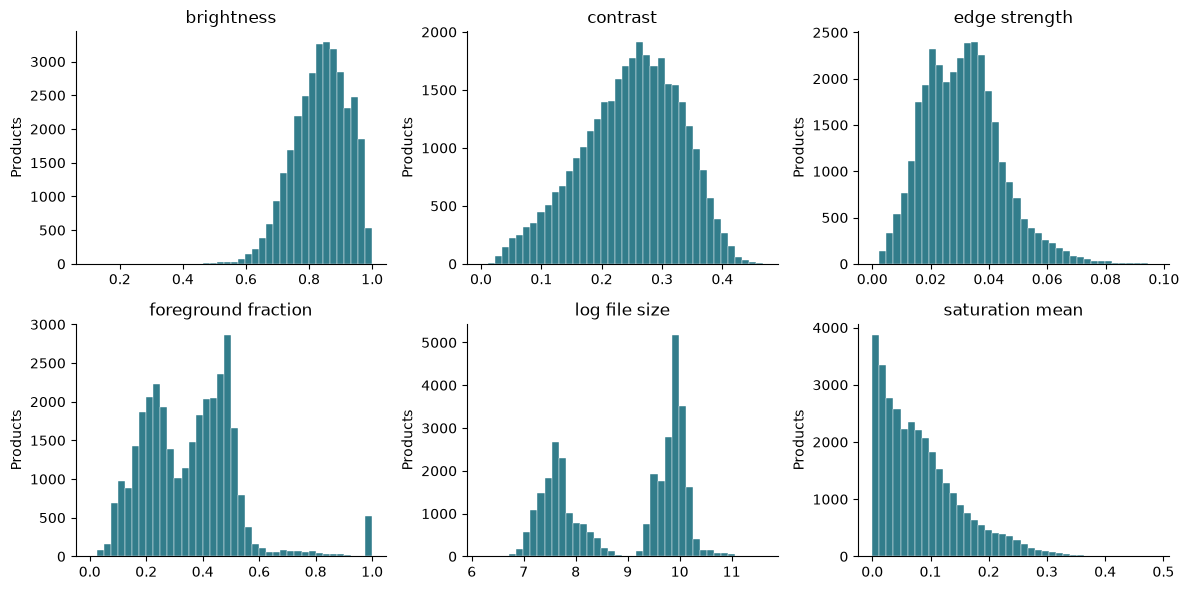

In [7]:
diagnostics = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/clean_slate_eda/teacher_image_diagnostics.csv.gz',
        keep_default_na=False)
assert set(diagnostics.id) == set(development.id)
quality_features = ['brightness','contrast','edge_strength','foreground_fraction',
    'log_file_size','saturation_mean']
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feature in zip(axes.flat, quality_features):
    ax.hist(diagnostics[feature], bins=40, color='#327d8b', edgecolor='white', linewidth=0.3)
    ax.set(title=feature.replace('_',' '), ylabel='Products')
fig.tight_layout()
fig.savefig(FIGURES / "eda_image_quality.png", dpi=150, bbox_inches="tight")
plt.show()

### View a deterministic contact sheet across Gender and Usage


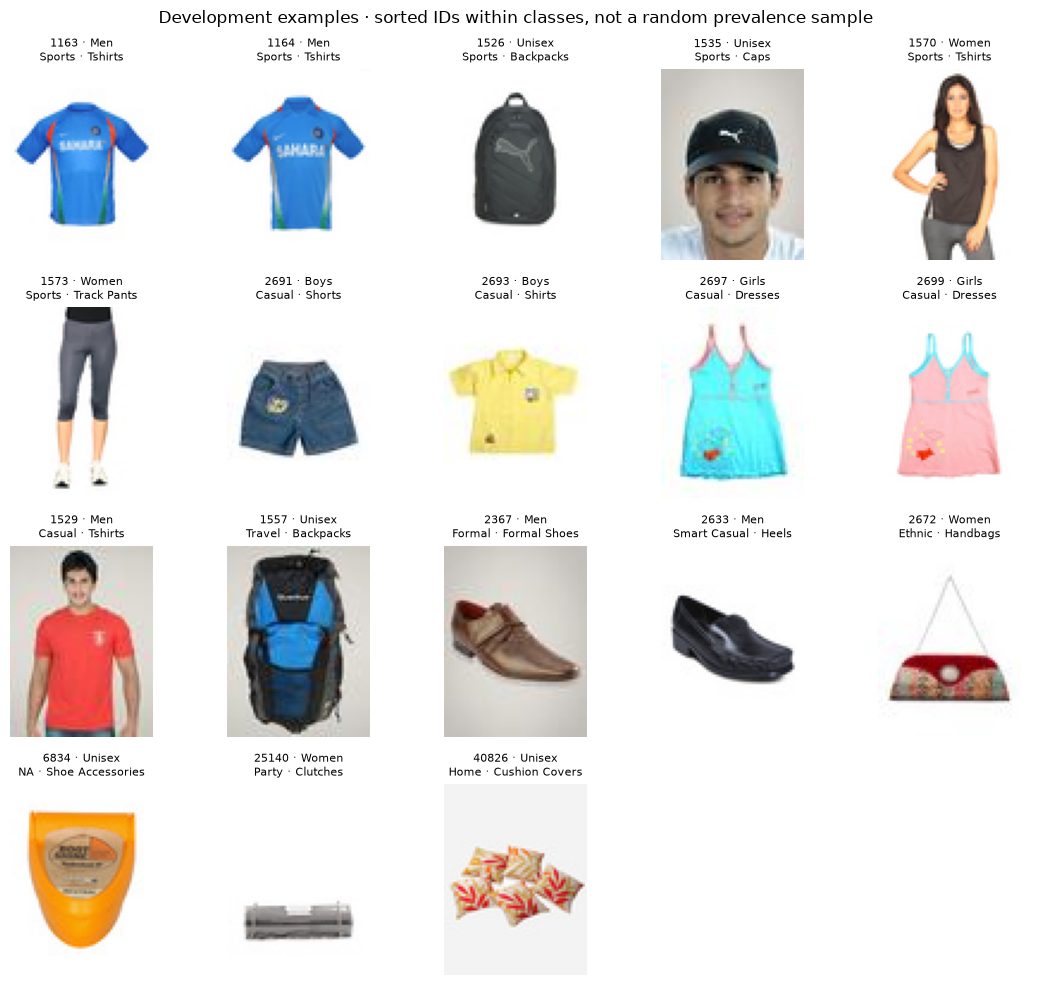

In [8]:
sample_rows = pd.concat([development.sort_values('id').groupby('gender').head(2),
                        usage_development.sort_values('id').groupby('usage').head(1)])
sample_rows = sample_rows.drop_duplicates('id').head(20)
fig, axes = plt.subplots(4, 5, figsize=(11, 10))
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, sample_rows.itertuples()):
    assert hashlib.sha256((REPO_DIR/row.path).read_bytes()).hexdigest() == row.sha256
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.gender}\n{row.usage or "blank"} · {row.articleType}', fontsize=8)
fig.suptitle('Development examples · sorted IDs within classes, not a random prevalence sample')
fig.tight_layout()
fig.savefig(FIGURES/'eda_contact_sheet.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation.** Most images have one centred item on white, but product scale, position, shadows and object type vary. There are 294 valid grayscale images and only 12 unusual geometries. The low native resolution leaves small cues such as straps, collars and shoe outlines fragile.

**Consequence.** Convert all inputs to RGB and keep the native 80×60 information. Fit normalisation only on the current training complement. Brightness and file size describe how images were acquired as well as the item itself; their predictive power would not by itself prove useful fashion understanding. The deterministic contact sheet covers labels, so it must not be read as their frequency in the dataset.


## 5. Shared EDA: transform risks

The small images made preprocessing consequential. The same products are shown under
stretching, cropping, padding and lighting changes to establish which transformations
preserve the item and which risk removing useful evidence.


### Compare image transforms on the same products


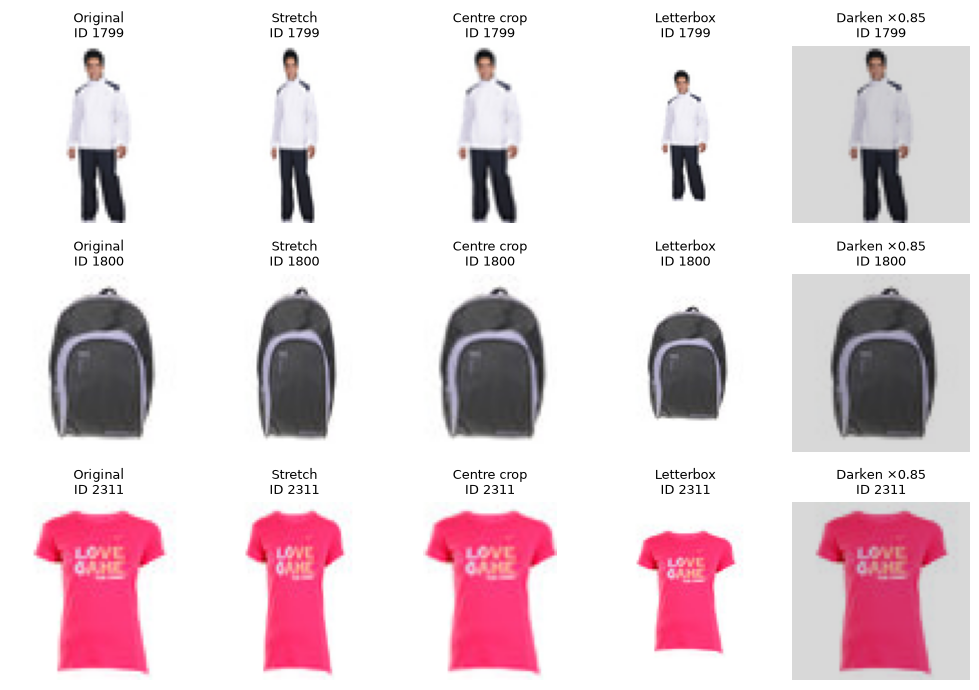

In [9]:
transform_rows = development.loc[development.width.ne(60)|development.height.ne(
    80)].sort_values('id').head(3)
fig, axes = plt.subplots(len(transform_rows), 5, figsize=(10, 7), squeeze=False)
for axes_row, row in zip(axes, transform_rows.itertuples()):
    with Image.open(REPO_DIR/row.path) as image:
        original = ImageOps.exif_transpose(image).convert('RGB')
        views = [original, original.resize((60,80)), ImageOps.fit(original,(60,80)),
                 ImageOps.pad(original,(60,80),color='white'), ImageEnhance.Brightness(
                     original).enhance(.85)]
    for ax, view, name in zip(axes_row, views, ['Original','Stretch','Centre crop',
        'Letterbox','Darken ×0.85']):
        ax.imshow(view)
        ax.set_title(f'{name}\nID {row.id}', fontsize=9)
        ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES/'eda_transform_risk.png', dpi=150, bbox_inches='tight')
plt.show()

**Baseline preprocessing and rationale**

| Choice | Exact baseline value | Reason |
|---|---|---|
| Input | `3×80×60` | Matches native image information |
| Geometry | EXIF, RGB, aspect preservation, LANCZOS letterbox only for unusual images | Avoid stretch and crop damage |
| Padding | White before scaling; neutral zero after standardisation | Match catalogue boundary without fitting padding |
| Normalisation | RGB mean/std fitted on current fold-training content pixels | Keep learned preprocessing inside the fold |
| Augmentation | None | Expose the raw train–validation and robustness gap |
| Validation | Deterministic transform only | Make candidate comparisons exact |

`(128,96)`, augmentation, another loss, or another transform is not a mandatory menu. It is a
single-factor child only when an accepted parent's evidence triggers it.


Stretching changes proportions; centre cropping can cut off the item. Letterboxing preserves it but moves boundaries and adds padding. These examples explain the baseline geometry rule; they do not establish that larger inputs add information. More pixels made from the same small JPEG cannot recover missing detail.


## 6. Shared EDA: class counts and independent families

Preserving image detail was only one requirement. The label counts revealed that the two
targets also differed in available support, especially when similar products were counted
as families rather than independent examples.


### Count products and families for both targets


development_product_count  development_family_count  \
target class                                                               
gender Boys                                684                       397   
       Girls                               543                       336   
       Men                               17753                     12345   
       Unisex                             1766                      1428   
       Women                             12027                      8401   
usage  Casual                            25151                     17637   
       Ethnic                             2183                      1351   
       Formal                             1949                      1016   
       Home                                  1                         1   
       NA                                   61                        49   
       Party                                12                        10   
       Smart Casual                         47                        37   
       Sports                             3346                      3020   
       Travel                               22                        22   

                     minimum_fold_training_products  untrainable_fold_count  
target class                                                                 
gender Boys                                     546                       0  
       Girls                                    433                       0  
       Men                                    14201                       0  
       Unisex                                  1411                       0  
       Women                                   9621                       0  
usage  Casual                                 20114                       0  
       Ethnic                                  1745                       0  
       Formal                                  1553                       0  
       Home                                       0                       1  
       NA                                        47                       0  
       Party                                      9                       0  
       Smart Casual                              37                       0  
       Sports                                  2675                       0  
       Travel                                    17                       0

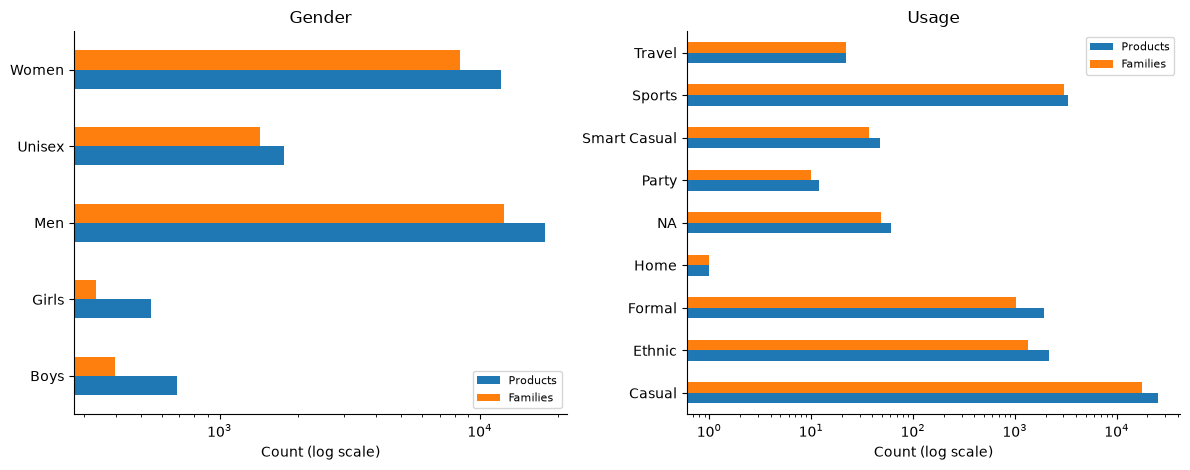

In [10]:
support = pd.read_csv(REPO_DIR / 'data/processed/development_class_summary.csv',
    keep_default_na=False)
support = support.loc[support.target.isin(['gender','usage'])].copy()
display(support[['target','class','development_product_count','development_family_count',
                 'minimum_fold_training_products','untrainable_fold_count']].set_index([
                     'target','class']))
fig, axes = plt.subplots(1,2,figsize=(12,4.8))
for ax, target in zip(axes,['gender','usage']):
    rows = support.loc[support.target.eq(target)].set_index('class')
    rows[['development_product_count','development_family_count']].rename(
        columns={'development_product_count':'Products',
            'development_family_count':'Families'}).plot.barh(ax=ax)
    ax.set(xscale='log', xlabel='Count (log scale)', ylabel='', title=target.title())
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "eda_class_support.png", dpi=150, bbox_inches="tight")
plt.show()

Gender ranges from 17,753 Men products to 543 Girls products. Usage ranges from 25,151 Casual products to one Home product. Macro-F1 gives each label the same weight, so mistakes on small classes matter even when accuracy is high. A family may contain very similar items; its members are not independent draws. Class weighting can change the penalty for an error, but it cannot create a second Home family.

This imbalance gave the study its two priorities: preserve performance on the common classes
while tracing failures on the small classes explicitly. It also set a limit on what model
changes alone could reasonably demonstrate.


## 7. Shared EDA: duplicate groups and fold support

These family relationships shaped the evaluation design. Keeping related products together
reduces the chance that a validation image is merely a close copy of a training image.
The saved fold support also exposes classes for which that separation leaves too little data.


### Check group crossings and show family sizes


,Count
Products,32773
Families,22905
Family fold crossings,0
Duplicate fold crossings,0


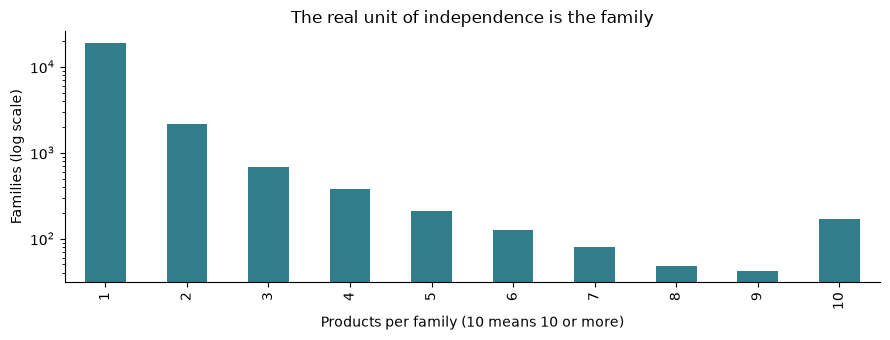

In [11]:
family_crossings = development.groupby('product_family_group').cv_fold.nunique()
duplicate_crossings = development.groupby('duplicate_group').cv_fold.nunique()
assert family_crossings.max() == 1 and duplicate_crossings.max() == 1
family_sizes = development.groupby('product_family_group').size()
display(pd.Series({'Products':len(development),'Families':len(family_sizes),
                   'Family fold crossings':int(family_crossings.gt(1).sum()),
                   'Duplicate fold crossings':int(duplicate_crossings.gt(1).sum())}).to_frame(
                       'Count'))
fig, ax = plt.subplots(figsize=(9,3.5))
family_sizes.clip(upper=10).value_counts().sort_index().plot.bar(ax=ax,color='#327d8b')
ax.set(yscale='log',xlabel='Products per family (10 means 10 or more)',
    ylabel='Families (log scale)',
       title='The real unit of independence is the family')
fig.tight_layout()
fig.savefig(FIGURES/'eda_family_sizes.png',dpi=150,bbox_inches='tight')
plt.show()

### Show every Usage class in every validation fold


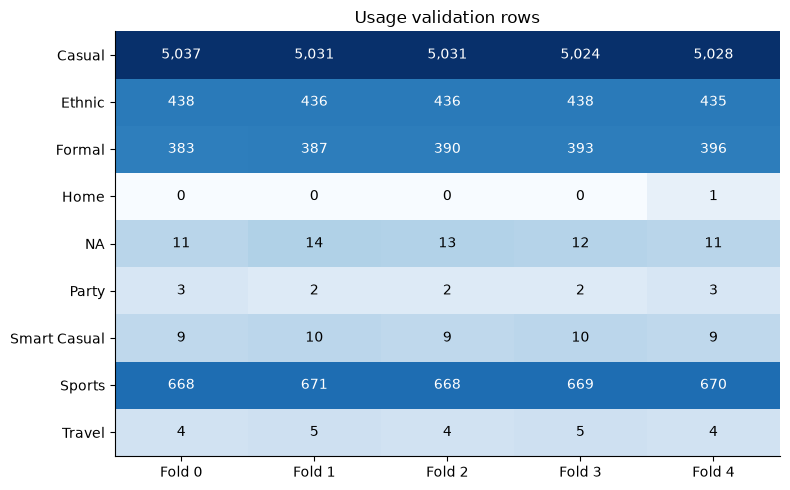

In [12]:
fold_support = support.loc[support.target.eq('usage')].set_index('class')
values = fold_support[[f'fold_{i}_validation_products' for i in range(5)]].to_numpy(int)
fig, ax = plt.subplots(figsize=(8,5))
ax.imshow(np.log1p(values),cmap='Blues',aspect='auto')
ax.set(xticks=range(5),xticklabels=[f'Fold {i}' for i in range(5)],
       yticks=range(len(fold_support)),yticklabels=fold_support.index,title='Usage validation rows')
for i,j in np.ndindex(values.shape):
    ax.text(j,i,f'{values[i,j]:,}',ha='center',va='center',color='white' if values[i,
        j]>300 else 'black')
fig.tight_layout()
fig.savefig(FIGURES/'eda_usage_fold_support.png',dpi=150,bbox_inches='tight')
plt.show()

**Family separation defined the comparison.** Exact bytes detect copied files, while reviewed perceptual matches and normalised product names catch a broader family. Broad name matches were reviewed because a generic shared name can wrongly merge different items. Conflicting labels and cross-role duplicate risks were handled before the split. The saved grouping is deliberately retained; model scores cannot justify regrouping a difficult example.

**Home exposed a structural limit.** Its single validation occurrence has no Home example in that fold's training complement. Zero recall there is a structural support failure, not evidence that a larger network would solve it. The official nine-class score still includes Home; the without-Home diagnostic must be named separately. Family bootstrap intervals resample families rather than pretend every near duplicate is independent.


## 8. Shared EDA: target relationships and shortcuts

After establishing family separation, we examined other associations a model might exploit.
Gender–Usage pairs, article types and acquisition cues help interpret later errors, while
remaining outside the image-only prediction input.


### Count the observed Gender–Usage pairs


Observed label pairs: 26 of 45


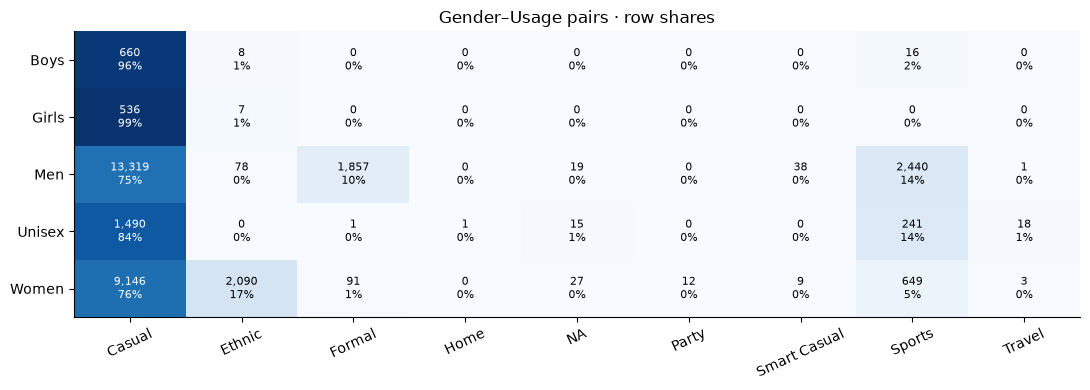

In [13]:
joint = pd.crosstab(usage_development.gender,usage_development.usage)
shares = joint.div(joint.sum(axis=1),axis=0)
fig, ax = plt.subplots(figsize=(11,4))
ax.imshow(shares,cmap='Blues',vmin=0,vmax=1,aspect='auto')
ax.set(xticks=range(len(joint.columns)),xticklabels=joint.columns,
       yticks=range(len(joint)),yticklabels=joint.index,title='Gender–Usage pairs · row shares')
ax.tick_params(axis='x',rotation=25)
for i,j in np.ndindex(joint.shape):
    ax.text(j,i,f'{joint.iloc[i,j]:,}\n{shares.iloc[i,j]:.0%}',ha='center',va='center',fontsize=8,
            color='white' if shares.iloc[i,j]>.55 else 'black')
print('Observed label pairs:',int(joint.gt(0).sum().sum()),'of',joint.size)
fig.tight_layout()
fig.savefig(FIGURES/'eda_target_relationships.png',dpi=150,bbox_inches='tight')
plt.show()

### Measure descriptive article-type and acquisition shortcuts


Target,gender,usage
Feature,,
articleType,78.54,90.04
file_size_band,54.17,76.75
mode,54.17,76.75
year,58.50,76.75


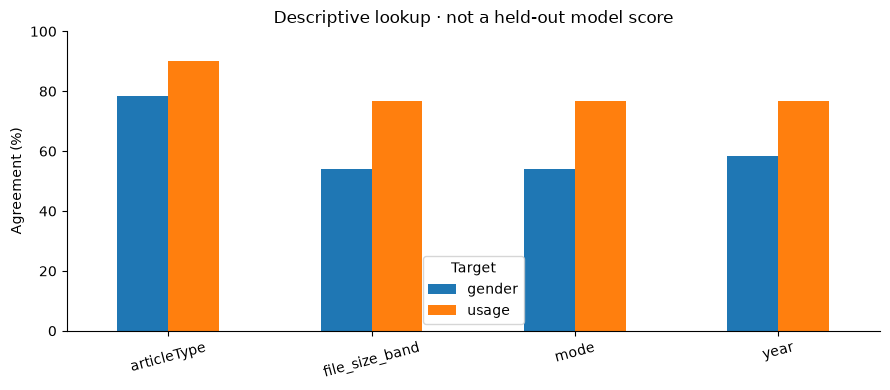

In [14]:
shortcut_rows = []
for target in ['gender','usage']:
    rows = development.loc[development[f'has_{target}_label'].eq(True)].copy()
    rows['file_size_band'] = pd.qcut(rows.file_size_bytes.astype(float),10,
        duplicates='drop').astype(str)
    for feature in ['articleType','year','mode','file_size_band']:
        counts = pd.crosstab(rows[feature],rows[target])
        shortcut_rows.append([target,feature,100*counts.max(axis=1).sum()/counts.to_numpy().sum()])
shortcuts = pd.DataFrame(shortcut_rows,columns=['Target','Feature',
    'Descriptive majority agreement (%)'])
display(shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').round(2))
fig, ax = plt.subplots(figsize=(9,4))
shortcuts.pivot(index='Feature',columns='Target',
    values='Descriptive majority agreement (%)').plot.bar(ax=ax,rot=15)
ax.set(ylim=(0,100),ylabel='Agreement (%)',xlabel='',
    title='Descriptive lookup · not a held-out model score')
fig.tight_layout()
fig.savefig(FIGURES/'eda_shortcut_agreement.png',dpi=150,bbox_inches='tight')
plt.show()

Only 26 of 45 Gender–Usage pairs occur. This dependence does not license filling missing labels or hard-coding impossible pairs. Article type agrees with roughly 78.5% of Gender and 90.0% of Usage labels through a descriptive majority lookup. That is a shortcut warning, not cross-validated performance: the lookup used these same labels.

Year, mode and file-size bands can reflect catalogue sources or compression. Their high raw agreement can also come from the majority class alone. They are therefore slices for diagnosis, not proof of usable extra information. Article type remains outside the image-only input. A later type-to-Usage cascade must predict type from the image inside each training fold; it cannot read the row's true type at inference.

Together, the audit established a restrained starting point: learn from the product pixels,
keep related examples together, and examine performance beyond majority-class accuracy.


## 9. Start with the baseline

The audit suggested a compact model that preserved native image detail, but it did not
identify an optimal architecture. We therefore began with one bounded scratch CNN design
for both targets. Its training behaviour and held-family errors would determine which
changes were justified next.


**Exact primary learnable baseline**

The baseline used one fixed design, trained separately from scratch for each target:

```text
Conv3x3 3->32   + BatchNorm + ReLU + MaxPool2
Conv3x3 32->64  + BatchNorm + ReLU + MaxPool2
Conv3x3 64->128 + BatchNorm + ReLU + MaxPool2
Conv3x3 128->256 + BatchNorm + ReLU
Adaptive global average pooling
Linear 256->5 or Linear 256->9
```

**Depth and spatial reduction informed by the EDA**

The three pooling steps follow the observed native image size:

```text
80×60 -> 40×30 -> 20×15 -> 10×7
```

A `10×7` final grid still keeps separate evidence for small product regions. A fourth pool would
reduce these tiny inputs to about `5×3`, making it easier to lose straps, sleeves, collars, and
other edge details seen in the contact sheet. The fourth convolution therefore adds feature
capacity without another spatial reduction. With four `3×3` convolutions and three pools, one
final-grid position sees about a `38×38` source region; global average pooling then combines the
whole set of positions without tying a feature to one fixed product location.

**Channel counts as a capacity hypothesis**

The EDA justifies a small native-resolution CNN, three reductions, local-to-global feature
learning, and a bounded scratch capacity. It does **not** prove that `32,64,128,256` is optimal.
Those widths are a predeclared capacity hypothesis. As each pool removes about three quarters
of the spatial positions, the next block gets more feature channels while total activation size
continues to fall. The result is 390,181 trainable parameters for gender and 391,209 for usage.
The first curves then provide evidence about capacity and training duration; the EDA alone
does not establish that these choices are sufficient.

Batch normalization and ReLU are optimisation controls, not EDA discoveries. No dropout, class
weighting, augmentation, or pretrained weights are added because there is no parent-model
evidence for those changes yet.

Fixed recipe: Kaiming random initialisation, unweighted cross-entropy, AdamW, learning rate
`0.001`, weight decay `0.0001`, batch 128, 30 epochs, cosine decay to `0.00001`, no mixed
precision, no early stopping, final-epoch OOF checkpoint, seed 2753.

This is the architecture used by the saved baseline runs.
The trained model is the `final_epoch.pt` checkpoint inside each registered fold folder. The historical run audit checked each bundle. This notebook verifies the pinned registry and analysis sources before recomputing the displayed results.


**Lower bounds and integrity checks.** A fold-training majority predictor measures the class prior; a stratified predictor checks label order and the random seed. Bias-only and shuffled-label fits test for accidental label access. A tiny-batch overfit check establishes whether optimisation can fit a small known batch at all. These are code checks, not candidates for the final model. HOG + HSV logistic regression is the classical shape-and-colour reference. Dalal and Triggs [2]
motivate the edge descriptor; the colour features and classifier are local design choices. Scratch model weights are required; a pretrained comparison could only be an explicitly separate benchmark.


### Recompute the comparison from registered confusion counts


In [15]:
selected_stages = ['baseline', 'usage1']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30


### Plot class gains and losses on the same folds


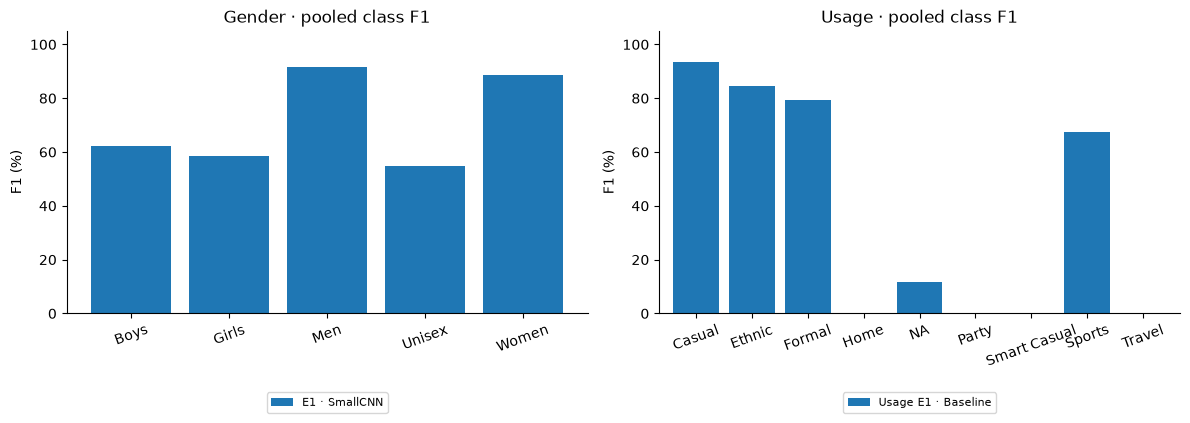

In [16]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
targets = class_scores.Target.unique()
fig, axes = plt.subplots(1, len(targets), figsize=(12, 4.5), squeeze=False)
for ax, target in zip(axes[0], targets):
    table = class_scores.loc[class_scores.Target.eq(target)].pivot(index='Class',
        columns='Stage', values='F1 (%)')
    table.plot.bar(ax=ax, rot=20, width=0.82)
    ax.set(title=target.title()+' · pooled class F1', ylim=(0,105), xlabel='', ylabel='F1 (%)')
    ax.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.26))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_classes.png", dpi=150, bbox_inches="tight")
plt.show()

### Read matched corruption results for every saved fold


In [17]:
robustness_keys=['baseline']
robustness_sources={key:evidence_lock['stages'][key]['robustness_paths'] for key in robustness_keys}
robustness_frames=[]
for key, paths in robustness_sources.items():
    stage=evidence_lock['stages'][key]
    paths = [str(p).replace('reports/task3_', 'reports/task3/', 1) for p in paths]
    rows=pd.concat([pd.read_csv(REPO_DIR/path) for path in paths],ignore_index=True)
    assert set(rows.run_id)==set(stage['run_ids'])
    rows['Stage'],rows['Target']=stage['label'],stage['target']
    robustness_frames.append(rows)
robustness_rows=pd.concat(robustness_frames,ignore_index=True)
induced=robustness_rows.groupby(['Target','Stage','corruption']).macro_f1_change.mean().mul(100)
display(induced.unstack('corruption').round(2))

,corruption,brightness_085,brightness_115,grayscale,jpeg_75,translation_003
Target,Stage,,,,,
gender,E1 · SmallCNN,-25.62,-3.86,-4.14,-4.16,-15.51


### Plot the change caused by each corruption

The fixed corruption checks follow the evaluation principle of Hendrycks and Dietterich [3]:
measure how predictions change under controlled image damage. The selected lighting, shift and
compression settings are adaptations for these small catalogue images, not the original benchmark.


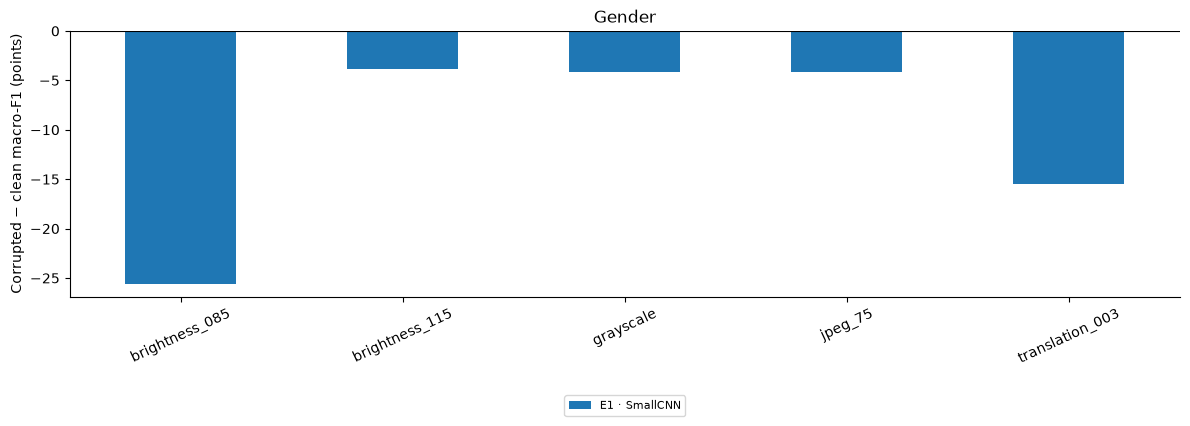

In [18]:
targets=robustness_rows.Target.unique()
fig,axes=plt.subplots(1,len(targets),figsize=(12,4.7),squeeze=False)
for ax,target in zip(axes[0],targets):
    values=induced.loc[target].unstack('Stage')
    values.plot.bar(ax=ax,rot=25)
    ax.axhline(0,color='black',linewidth=.8)
    ax.set(title=target.title(),ylabel='Corrupted − clean macro-F1 (points)',xlabel='')
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.35))
fig.tight_layout()
fig.savefig(FIGURES / "baseline_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Baseline diagnosis: curves, class collapse and confident errors

The baseline established different starting points for the two targets. Gender learned the
training images almost perfectly while retaining large validation errors. Usage achieved high
accuracy largely through common classes and missed several rare labels altogether. The curves,
class counts and selected mistakes below separate these patterns before the paths diverge.


### Read the baseline learning records


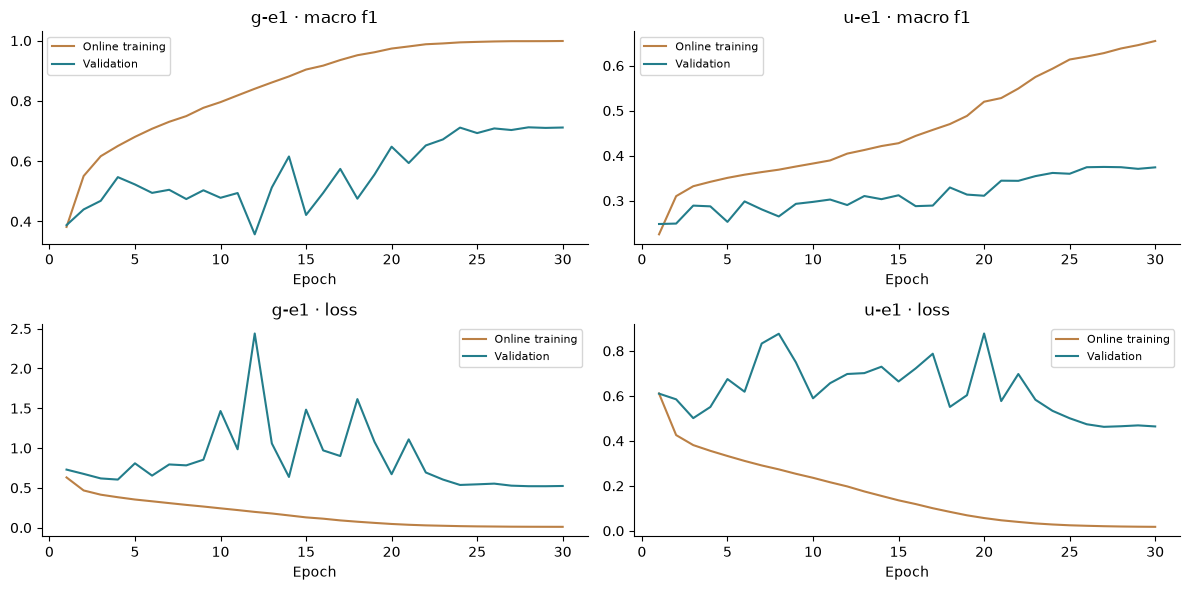

In [19]:
historical_curves = pd.read_csv(
    REPO_DIR / 'reports/task3/failure_review/evidence/all_model_curve_means.csv',
        keep_default_na=False)
fig, axes = plt.subplots(2,2,figsize=(12,6))
for column,model_id in enumerate(['g-e1','u-e1']):
    rows = historical_curves.loc[historical_curves.model_id.eq(model_id)]
    for row,metric in enumerate(['macro_f1','loss']):
        ax = axes[row,column]
        ax.plot(rows.epoch,rows['train_'+metric],label='Online training',color='#bb8045')
        ax.plot(rows.epoch,rows['validation_'+metric],label='Validation',color='#237d8b')
        ax.set(title=model_id+' · '+metric.replace('_',' '),xlabel='Epoch')
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "baseline_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Gender baseline diagnosis and next experiment**

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.7118**. Fold scores are 0.6982, 0.7068, 0.7048,
  0.7207, and 0.7279: mean 0.7117, standard deviation 0.0109. The observed spread is 2.97 F1 points across
  the five family-safe folds; this does not measure variation across training seeds.
- The final online training macro-F1 is about 0.999 in every fold while OOF stays near 0.71.
  Final training loss averages about 0.0107. This is strong memorisation evidence.
- Validation loss reaches its minimum at epochs 3–6, then rises, while the best validation
  macro-F1 arrives at epochs 24–30. The epoch of lowest loss differs from the epoch of best F1 in these saved histories.
  Loss therefore cannot be substituted for the declared F1 criterion without changing the selection rule.
- Men F1 is 0.9167 and Women F1 is 0.8878. Boys, Girls, and Unisex are much weaker at
  0.6222, 0.5851, and 0.5470. Small classes have lower F1 here, but these counts alone do not establish the cause.
- The largest error routes are Women→Men (1,026), Men→Women (854), and Unisex→Men
  (516). Gender presentation is often weak or absent in product-only images.
- Mean macro-F1 change is −0.2562 under brightness ×0.85 and −0.1551 under a 3%
  translation. JPEG 75, grayscale, and brightness ×1.15 each cost about 0.04 or less.
- The selected 40 highest-confidence errors all have confidence at least 0.99. The gallery
  contains fragrances, watches, shoes, and other products with weak audience cues. Average
  ECE is only 0.0756, so the mean calibration score hides these extreme local mistakes.

The first historical child changed only one factor: add mild random brightness during training.
Architecture, input size, loss, optimiser, schedule, seed, folds, and final-epoch rule stay fixed.
Class weighting, translation, more pixels, and a new architecture are not added to this child.

**Usage baseline diagnosis and next experiment**

**Decision at this stage: keep E1 as the reference parent.** Its accuracy and equal-class performance must be judged separately.

- Pooled OOF macro-F1 is **0.3738**, or **0.4205** without the one-example Home class.
  Fold macro-F1 ranges from 0.3609 to 0.3960, with standard deviation 0.0121.
- Accuracy is 0.8930, but 25,151 of 32,772 valid rows (76.7%) are Casual. Accuracy and
  weighted-F1 mainly describe the large classes and hide rare-class failure.
- Casual, Ethnic, Formal, and Sports reach F1 values of 0.9329, 0.8463, 0.7939, and
  0.6731. NA reaches only 0.1176. Home, Party, Smart Casual, and Travel all score zero.
- The model predicts no Home, Party, or Smart Casual examples. It predicts Travel once,
  incorrectly. It sends 1,255 Sports, 450 Formal, 391 Ethnic, 55 NA, 36 Smart Casual,
  17 Travel, 9 Party, and the one Home row to Casual.
- Final training loss averages about 0.0177, but pooled OOF NLL is 0.4641. Validation loss
  bottoms at epochs 6–13 while the best macro-F1 appears at epochs 26–30. As with gender,
  the saved loss minima and F1 maxima select different epochs; loss alone does not implement the declared criterion.
- Mean robustness drops are smaller than gender: −0.0668 for darkening and −0.0642 for
  translation. This does not make Usage strong; its clean macro-F1 is already low.
- The error gallery shows real visual overlap. Sports and Casual shirts or shoes can look
  alike, and business labels such as Formal, Party, and Travel are not always visible from
  one product image. Weighting cannot create missing visual information.

The first eligible child changes only the loss to capped class-balanced cross-entropy. It uses
effective-number weights with `beta=0.999`, mean-one nonzero normalisation, cap 5, and only
the current fold's training counts. `Home` does not select or judge the child. Architecture,
input, augmentation, optimiser, schedule, seed, folds, and checkpoint rule stay fixed.

The brightness-only Gender trial did not establish the intended clean-score improvement. That side path did not determine the retained progression; the next retained test examined a different way of combining local image features. Usage retains the class-weighting test because it changed the accepted reference model.


### Read confident Gender mistakes on development images


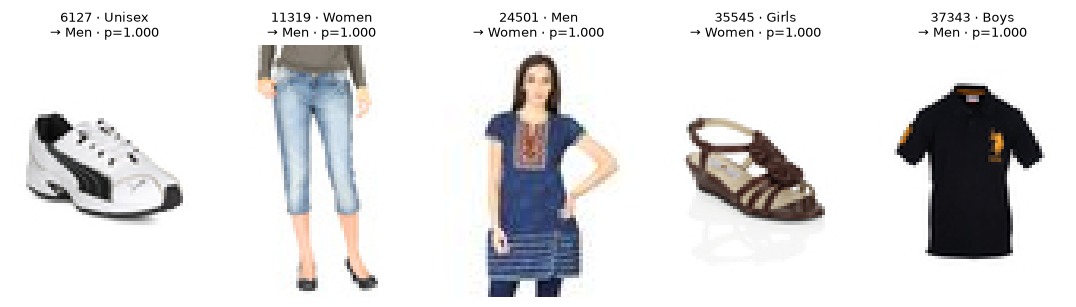

In [20]:
errors = pd.read_csv(
    REPO_DIR / 'results/evidence/task3/baseline/gender/aggregate/failure_index.csv',
        keep_default_na=False)
errors = errors.loc[errors.true_label.ne(errors.predicted_label)]
errors = errors.sort_values(['confidence','id'],ascending=[False,True]).drop_duplicates(
    'true_label')
fig, axes = plt.subplots(1,5,figsize=(11,3))
for ax,row in zip(axes,errors.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label}\n→ {row.predicted_label} · p={
        row.confidence:.3f}',fontsize=9)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "baseline_confident_errors.png", dpi=150, bbox_inches="tight")
plt.show()

The gallery selects the highest-confidence saved mistake per true Gender class, breaking ties by ID. It is an error audit, not an estimate of the error rate. A confident wrong watch or shoe supports the concern that the model uses catalogue associations. It does not prove which internal feature caused that one prediction.


## 11. Gender: pooling and photo sensitivity

**Pooling became the next controlled change.** The baseline fits its training families almost perfectly, yet misses Boys, Girls
and Unisex more often than Men and Women. Adding capacity is not the first response to that pattern.
One possible weakness is how the network combines local evidence: global average pooling gives
every final-grid position equal weight, which can dilute a small but useful region.

The GeM proposal has a research basis in Radenović, Tolias and Chum [4], who introduce
generalised-mean pooling to combine average-like and max-like feature aggregation. This gives
a reason to test whether stronger local responses preserve small fashion cues. Their evidence
concerns image retrieval; our hypothesis adapts the pooling operation to scratch classification
and fixes its power instead of learning it.

E6 changes only that pooling step to fixed GeM:
`mean(max(x, 1e-6)^3)^(1/3)`. Strong activations receive more weight. The fixed power `p=3`
adds no trainable parameters; the convolution blocks, loss, optimiser, 30-epoch budget, seed and
folds remain the same. Improvement in minority classes without a common-class or robustness loss
would support this mechanism. A higher aggregate score alone would not show why it improved.

The table keeps the three milestones on **all five folds and original labels**. Read E1→E6 as
the pooling comparison and E6→G2 as the later translation comparison. These are separate runs.


In [21]:
selected_stages = ['baseline', 'gem', 'translation']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E1 · SmallCNN,gender,"[0, 1, 2, 3, 4]",Original,32773,71.18,87.68
E6 · GeM pooling,gender,"[0, 1, 2, 3, 4]",Original,32773,73.35,89.32
G2 · Translation,gender,"[0, 1, 2, 3, 4]",Original,32773,75.02,90.34


**Gender E6 — a real gain, but memorisation remains**

GeM improved four of five folds and every class. The largest F1 gains over E1 were Unisex
(+0.0424) and Boys (+0.0338). Accuracy rose from 0.8768 to 0.8932, NLL fell from 0.5237 to
0.4325, and all five corruption scores improved. The product-family bootstrap lower bound is
above zero, so the gain is not explained by treating related images as independent rows.

This does not fix overfitting. Finished training macro-F1 is still 0.99995 and the mean
train-validation gap is 0.2666. Unisex recall is only 0.5181; 514 Unisex rows become Men and
288 become Women. Mixed-label-family NLL worsened from 1.5753 to 1.6275 even while
consistent-family NLL improved. GeM helps visual summarisation, but it cannot resolve conflicting
or visually unclear labels.

The performance gain has a memory cost: peak memory was 476.0 MB versus at most
450.5 MB for E1, about 5.7% higher. We retain E6 as evidence that pooling helps, while
reporting that extra memory alongside its score. Its near-perfect training fit and remaining
class errors justify further investigation before choosing a final model.

**The remaining shift sensitivity motivated translation.** Pooling improved visual summarisation but left near-perfect clean
training F1 and a large validation gap. The baseline corruption test also showed strong sensitivity
to small shifts. G2 tests whether varying training placement reduces reliance on fixed catalogue
alignment; validation images stay unchanged. Zhang [6] shows that ordinary CNN downsampling
can make predictions sensitive to small shifts. This supports the mechanism behind the test;
the local corruption audit supplies the reason to test it here.

On screen folds 0 and 4, G2 improves all five pooled class scores and reduces translation-corruption
loss from 13.99 to 1.69 F1 points. That supports improved tolerance to the tested shifts. Yet its clean gap
falls only from 27.70 to 24.84 points and dark-image behaviour worsens. The saved predictions are less sensitive to the tested shifts; other failures remain.

**The additional folds do not establish a clear improvement.** G2 reaches 75.02% pooled F1 across all five folds, versus E6's 73.35%. But the fresh folds 1–3 improve by only 1.2947 points with a family-bootstrap 95% interval of −0.3554 to +2.8650. The lower bound is not above zero. The dark-image induced loss is also 3.1993 points worse than E6. The uncertain gain on additional folds and worse dark-image performance prevent us from treating the higher pooled score as an unqualified improvement.

**Translation informed later work despite its limits.** The two-fold screen sharply reduced translation corruption loss, consistent with a placement sensitivity. It did not close the clean fit gap, and it exposed a separate lighting weakness. Later named candidates reuse that useful mechanism while retaining G2's historical rejection. They do not retroactively call it an accepted finalist.

**The alternatives narrowed the investigation.** Residual connections [5] motivated the TinyResNet
comparison, but its 71.21% F1 was almost unchanged from E1,
with a family interval crossing zero and worse confidence and translation behaviour. Best-checkpoint
early stopping reached 74.12% but left a 25.82-point clean gap, missing its 24.66-point target.
Those results rule out simple architecture or checkpoint fixes under the tested recipes; they do
not need separate full sections. The compact table below recomputes the original Gender alternatives from their registered
confusion counts. A higher score alone does not erase the class errors, uncertainty and robustness losses described above.

The wider architecture search tested different ways of retaining information. CompactBlurCNN
used low-pass filtering before downsampling, consistent with the anti-aliasing method in [6].
TinyHRNet drew on parallel high-resolution representations [7]. The Gender audience helper
used related supervision, motivated by multitask learning [8], with task competition [9] as a
reason to demand local gains. These were small project adaptations, not exact reproductions
of the published networks. Their saved results did not justify replacing the retained path.

A later AdamW trial changed weight decay from 0.0001 to 0.001, drawing on decoupled weight-decay
regularisation [10]. Its limited effect kept the focus on more targeted changes. The numerical
setting was a local test choice, not a value established by that paper.


In [22]:
compact_rows = []
for key in ['baseline', 'brightness', 'balance', 'resnet', 'blur',
            'gem', 'hrnet', 'early', 'filter', 'aux']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
E1 · SmallCNN,"0, 1, 2, 3, 4",Original,32773,71.18,87.68
E2 · Brightness,"0, 1, 2, 3, 4",Original,32773,69.89,87.30
E3 · Class weights,"0, 1, 2, 3, 4",Original,32773,70.81,87.32
E4 · TinyResNet,"0, 1, 2, 3, 4",Original,32773,71.21,87.71
E5 · CompactBlurCNN,"0, 1, 2, 3, 4",Original,32773,70.69,88.72
E6 · GeM pooling,"0, 1, 2, 3, 4",Original,32773,73.35,89.32
E7 · TinyHRNet,"0, 1, 2, 3, 4",Original,32773,70.25,87.35
E8 · Early stopping,"0, 1, 2, 3, 4",Original,32773,74.12,89.12
E9 · Semantic filter,"0, 1, 2, 3, 4",Original,32773,74.51,89.30


### Check a different model family on matched screen folds

HOG describes local edges without learning an image representation. A support vector machine
(SVM) then separates these fixed features. It tests whether a simpler feature model can generalise
better than the CNN, whose training fit is already very high.

Use only folds **0 and 4** for both models. The full-population screen matters: a balanced-sample
probe changes the class mix and cannot be compared directly with these naturally imbalanced folds.


In [23]:
selected_stages = ['gem04', 'hog_g']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
E6 · GeM pooling,gender,"[0, 4]",Original,13110,72.30,89.19
Gender S1 · HOG SVM,gender,"[0, 4]",Original,13110,66.08,85.28


**Result and meaning.** HOG-SVM reaches 66.08% macro-F1, below the matched GeM reference.
Fixed edge features did not retain enough useful class separation under this screen. This supports
keeping learned CNN features; it does not prove every possible classical model would fail.
Only two folds and one seed were tested, so the result is a screening decision, not a full confirmation.

The separate scratch transformer screen also fell short. Together, these screens supported
returning to the CNN's fit gap, image sensitivity and labels before adding more capacity.


### Test each part of the augmentation recipe

These steps need separate interpretation even though their scores share one table. Drop30 hides
30% of classifier features during training, testing whether the classifier relies too strongly on
specific combinations. This follows the dropout mechanism of Srivastava et al. [11];
the placement after GeM and rate 0.30 are local choices. Mild darkening then targets the lighting weakness; grayscale on 10% of
training images tests whether shape cues survive without colour. Each child retains its parent's
other settings. Validation is clean and deterministic.

The comparison uses **folds 0 and 4 and original labels**. Clean finished-model audits are used
for the gaps below. Online training scores on augmented images would make the gap look smaller
without measuring the same task as clean validation.


In [24]:
selected_stages = ['translation04', 'dropout', 'dark', 'gray']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
G2 · Translation,gender,"[0, 4]",Original,13110,74.57,90.31
Dropout 0.30,gender,"[0, 4]",Original,13110,75.42,90.16
Add mild darkening,gender,"[0, 4]",Original,13110,74.22,90.22
Add grayscale 10%,gender,"[0, 4]",Original,13110,74.79,90.09


**Drop30: partial progress.** The clean gap falls from G2's 24.84 to about 21.24 points.
Hiding features is consistent with reducing reliance on individual feature combinations, but the
remaining gap is still large and the dark-image weakness persists. Drop30 is a diagnostic base,
not yet a final model.

**Darkening: a targeted repair with a cost.** Dark-image behaviour improves, but clean pooled F1
falls from 75.43% to 74.22% and the gap grows from 21.24 to 22.34 points. A corruption gain
does not imply a clean-image gain. The larger clean gap and remaining grayscale weakness mean
it cannot be described as an unqualified improvement.

**Grayscale: one weakness reduced, another remains.** Random grayscale conversion improves
performance on grayscale images, but the clean training–validation gap remains
21.33 points. The grayscale test supports reduced sensitivity to removing colour; it does not identify
the cause of every unseen-family error. The final recipe retains this mechanism through later named candidates; the earlier failure
is still recorded.

**The remaining gap motivated label review.** The CNN can fit the training rows, several nuisance sensitivities have
been reduced, and class errors remain. That pattern makes weak or conflicting target labels worth
checking. It does not prove the labels are wrong: rare support and ambiguous product appearance
are competing explanations. The next audit therefore uses an explicit name rule and reports both
label bases, rather than relabelling whatever the model gets wrong.

The remaining screens examined foreground masking, component weights, weight decay, a narrower
head, stronger dropout and article-group weights. The next table shows their saved development scores, fold sets and label basis. Section 14 brings all candidates together.
These are different parent comparisons; do not treat the table as one controlled experiment.


In [25]:
compact_rows = []
for key in ['gem04', 'g1', 'translation04', 'g3', 'gd1', 'wd1',
            'narrow', 'dropout', 'dark', 'drop45', 'gray', 'group']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
E6 · GeM pooling,"0, 4",Original,13110,72.30,89.19
G1 · Foreground mask,"0, 4",Original,13110,72.95,89.26
G2 · Translation,"0, 4",Original,13110,74.57,90.31
G3 · Component weights,"0, 4",Original,13110,72.45,89.20
GD1 · Mild darkening,"0, 4",Original,13110,74.12,90.29
Weight decay 0.001,"0, 4",Original,13110,74.87,90.45
Narrow 64 channels,"0, 4",Original,13110,73.60,90.01
Dropout 0.30,"0, 4",Original,13110,75.42,90.16
Add mild darkening,"0, 4",Original,13110,74.22,90.22


## 12. Review the labels

The image-focused changes left a substantial Gender gap. This led to a closer examination
of the target definition: some supplied categories conflicted with explicit product-name cues.
The review introduced a fixed, separately reported label basis so that label changes could
be distinguished from improvements learned by the network.


### A new label basis must be named

Some product names clearly state a gender that conflicts with the supplied category.
The frozen `single_explicit_gender_cue_v1` rule creates a task-only label variant from those names.
Ambiguous names are left alone. Canonical labels are not overwritten.

This changes both training targets and development scoring labels. A jump from the previous table
therefore cannot be called a model-only gain. Original-label and corrected-label scores must remain separate in development comparisons.
The next table, class-gap chart and error gallery trace the effect of that review and locate
the errors that remained.

Label-quality research supports investigating suspect targets rather than assuming that every
training label is correct. Confident Learning [12] uses out-of-sample probabilities to estimate
label issues. Our explicit product-name rule is a different, documented intervention: it does
not implement that algorithm, and model confidence alone does not authorise a label change.


### Compare models on the same corrected-label basis


,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38


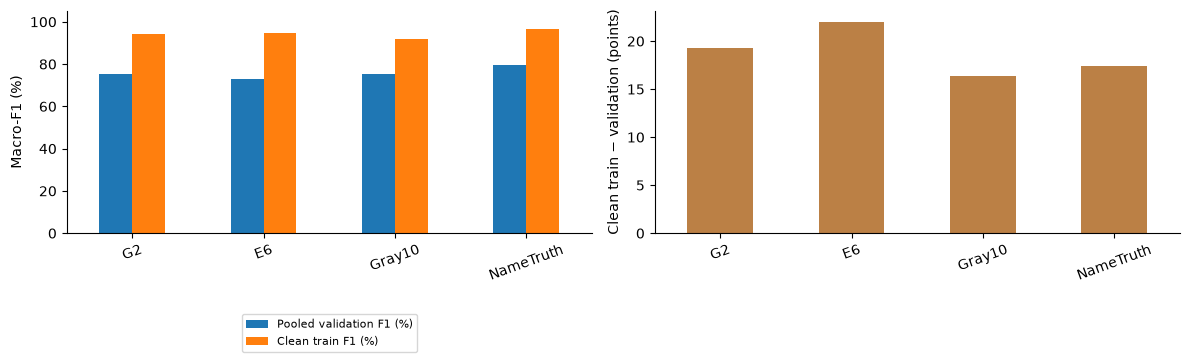

In [26]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**The label change required a separate comparison.** Re-scoring an old model against corrected labels changes the measured training gap even without retraining it. That accounting change cannot be claimed as a learned improvement. The fixed rule uses only one explicit gender cue; ambiguous names stay unchanged. The name-corrected training candidate is then compared against parents on that same basis. The label correction does not certify that every remaining label is visually knowable.


### Locate the classes that contribute to the clean fit gap


model,G2,Gray10,NameTruth
class_name,,,
Boys,3.98,3.65,4.29
Girls,5.21,4.46,4.76
Men,1.10,0.93,0.95
Unisex,7.54,5.98,6.08
Women,1.49,1.33,1.30


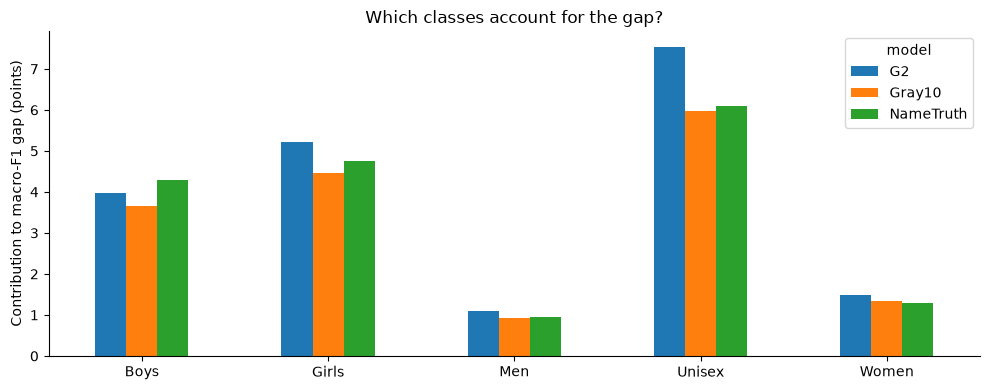

In [27]:
class_gaps=pd.read_csv(
    REPO_DIR / ('reports/task3/gender_name_truth_deep_rev'
        'iew_20260906/class_gap_contributions.csv'), keep_default_na=False)
gap_plot=class_gaps.groupby(['model','class_name']).contribution_to_macro_gap.mean().unstack(0).mul(100)
display(gap_plot.round(2))
fig,ax=plt.subplots(figsize=(10,4))
gap_plot.plot.bar(ax=ax,rot=0)
ax.set(ylabel='Contribution to macro-F1 gap (points)',xlabel='',
       title='Which classes account for the gap?')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_class_gap.png", dpi=150, bbox_inches="tight")
plt.show()

Boys, Girls and Unisex contribute about 87.1% of the remaining macro gap. The model misses 337 of 707 Unisex products in the deep review. Watches, fragrances and shoes can have weak audience cues while their training types carry strong label priors. Good training fit on these groups and poor held-family performance is consistent with learning catalogue-specific associations.

The unchanged-label subset also improves (about 76.98% to 78.45% F1), with a barely positive uncertainty bound. That supports some real learning beyond score changes on relabelled rows. It is still one seed and two selected folds; class priors, family variation and label ambiguity remain competing explanations.


### View the audited remaining errors


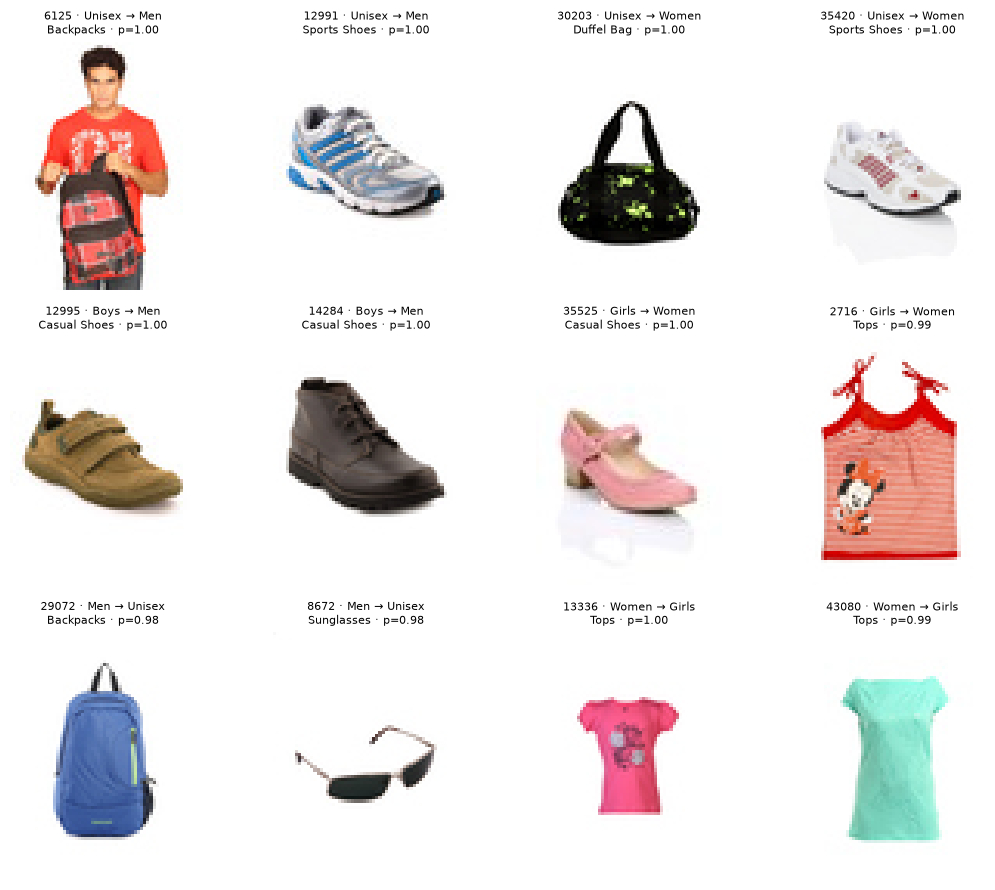

In [28]:
visual_cases=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_name_truth_deep_review_20260906/visual_cases.csv',
        keep_default_na=False)
fig,axes=plt.subplots(3,4,figsize=(11,9))
for ax,row in zip(axes.flat,visual_cases.itertuples()):
    assert row.id in set(development.id)
    with Image.open(REPO_DIR/row.path) as image:
        ax.imshow(image.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label} → {row.predicted_label}\n{
        row.articleType} · p={row.confidence:.2f}',fontsize=8)
    ax.axis('off')
fig.tight_layout()
fig.savefig(FIGURES / "name_truth_error_gallery.png", dpi=150, bbox_inches="tight")
plt.show()

**The examples locate the remaining difficulty.** The selected errors include bags, shoes and clothing whose
intended audience may depend on catalogue wording or sizing not visible in a small image. They
illustrate plausible failure modes; this selected gallery cannot estimate their frequency or prove
that all such errors are unavoidable. The class-gap audit, rather than the gallery alone, supports
the focus on Boys, Girls and Unisex. Since the corrected-label model still overfits those classes,
MixUp is the next test of memorisation under the same corrected-label basis.


## 13. Test regularisation: MixUp, stronger blending, BatchNorm and SAM

The reviewed labels clarified part of the target, but the remaining gap still concentrated
in Boys, Girls and Unisex. MixUp addressed this remaining memorisation by blending training
examples and their targets, while preserving the corrected-label comparison basis.

Zhang et al. [13] motivate this test by training on convex combinations of images and labels,
encouraging smoother behaviour between examples. We test alpha 0.20 locally; published gains
on other datasets do not establish that mixing preserves useful cues in tiny fashion images.


### Inspect the audited MixUp 0.20 improvement


,Pooled validation F1 (%),Clean train F1 (%),Mean gap (points)
model,,,
G2,75.12,94.41,19.32
E6,72.87,94.89,22.01
Gray10,75.49,91.84,16.35
NameTruth,79.44,96.80,17.38
MixUp,80.89,93.81,12.91


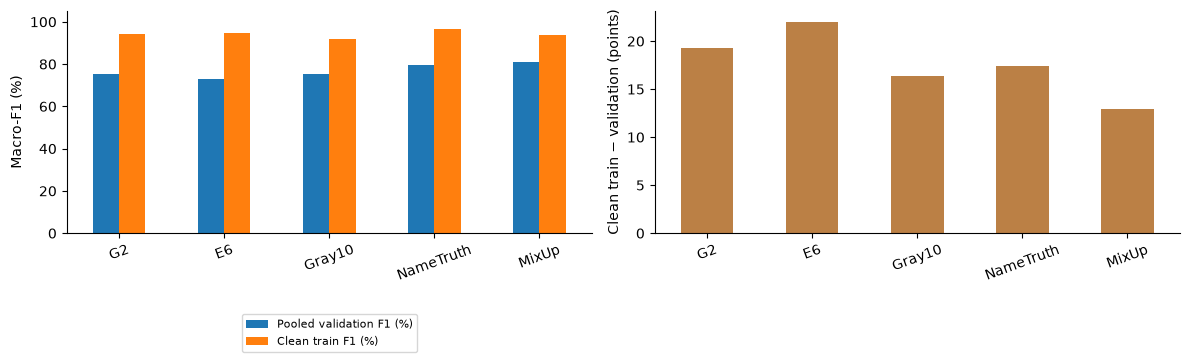

In [29]:
audit = pd.read_csv(
    REPO_DIR / 'reports/task3/gender_mixup_result_20260906/verified_summary.csv',
        keep_default_na=False)
audit = audit.loc[audit.basis.eq('name_truth')].copy()
audit_values = audit.set_index('model')[['pooled_validation_f1', 'mean_train_f1',
    'mean_gap']].mul(100)
audit_values.columns = ['Pooled validation F1 (%)','Clean train F1 (%)','Mean gap (points)']
display(audit_values.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
audit_values.iloc[:, :2].plot.bar(ax=axes[0], rot=20)
audit_values.iloc[:, 2].plot.bar(ax=axes[1], rot=20, color='#bb8045')
axes[0].set(ylabel='Macro-F1 (%)', ylim=(0,105), xlabel='')
axes[0].legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5,-.34))
axes[1].set(ylabel='Clean train − validation (points)', xlabel='')
fig.tight_layout()
fig.savefig(FIGURES / "mixup_result_20260906.png", dpi=150, bbox_inches="tight")
plt.show()

**Hypothesis.** Soft targets on blended training examples discourage an overconfident boundary tightly fitted to each image. Blending occurs only inside the current training batch; validation remains clean.

**Result.** With alpha 0.20, matched pooled F1 rises from 79.44% to 80.89%, and the clean gap falls from 17.38 to 12.91 points. Much of the F1 gain comes from Boys and Girls; the total error count changes little. Macro-F1 can rise because errors shift away from small classes even when accuracy barely moves.

**Stronger blending did not improve the trade-off.** The stronger setting reaches about 79.87% in the matched IEEE audit and a 12.20-point mean gap. The gap improves by only 0.72 points while pooled F1 falls by about 1.02 points, fold 0's gap worsens, and Unisex does not improve. More blending can remove class-specific evidence as well as discourage memorisation. The saved registry score is about 79.94%; this small numeric-basis difference is kept explicit. Alpha 0.20 stays the parent.

The retained alpha 0.20 setting thus became the basis for the next experiment. The remaining
gap motivated a change to the weight update, while the failed stronger blend discouraged
treating additional regularisation as an automatic improvement.

**The cheap BatchNorm repair also failed.** A training-only pass recalculated the four layers'
stored means and variances with clean images, while freezing every learned weight. On the same
two folds, F1 fell from 80.8909% to 80.7155%; the mean gap was effectively unchanged
(12.9133 versus 12.9130 points), and two fewer Unisex images were correct. Both diagnostic
runs are registered, with submission eligibility disabled. This supports keeping the original
normalization buffers. It is not a new gradient-trained candidate.

**Do not infer an unavoidable ceiling.** The weak classes have far fewer training families;
roughly 90% of random MixUp partners are adult-class images. Stronger blending might hide useful
details, but the scores do not prove that cause. The observed child-class regressions are enough
to reject alpha 0.40 under this comparison without inventing a causal explanation.


### Test the weight update alongside the other regularisation options

SAM tests a different update rule after stronger MixUp and the BatchNorm probe failed.
Compare its reduction in clean training gap with its validation, class and corruption results.
A smaller gap alone does not determine which model to select. SAM30 and SAM25 are two
alternatives in the same investigation as dropout, weight decay and the MixUp strengths.


### From the SAM update to a fixed 25-epoch recipe

SAM checks the loss after a small weight perturbation, then makes one update from that second gradient.
It keeps the same architecture and MixUp. The 30-epoch run and its learning curves led to a new fixed
25-epoch recipe, retaining the original 30-epoch cosine schedule. This choice used development evidence.
The final checkpoint is epoch 25, not a best epoch chosen afterwards.


### Inspect the SAM30 epoch diagnostic


,epoch,mean_train_f1,mean_validation_f1,mean_gap,pooled_validation_f1,unisex_correct,unisex_support,unisex_recall
0,10,0.7840,0.7322,0.0518,0.7327,252,707,0.3564
1,15,0.8352,0.7727,0.0625,0.7740,319,707,0.4512
2,20,0.8727,0.7796,0.0931,0.7804,330,707,0.4668
3,25,0.8980,0.7986,0.0994,0.7986,361,707,0.5106
4,30,0.9030,0.7943,0.1087,0.7943,356,707,0.5035


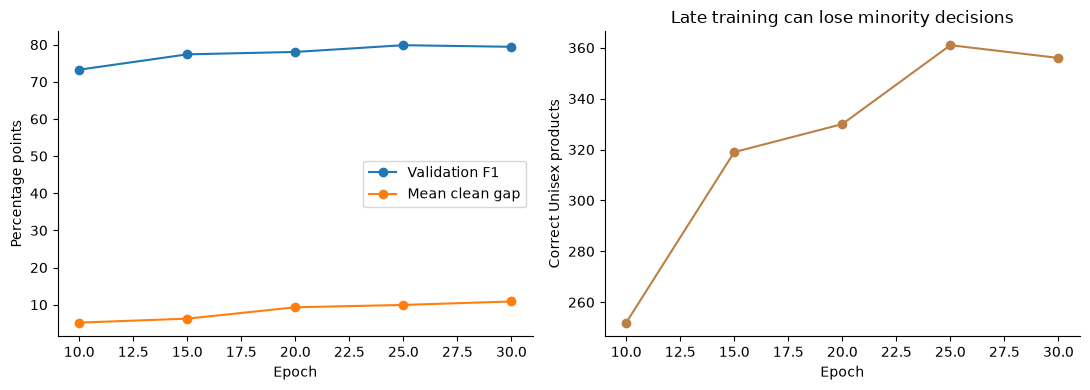

In [30]:
sam_epochs=pd.read_csv(
    REPO_DIR / 'reports/task3/gender_sam_result_20260906/epoch_summary.csv', keep_default_na=False)
display(sam_epochs.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(sam_epochs.epoch,100*sam_epochs.pooled_validation_f1,marker='o',label='Validation F1')
axes[0].plot(sam_epochs.epoch,100*sam_epochs.mean_gap,marker='o',label='Mean clean gap')
axes[0].set(xlabel='Epoch',ylabel='Percentage points')
axes[0].legend()
axes[1].plot(sam_epochs.epoch,sam_epochs.unisex_correct,marker='o',color='#bb8045')
axes[1].set(xlabel='Epoch',ylabel='Correct Unisex products',
    title='Late training can lose minority decisions')
fig.tight_layout()
fig.savefig(FIGURES / "sam_epoch_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()

### Read the matched screen trade-off


,model,validation_f1,mean_gap,mean_clean_train_f1,unisex_correct,unisex_support,errors,nll,ece_15
0,MixUp 0.2,0.8089,0.1291,0.9381,361,707,1192,0.2703,0.0132
1,SAM 30,0.7943,0.1086,0.9029,356,707,1237,0.2788,0.0203
2,SAM 25,0.7986,0.0993,0.8979,361,707,1245,0.2828,0.0279


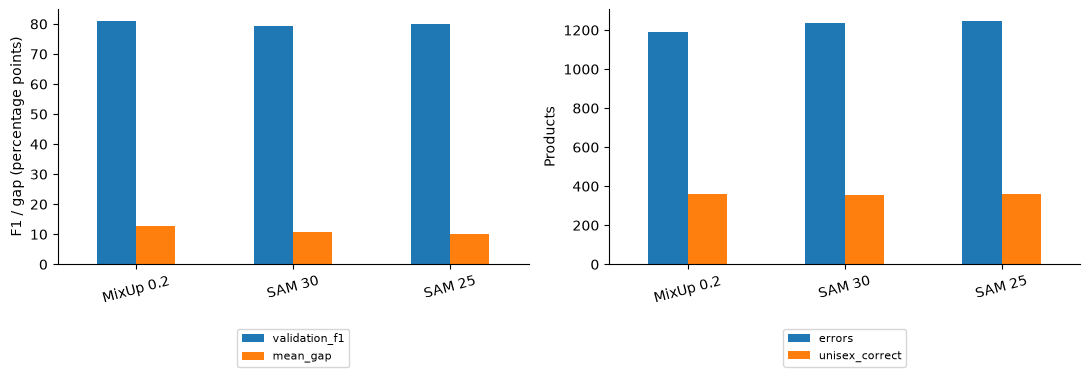

In [31]:
sam_screen=pd.read_csv(REPO_DIR / 'reports/task3/gender_sam25_result_20260906/comparison.csv',
    keep_default_na=False)
display(sam_screen.round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
sam_screen.set_index('model')[['validation_f1','mean_gap']].mul(100).plot.bar(ax=axes[0],rot=15)
sam_screen.set_index('model')[['errors','unisex_correct']].plot.bar(ax=axes[1],rot=15)
axes[0].set(ylabel='F1 / gap (percentage points)',xlabel='')
axes[1].set(ylabel='Products',xlabel='')
for ax in axes:
    ax.legend(fontsize=8,loc='upper center',bbox_to_anchor=(.5,-.23))
fig.tight_layout()
fig.savefig(FIGURES / "sam25_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

SAM30 lowers the clean gap to 10.86 points but scores 79.43% F1. It detects 356 Unisex
products versus MixUp's 361 of 707. The epoch diagnostic motivates testing a shorter fixed budget.

SAM25 is a separate run fixed at 25 epochs, **not a best epoch** extracted from SAM30. It
scores 79.86% F1 with a 9.93-point clean gap and restores Unisex detections to 361. Compared
with MixUp, it reduces the gap by 2.98 points but loses 1.03 F1 points, makes 53 more mistakes
and has lower F1 in all five classes. It passes the recorded gap-focused screen, which warrants
the full comparison below; passing that screen does not make it the selected model.

The screen shows a trade-off between training fit and validation performance. The next
section brings every tested Gender recipe into the decision, then uses the matched five-fold
audit to check the two extended recipes in more detail.


## 14. Compare all Gender candidates

The decision covers the full investigation: the original CNN alternatives, the feature-based
and transformer screens, changes to augmentation and regularisation, the label review, both
MixUp strengths and both SAM budgets. Each recipe keeps its own evidence and weaknesses.

The tables below use saved registered confusion counts and the checked five-fold audits.
Read within the same scoring labels and folds. Original-label five-fold scores provide the
broadest common comparison. Corrected-label scores answer a separate question; two-fold
screens cannot be ranked against five-fold totals. A row marked **IEEE audit** re-scores saved
predictions consistently; it does not represent another training run.

Section 2 also accounts for every feature probe and incomplete attempt. Sampled EDA probes,
training checks and the BatchNorm diagnostic inform the analysis but are not interchangeable
with trained models evaluated on the full development population.


In [32]:
from fashion.task3_development import gender_development_comparison

gender_stages = gender_development_comparison(REPO_DIR, selection)
for (labels, folds), group in gender_stages.groupby(['label_basis', 'folds'], sort=False):
    print(f'{labels} scoring labels | folds {folds}')
    display(group[['experiment', 'rows', 'F1 (%)', 'Accuracy (%)', 'Score source']]
        .set_index('experiment').round(2))


Original scoring labels | folds [0, 1, 2, 3, 4]


,rows,F1 (%),Accuracy (%),Score source
experiment,,,,
E1 · SmallCNN,32773,71.18,87.68,Registry
E2 · Brightness,32773,69.89,87.30,Registry
E3 · Class weights,32773,70.81,87.32,Registry
E4 · TinyResNet,32773,71.21,87.71,Registry
E5 · CompactBlurCNN,32773,70.69,88.72,Registry
E6 · GeM pooling,32773,73.35,89.32,Registry
E7 · TinyHRNet,32773,70.25,87.35,Registry
E8 · Early stopping,32773,74.12,89.12,Registry
E9 · Semantic filter,32773,74.51,89.30,Registry


Original scoring labels | folds [0, 4]


,rows,F1 (%),Accuracy (%),Score source
experiment,,,,
Dropout 0.30,13110,75.42,90.16,Registry
Add mild darkening,13110,74.22,90.22,Registry
Add grayscale 10%,13110,74.79,90.09,Registry
E1 · SmallCNN,13110,71.31,87.69,Registry
E6 · GeM pooling,13110,72.30,89.19,Registry
G2 · Translation,13110,74.57,90.31,Registry
G1 · Foreground mask,13110,72.95,89.26,Registry
G3 · Component weights,13110,72.45,89.20,Registry
GD1 · Mild darkening,13110,74.12,90.29,Registry


Name-corrected scoring labels | folds [0, 4]


,rows,F1 (%),Accuracy (%),Score source
experiment,,,,
Name-corrected labels,13110,79.44,90.88,Registry
MixUp alpha 0.20,13110,80.89,90.91,Registry
MixUp alpha 0.40,13110,79.94,90.60,Registry
SAM · 30 epochs,13110,79.43,90.56,Registry
SAM · 25 epochs,13110,79.86,90.50,Registry
Article-group weights,13110,80.10,90.37,Registry


Name-corrected scoring labels | folds [0, 1, 2, 3, 4]


,rows,F1 (%),Accuracy (%),Score source
experiment,,,,
SAM25 · Five folds,32773,79.74,90.46,Registry
MixUp · Five-fold audit,32773,80.46,90.86,IEEE audit
SAM25 · Five-fold audit,32773,79.73,90.46,IEEE audit


### Compare every Gender model visually

All trained development variants are represented below, with the BatchNorm diagnostic shown
separately in orange. Green marks the selected MixUp recipe. The panels preserve the original
and corrected labels and the five-fold versus two-fold populations. The checked five-fold
audits are labelled; re-scoring is not an additional training run. Refits, sampled feature
probes and incomplete attempts remain in the Section 2 inventory rather than receiving
invented OOF scores.

The broad original-label panel connects the final choice to the baseline, pooling, architecture,
early-stopping, filtering and translation branches. The other panels retain every screen and
its trade-offs. Higher F1 alone does not establish the choice: the discussion below also weighs
accuracy, class failures, training fit, confidence, corruption sensitivity and uncertainty.

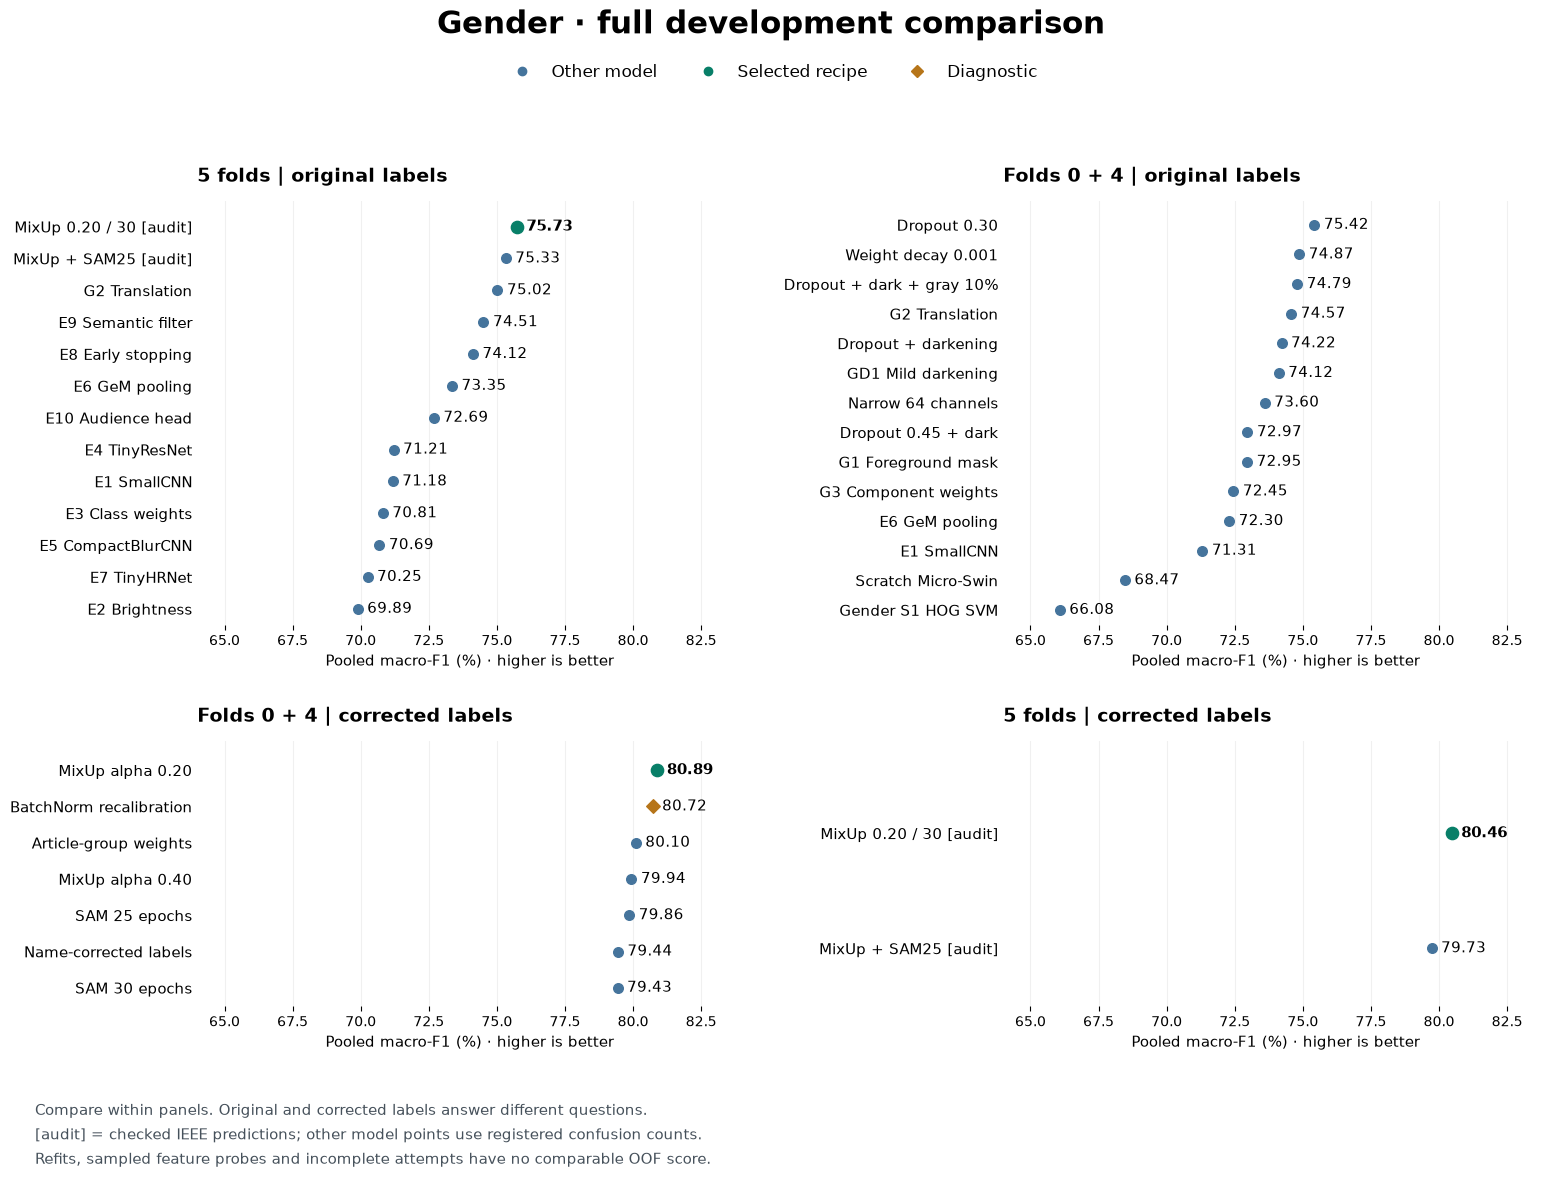

In [33]:
from fashion.task3_comparison_figures import plot_model_comparison

fig = plot_model_comparison(REPO_DIR, "gender", FIGURES.parent)
plt.show()

### What each alternative contributes to the decision

The original ten-model group above uses five folds and original labels. These are separate recipes,
not ten steps whose gains can be added together:

- **E1 SmallCNN (71.18%):** a scratch reference that exposes near-perfect training fit and weak minority classes.
- **E2 brightness (69.89%):** broad brightness augmentation lowers the observed clean score. Later targeted darkening is a separate intervention.
- **E3 class weighting (70.81%):** the tested weighting does not improve equal-class F1 over E1. Giving rare errors more weight is not enough here.
- **E4 TinyResNet (71.21%):** almost tied with E1; its family interval crosses zero and its confidence and translation results worsen.
- **E5 CompactBlurCNN (70.69%):** accuracy rises to 88.72%, but macro-F1 falls below E1. More common-class success does not meet the equal-class aim.
- **E6 GeM (73.35%):** stronger pooled image features improve class separation; this becomes the parent for the detailed fit and corruption audit.
- **E7 TinyHRNet (70.25%):** retaining higher-resolution features does not give the tested recipe a clean-score advantage.
- **E8 early stopping (74.12%):** a modest gain over GeM, but the 25.82-point clean gap misses its 24.66-point target. Its best-checkpoint policy differs from today's fixed epoch rule.
- **E9 semantic filter (74.51%):** a useful point gain, but no demonstrated full solution to class ambiguity or memorisation. It changes which training evidence is used and is not part of the selected recipe.
- **E10 audience head (72.69%):** extra audience supervision falls below GeM; the added task does not justify extra complexity in this trial.

The side-screen group uses folds 0 and 4. **G1 foreground masks (72.95%)** and **G3 component
weights (72.45%)** provide small point gains over matched GeM (72.30%), but do not establish a
better overall solution. **G2 translation (74.57%)** gives the larger score and the measured shift
repair discussed above. **GD1 mild darkening (74.12%)** improves a targeted nuisance at a clean
cost and fails three of its thirteen checks. It is distinct from the later dropout-plus-dark model.

**Weight decay 0.001 (74.87%)** barely changes clean training fit: the gap falls only 0.30 points,
one fold worsens, and six gates fail. **Narrow 64 channels (73.60%)** sacrifices validation score;
less capacity is not a free cure for memorisation. **Dropout 0.30 (75.42% in the registry)** gives
a useful partial gap reduction. Adding darkening gives **74.22%**, then grayscale **74.79%**;
their targeted corruption effects and costs are retained in the preceding analysis. The clean
IEEE audit can differ slightly from runtime registry values and is labelled when used.
**Dropout 0.45 plus darkening (72.97%)** loses too much clean signal to prefer stronger dropout.

**HOG-SVM (66.08%)** and **scratch Micro-Swin (68.47%)** are matched two-fold alternative
learners below GeM, not evidence that those whole method families cannot work. The
**article-group-weighted model (80.10%, corrected labels)** raises macro-F1 over its name-label
parent (79.44%) yet makes 66 more errors and misses the gap target. Its score cannot be compared
directly to the original-label rows. Corrected-label alternatives are assessed separately below.

The tables retain all 32 recorded Gender stage/scope entries and add the four five-fold audit
rows for MixUp and SAM25 under both scoring label sets. Re-scoring a model does not create
another candidate. Refits have no validation score and do not enter this comparison.

The audience-head result is consistent with a cost from the auxiliary task, but does not by itself prove negative transfer (one task harming the other).


### Compare the corrected-label candidates and the broad five-fold results

On the same two screen folds, the name-corrected parent gives **79.44% F1**. Article-group
weighting reaches **80.10%**, but makes 66 more errors than that parent and misses its gap
target. MixUp 0.20 reaches **80.89%** while reducing the clean fit gap from 17.38 to 12.91
points. MixUp 0.40 gives **79.87% in the matched audit** (79.94% in the registry); its small
extra gap reduction costs validation performance. The BatchNorm diagnostic gives **80.72%**
and no useful gap repair. SAM30 gives **79.43%**; SAM25 gives **79.86%** and the smallest
screen gap, **9.93 points**. This supports retaining ordinary MixUp's balance while accepting
that it leaves more memorisation than SAM25.

The five-fold **original-label** comparison includes all ten original CNN recipes, translation,
and the re-scored MixUp and SAM25 fold models. MixUp has the highest observed macro-F1 in
this group at **75.73%**, followed by SAM25 at **75.33%**, translation at **75.02%**, semantic
filtering at **74.51%**, and early stopping at **74.12%**. This common-label comparison connects
the final choice to the wider study. It does not isolate the effect of MixUp: the later recipes
also include GeM, augmentation, dropout and corrected training labels.

MixUp's **90.03% original-label accuracy** is lower than translation's **90.34%**. The decision
therefore favours the observed equal-class balance rather than claiming to win every metric.
No paired uncertainty test against every earlier model is available. The detailed audit below
tests the matched MixUp and SAM25 recipes; its intervals cannot establish a win over the whole
search or turn two-fold screens into five-fold evidence.


### Check the two extended recipes on matched five-fold evidence

Both recipes predict the same 32,773 development rows, each from the model that excluded its
saved fold. They share the 22,905 product families, fixed corrected labels, class order,
fold-fitted normalization, GeM architecture and augmentation. The label rule changes 350
development labels; original-label checks remain separate. The saved audit checks the six new
checkpoints, source lineage, registry entries, final epochs, normalization and training receipts.

This is a comparison of **MixUp/30 against MixUp + SAM/25**, not an isolated SAM effect.
MixUp trained on A100; SAM on L4. The shared seed and precision policy do not remove hardware
variation. Final saved predictions use matching IEEE FP32 evaluation. The original MixUp screen
was 80.89%; the new runs on the same screen folds give 81.28%. Keep both, rather than replacing
the older result with the more favourable rerun.


In [34]:
report_metrics = selection_metrics.copy()
percent_rows = ['macro_f1', 'accuracy', 'ece_15', 'mean_clean_training_f1', 'mean_gap', 'fold_f1_std']
report_metrics.loc[percent_rows] *= 100
report_metrics.index = ['Pooled F1 (%)', 'Accuracy (%)', 'NLL (lower better)',
    'Brier (lower better)', 'ECE, 15 bins (%)', 'Mean clean training F1 (%)',
    'Mean fold gap (points)', 'Fold F1 sample SD (points)']
display(report_metrics.round(4))
fold_comparison = pd.read_csv(MIXUP_REVIEW/'fold_comparison.csv')
display(fold_comparison.pivot(index='fold', columns='model', values=['macro_f1', 'gap']).mul(100).round(2))


,MixUp,SAM25
Pooled F1 (%),80.4639,79.7258
Accuracy (%),90.8553,90.4617
NLL (lower better),0.2675,0.2811
Brier (lower better),0.1373,0.1440
"ECE, 15 bins (%)",1.1435,2.7652
Mean clean training F1 (%),93.7964,89.8566
Mean fold gap (points),13.3692,10.1530
Fold F1 sample SD (points),0.9354,0.8146


macro_f1           gap       
model    MixUp  SAM25  MixUp  SAM25
fold                               
0        80.87  79.81  12.62   9.52
1        80.32  79.36  13.21   9.96
2        79.17  78.60  14.51  11.56
3        80.09  80.83  14.12   9.38
4        81.69  79.92  12.38  10.35

**The primary score favours MixUp:** 80.46% corrected-label pooled F1 versus 79.73%,
with accuracy 90.86% versus 90.46%. It wins four folds; SAM wins fold 3 by 0.74 points.
MixUp's worst fold is 79.17%, compared with 78.60% for SAM. It fixes 571 SAM errors and
adds 442 new ones, leaving 129 fewer errors. None of these are independent refit scores.

**Why SAM's smaller gap does not settle the choice.** Mean clean training F1 falls by 3.94
points with SAM, while mean validation F1 falls by about 0.72. Most of SAM's 3.22-point gap
reduction comes from fitting training rows less well. That is regularisation, but it does not
produce the better held-family score here. MixUp's 13.37-point gap is still a weakness;
it is not acceptable merely because another metric improves. The gap is an average of
within-fold differences, not mean training F1 minus pooled validation F1.

**The confidence evidence also favours MixUp.** NLL falls from 0.2811 to 0.2675 and Brier error
from 0.1440 to 0.1373; both score the full predicted probabilities. ECE, the difference between
confidence and observed correctness in 15 bins, falls from 2.77% to 1.14%. No calibration was
fitted. ECE depends on its bins, and an aggregate improvement cannot validate a rare-class
automation threshold. Fold spread is slightly worse for MixUp (0.94 versus 0.81 points);
overlapping training folds are not independent replications.


### Bootstrap: show the uncertainty, including the near-zero bound

The paired bootstrap draws whole families within each canonical fold and uses identical draws
for both models. It calculates five-class macro-F1 for each draw, with seed 2753. The saved
10,000-draw analysis is retained; 100,000 draws check whether its barely positive lower endpoint
is stable. Extra draws reduce simulation noise, not uncertainty from limited independent data.


In [35]:
interval_table = selection_intervals.copy()
interval_table[['point', 'lower_95', 'upper_95']] *= 100
interval_table.index = ['All five · 10,000 draws', 'All five · 100,000 draws',
    'Screen folds 0 and 4', 'Additional folds 1, 2 and 3', 'Original teacher labels · all five']
interval_table.columns = ['F1 gain (points)', '95% lower', '95% upper', 'Draws']
display(interval_table.round(4))


,F1 gain (points),95% lower,95% upper,Draws
"All five · 10,000 draws",0.7381,0.0094,1.4952,10000.0
"All five · 100,000 draws",0.7381,-0.0080,1.4917,100000.0
Screen folds 0 and 4,1.4192,0.3766,2.4748,10000.0
"Additional folds 1, 2 and 3",0.2701,-0.7555,1.3282,10000.0
Original teacher labels · all five,0.4068,-0.3788,1.1960,10000.0


The all-fold gain is **+0.74 points**. Its 10,000-draw interval barely clears zero
(+0.0094 to +1.4952 points), but the 100,000-draw interval is **−0.0080 to +1.4917**.
The lower bound crosses zero. Claiming a reliably significant win would overstate this result.

The screen-fold gain is +1.42 points with interval +0.38 to +2.47. On additional folds 1–3,
the gain shrinks to **+0.27 points**, with interval **−0.76 to +1.33**. Those additional folds
extend the evidence but do not independently establish superiority. On original teacher labels,
MixUp gives 75.73% versus 75.33% F1: +0.41 points, interval **−0.38 to +1.20**. Accuracy
and all three probability-quality measures also favour MixUp on that label basis.

These intervals condition on the already trained models and sampled families. They do not
cover new training seeds, hardware differences or the repeated choice among many experiments.
They are separate intervals without a multiple-comparison correction. The decision is a
practical judgement over several measured outcomes, not a claim that bootstrap proves a winner.


### Robustness: separate final score from sensitivity to damage

The saved fold predictions use five fixed, mild changes. Compare both the corrupted score and
the loss from each model's own clean pooled score. Those answer different questions. Lower
damage alone does not imply a better final prediction, and higher damaged-image F1 does not
imply lower sensitivity. Mean-fold drops are stored separately and not substituted below.


,MixUp F1 (%),SAM25 F1 (%),MixUp drop,SAM25 drop,F1 gain,95% lower,95% upper
corruption,,,,,,,
jpeg_75,79.37,78.98,1.09,0.75,0.40,-0.38,1.19
brightness_085,78.72,77.48,1.74,2.25,1.25,0.29,2.21
brightness_115,77.23,77.05,3.24,2.68,0.18,-0.72,1.10
grayscale,77.64,77.21,2.83,2.52,0.43,-0.39,1.23
translation_003,76.24,75.54,4.23,4.18,0.69,-0.17,1.54


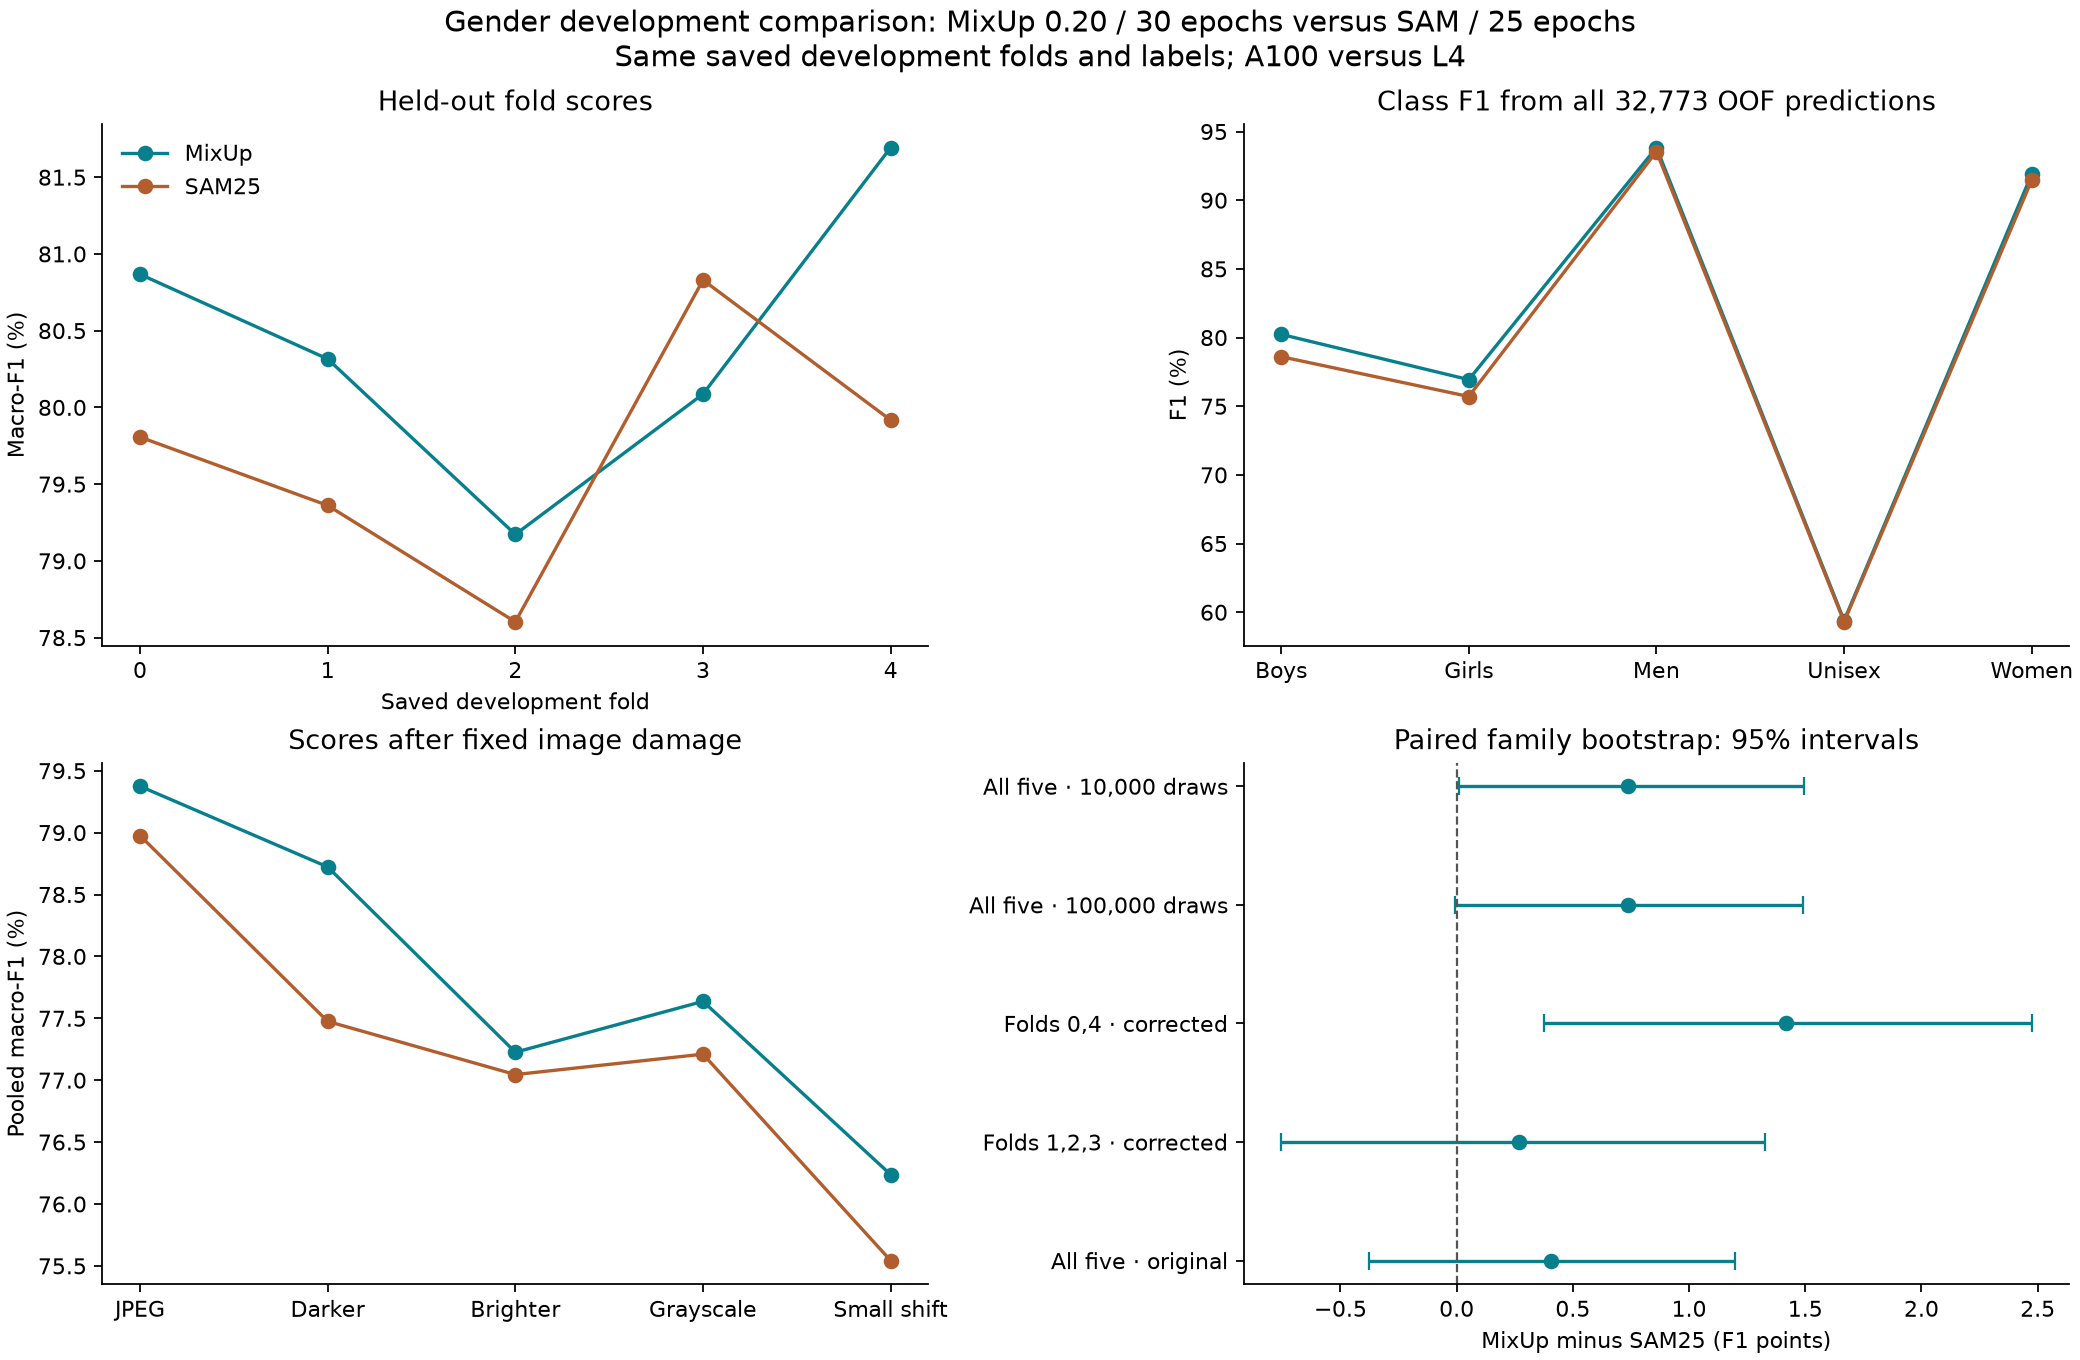

In [36]:
robustness = pd.read_csv(MIXUP_REVIEW/'robustness_comparison.csv')
robust_table = robustness.set_index('corruption')[['mixup_f1', 'sam25_f1',
    'mixup_pooled_drop', 'sam25_pooled_drop', 'difference', 'lower_95', 'upper_95']].mul(100)
robust_table.columns = ['MixUp F1 (%)', 'SAM25 F1 (%)', 'MixUp drop', 'SAM25 drop',
    'F1 gain', '95% lower', '95% upper']
display(robust_table.round(2))
display(Image.open(REPO_DIR/'results/figures/task3/gender_mixup_selection_20260911.png'))


MixUp has higher corrected-label F1 under every tested corruption. Darkening gives the
clearest gain: +1.25 points, interval +0.29 to +2.21. JPEG, brightening, grayscale and translation
have intervals that cross zero. Translation is the worst condition for both: 76.24% for MixUp
and 75.54% for SAM. MixUp still loses 4.23 points from clean F1.

SAM loses less relative to its own clean score in four of five conditions. Only darkening
gives MixUp the smaller drop. On original teacher labels, SAM also wins the brighter-image
score (73.28% versus 73.13%), and JPEG is nearly tied. Therefore MixUp has the better observed
overall balance, not universal robustness dominance. These mild catalogue-image checks do not
establish performance on severe crops or phone photos, and they score fold models, not the refit.


### Class results and concrete regressions

Macro-F1 treats the five classes equally, but an average can hide a nearly unchanged weak class.
The table pairs class scores with actual support. The error slices show where the overall gain
helps and where it costs correct predictions.


In [37]:
class_comparison = pd.read_csv(MIXUP_REVIEW/'class_comparison.csv')
display(class_comparison.pivot(index='class_name', columns='model', values=['f1', 'recall']).mul(100).round(2))
display(class_comparison.loc[class_comparison.model.eq('MixUp'), ['class_name', 'support']].set_index('class_name'))
article_changes = pd.read_csv(MIXUP_REVIEW/'article_error_changes.csv')
article_changes = article_changes.sort_values('net_correct')
display(pd.concat([article_changes.head(6), article_changes.tail(6)])
    [['gender', 'articleType', 'rows', 'fixed', 'new_errors', 'net_correct']]
    .set_index(['gender', 'articleType']))


f1        recall       
model       MixUp  SAM25  MixUp  SAM25
class_name                            
Boys        80.24  78.61  78.57  76.84
Girls       76.93  75.71  73.14  72.57
Men         93.84  93.54  95.69  95.14
Unisex      59.39  59.30  51.11  50.82
Women       91.92  91.47  91.54  91.47

,support
class_name,
Boys,868
Girls,700
Men,17572
Unisex,1763
Women,11870


rows  fixed  new_errors  net_correct
gender articleType                                                
Women  Perfume and Body Mist   201      6          17          -11
Men    Sports Shoes           1314      7          15           -8
Unisex Caps                    117      6          13           -7
Men    Belts                   443      4           8           -4
Women  Highlighter and Blush     4      0           4           -4
       Shirts                  233      0           4           -4
Men    Deodorant               158     10           1            9
Girls  Tops                    259     15           5           10
Women  Watches                 683     45          34           11
Men    Caps                     94     18           6           12
       Watches                1105     39          21           18
       Perfume and Body Mist   266     24           4           20

All five class F1 point estimates improve. Boys rise from 78.61% to 80.24%, Girls from
75.71% to 76.93%, Men from 93.54% to 93.84%, and Women from 91.47% to 91.92%.
**Unisex remains unresolved:** 59.39% versus 59.30% F1, with recall only 51.11% versus 50.82%.
MixUp detects 901 of 1,763 Unisex products and misses 862; 528 become Men and 280 become Women.
Its Unisex clean class gap is 23.55 points, against SAM's 14.68. A smaller SAM training fit
does not materially improve that validation class.

MixUp loses 11 correct Women perfume/body-mist products, eight Men sports shoes and seven
Unisex caps. It gains 20 Men perfume/body-mist products, 18 Men watches and ten Girls tops.
These slices are descriptive; small counts do not support independent significance claims.
The earlier development error gallery illustrates audience ambiguity, but does not prove these
new errors have the same cause. Keep human review for uncertain catalogue tags.


## 15. Choose the Gender recipe, then refit

**Select MixUp alpha 0.20 with a fixed 30-epoch budget from the development comparisons.**
This fixes the recipe for the full-development refit. The choice uses the fold models'
results; refit training loss is not evidence for choosing a recipe.

The choice follows the full comparison in Section 14. GeM improves on the SmallCNN baseline;
the tested residual, blur, high-resolution, auxiliary-head, HOG-SVM and Micro-Swin alternatives
do not justify replacing that feature learner. Brightness-only training and class weighting do
not improve the original baseline's macro-F1. Translation supplies useful shift tolerance but
leaves a large fit gap and lighting weakness. Foreground masks, component weighting, stronger
weight decay, a narrower head, stronger dropout, early stopping and semantic filtering each
leave documented score, gap or robustness limits. Dropout and targeted augmentation inform
the retained recipe without resolving the task on their own.

On corrected labels, MixUp 0.20 improves the parent and offers a better observed score/gap
balance than article-group weighting, stronger blending and BatchNorm recalibration. SAM's
smaller gap comes with lower class F1 and worse probability quality. The extended MixUp recipe
also has the highest observed macro-F1 in the original-label five-fold comparison, linking
this decision back to the earlier models on a common scoring basis.

The choice accepts a **13.37-point corrected-label fit gap**, weak Unisex recognition, the
original-label accuracy loss versus translation, and the uncertain +0.74-point corrected-label
lead over SAM25. The 100,000-draw interval crosses zero. These are reasons to limit the claim,
not reasons to present the chosen recipe as certainly superior to every alternative.

The next step trains fresh weights on all **32,773 development images** for the fixed
**30 epochs**, then keeps the epoch-30 checkpoint. No validation score, early stopping or
refit loss minimum changes that choice.


### Check every fold's learning history and the separate refit

The curves use recorded runtime values. Mixed-target training macro-F1 is undefined, so no
missing training F1 is invented. The two figures show validation F1 and the two losses for each
MixUp fold, compare final clean gaps, and show the separate full-development training loss.
The clean gap comes from the evaluation-mode audit, not online augmented training scores.

Mixed training loss and clean validation loss use different targets. Their relative height is not a clean generalisation-gap measurement.


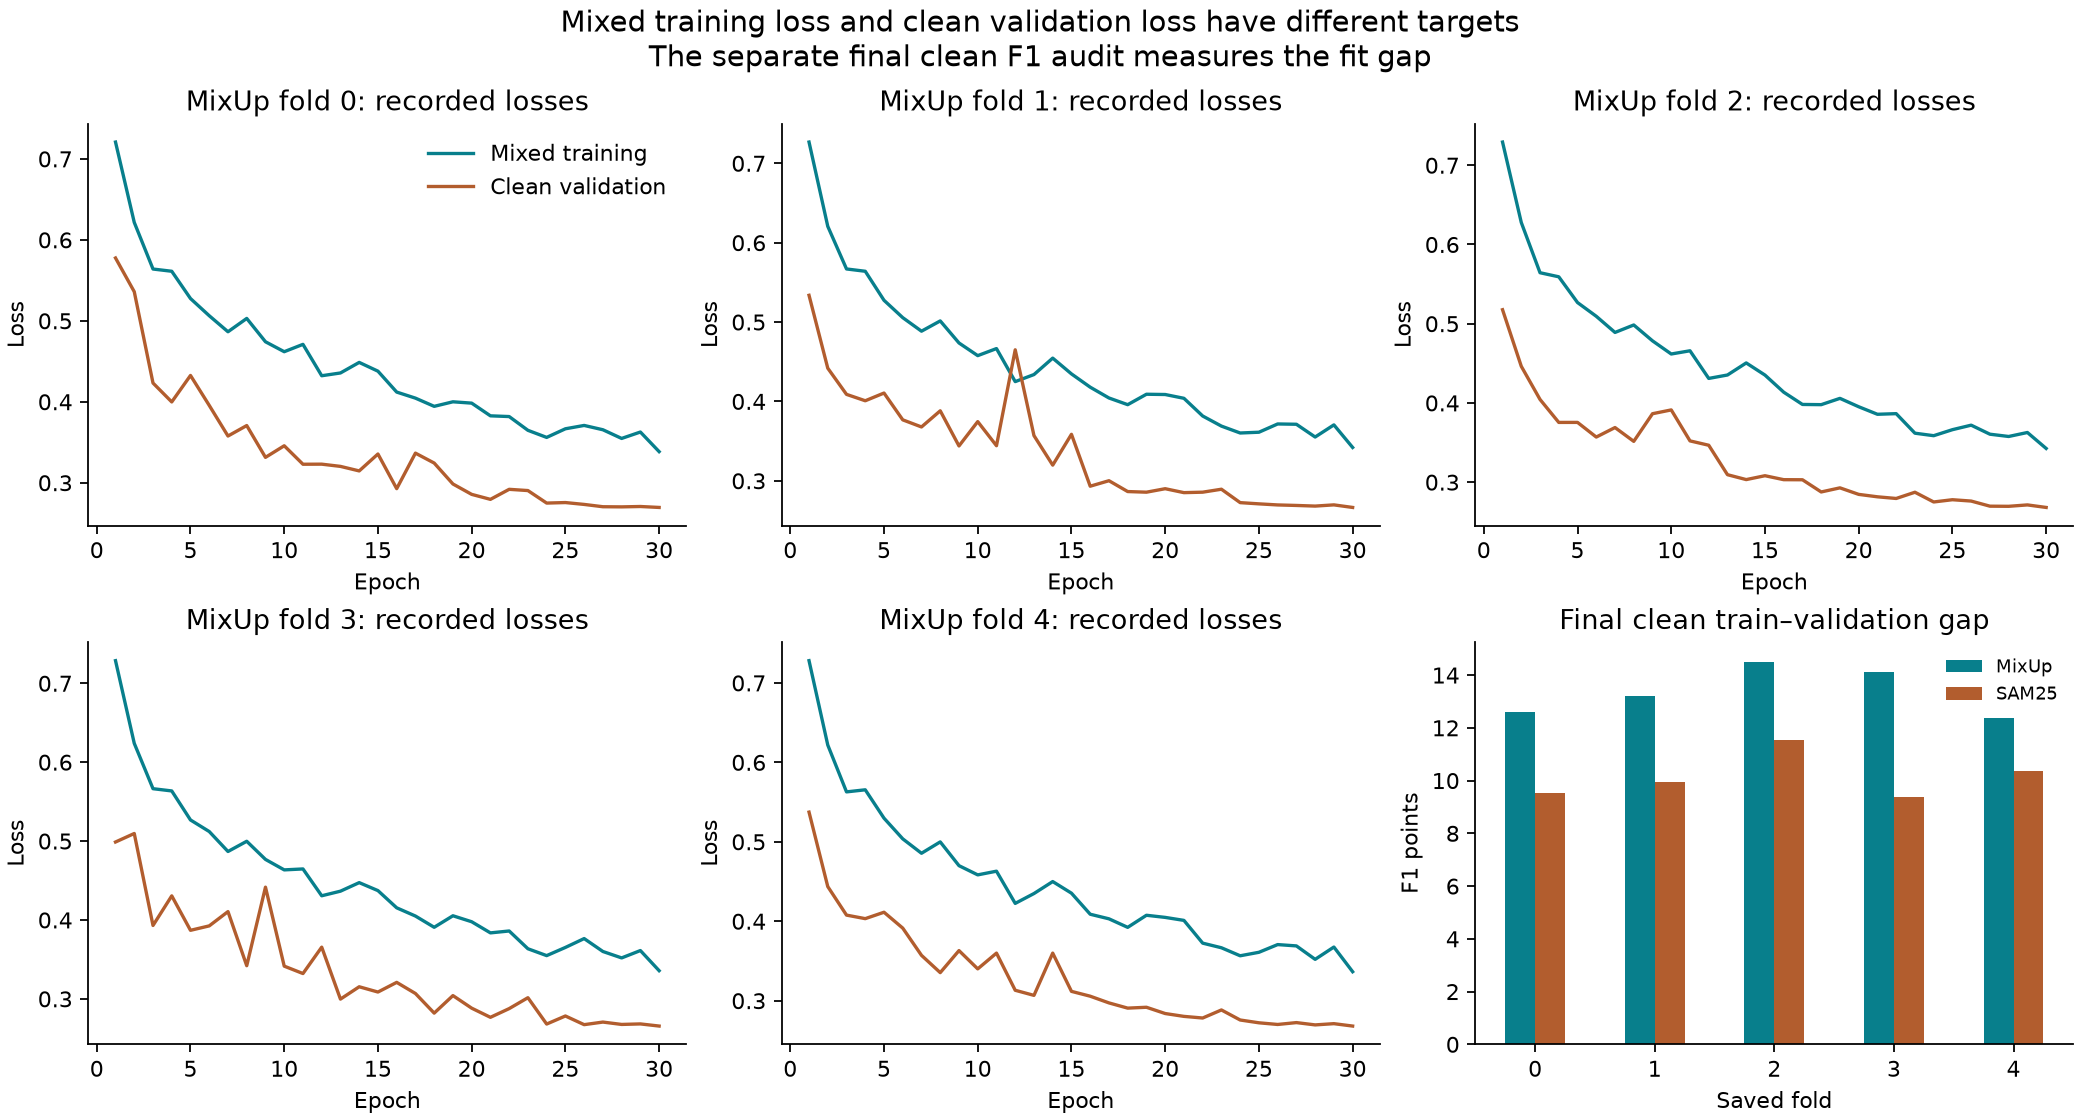

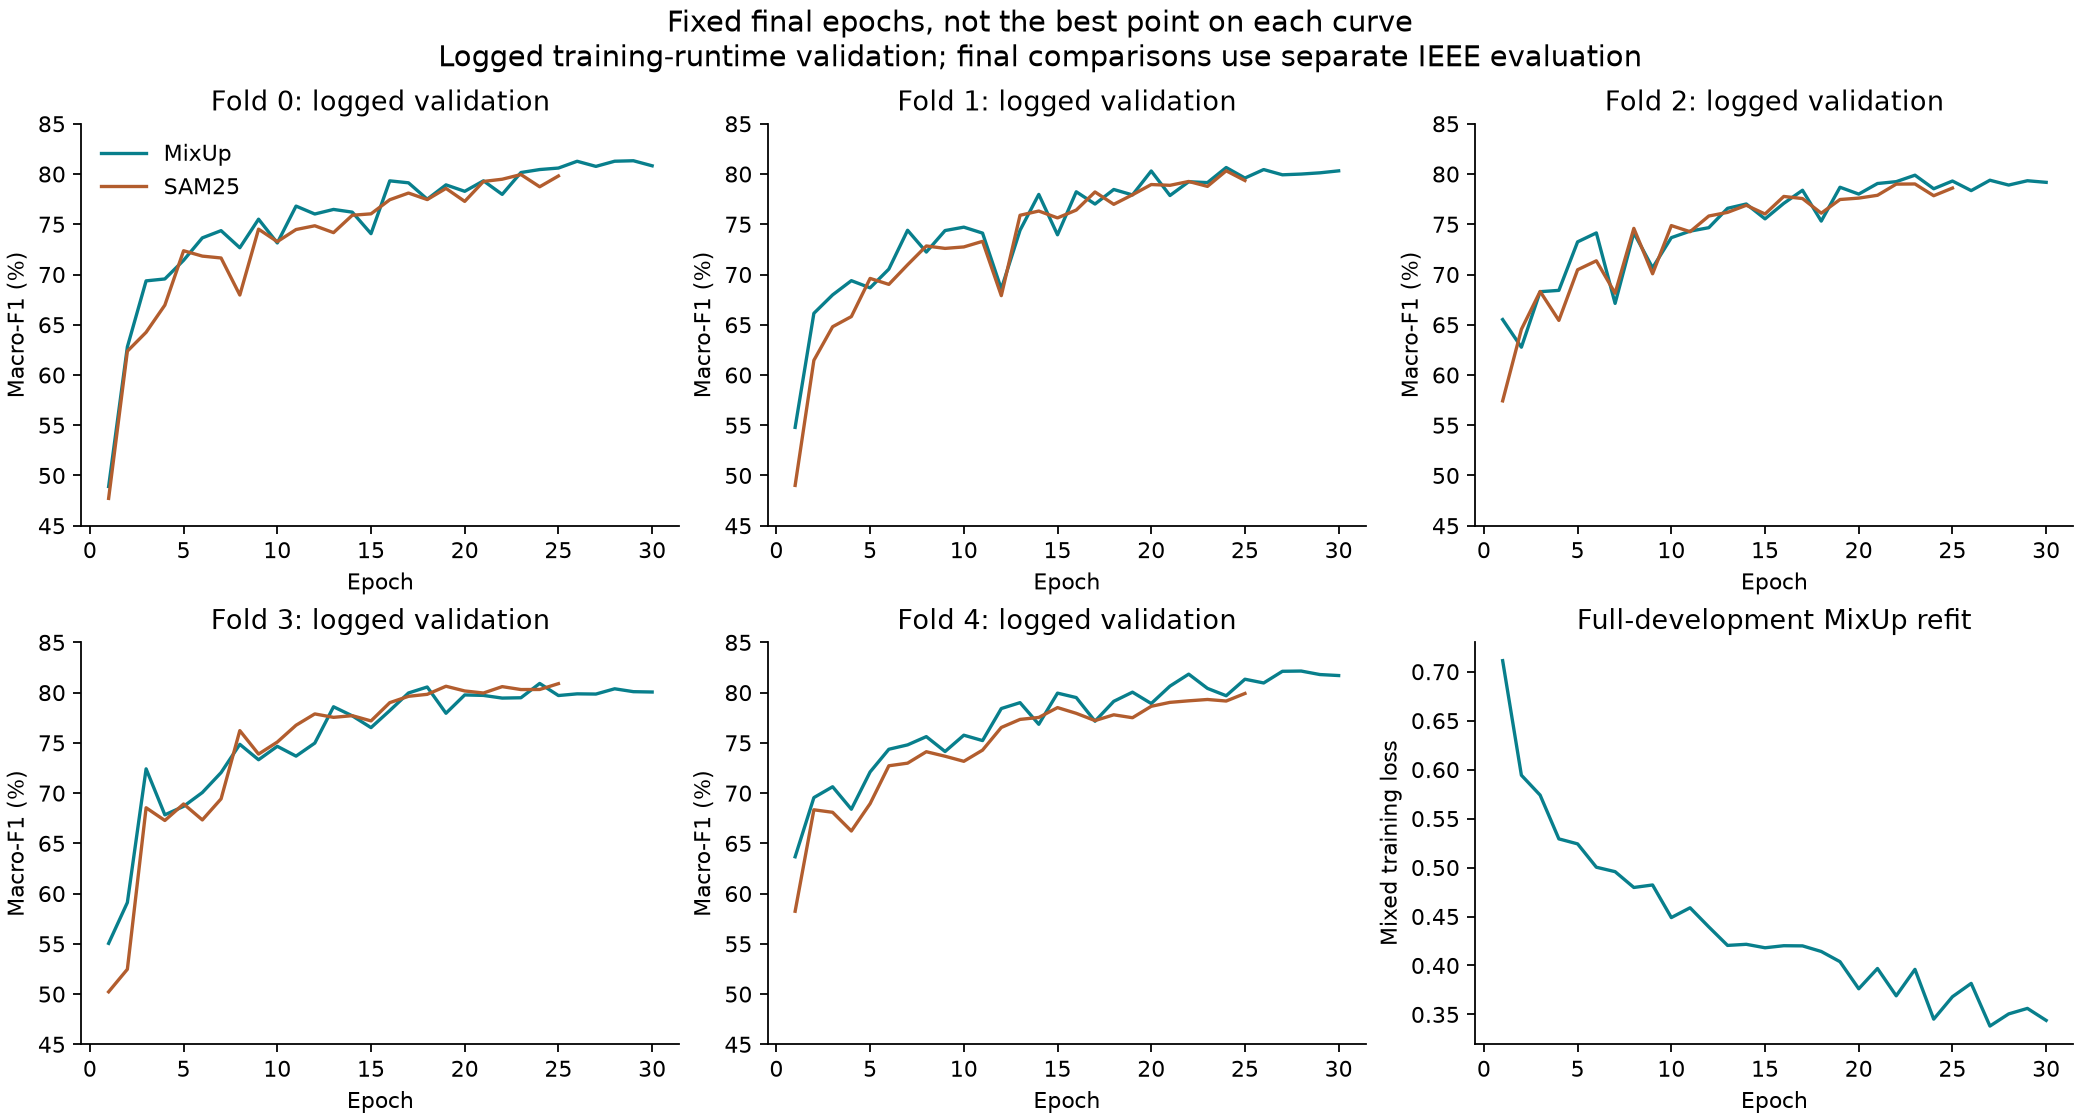

,epochs_completed,training_rows,validation_rows,train_seconds,peak_memory_bytes
0,30,32773,0,559.789713,476603392


In [38]:
display(Image.open(REPO_DIR/'results/figures/task3/gender_mixup_fold_losses_20260911.png'))
display(Image.open(REPO_DIR/'results/figures/task3/gender_mixup_learning_curves_20260911.png'))
gender_final_manifest = verify_mixup_selection(REPO_DIR)
gender_history = pd.read_csv(REPO_DIR/gender_final_manifest['history']['path'])
assert gender_history.epoch.tolist() == list(range(1, 31))
assert gender_history.training_rows.eq(32773).all()
assert gender_history.optimizer_steps.eq(257).all()
display(pd.DataFrame([selection['refit']['metrics']])[
    ['epochs_completed', 'training_rows', 'validation_rows', 'train_seconds', 'peak_memory_bytes']])


The fold histories show continued learning with fluctuations, not a reason to pick each
fold's most favourable epoch. All five runs use the fixed final epoch 30. The new refit starts
from scratch on all **32,773 development images**, with 30 epochs and 257 updates per epoch:
**7,710 updates**. It uses no validation selection or early stopping.

Its mixed training loss falls from 0.7113 to 0.3439. The saved run completes in 559.8 seconds
(9 minutes 20 seconds), with 476.6 MB of peak allocated GPU memory on A100. The CV fits total
about 44.5 minutes versus SAM's 39.8 on L4; different hardware and evaluation work prevent a
fair speed claim. Both selected-recipe and SAM refits have the same single-model inference
architecture. Ordinary MixUp simplifies the training update; that does not establish faster serving.

The refit has no independent OOF score or validation curve. The 80.46% result and corruption
tests belong to the five fold models. Training completion and finite weights establish a usable
artifact, not new evidence of unseen-image accuracy.


### Verify the fixed refit schedule


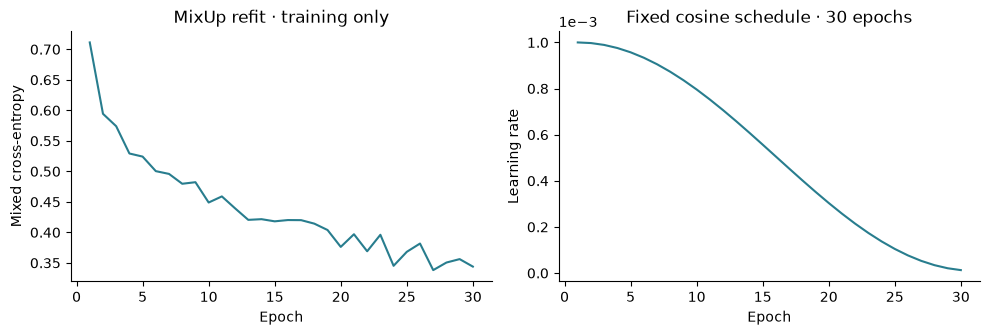

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].plot(gender_history.epoch, gender_history.train_mixed_loss, color='#287d8e')
axes[0].set(xlabel='Epoch', ylabel='Mixed cross-entropy', title='MixUp refit · training only')
axes[1].plot(gender_history.epoch, gender_history.learning_rate, color='#287d8e')
axes[1].set(xlabel='Epoch', ylabel='Learning rate', title='Fixed cosine schedule · 30 epochs')
axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
fig.tight_layout()
fig.savefig(FIGURES/'gender_mixup_refit_schedule.png', dpi=150, bbox_inches='tight')
plt.show()


### Selected Gender recipe and evaluation handoff

**Use the single MixUp 0.20 refit, epoch 30.** Keep scratch GeM p=3, channels 32/64/128/256,
390,181 parameters, dropout 0.30, seed 2753, batch 128, AdamW learning rate 0.001 and weight
decay 0.0001. Use cosine T_max=30 and minimum rate 0.00001. Keep translation up to two pixels
with probability 0.5, mild darkening with probability 0.25 and grayscale with probability 0.10.
There is no SAM update in this selected recipe.

For inference, use EXIF orientation, aspect-preserving LANCZOS resize to an 80×60 canvas,
centred letterboxing and the refit's own full-development content-pixel normalization.
Padding is zero after transformation. Use evaluation mode, softmax then argmax in the saved
class order, one checkpoint per image. No mixing, training augmentation or fold averaging runs
at prediction time.


In [40]:
print('Selected Gender run:', gender_final_manifest['run_id'])
print('Checkpoint:', gender_final_manifest['checkpoint']['path'])
print('SHA-256:', gender_final_manifest['checkpoint']['sha256'])
print('Class order:', ', '.join(gender_final_manifest['class_names']))
gender_normalization = json.loads((REPO_DIR/gender_final_manifest['normalization']['path']).read_text())
display(pd.DataFrame({'Channel': list('RGB'), 'Mean': gender_normalization['mean'],
    'Standard deviation': gender_normalization['std']}).set_index('Channel').round(6))
assert gender_normalization['fit_scope'] == 'all_development_content_pixels_only'
assert gender_normalization['padding_excluded'] is True


Selected Gender run: t3_gender_name_truth_mixup_alpha020_refit_20260911T041436Z_3af0b94e
Checkpoint: reports/task3/gender_mixup_selection_20260911/refit/t3_gender_name_truth_mixup_alpha020_refit_20260911T041436Z_3af0b94e/final_epoch.pt
SHA-256: 860f688162cccfcd903e8e4874b368697c0637b6e6a15baae3b4d4a3008f4ef9
Class order: Boys, Girls, Men, Unisex, Women


,Mean,Standard deviation
Channel,,
R,0.849999,0.271111
G,0.833254,0.282661
B,0.827607,0.286203


## 16. Usage: class weighting, then translation

**The Usage path began with rare-class failure.** Returning to the same baseline, E1 has high accuracy while failing the rare classes. Weighted
cross-entropy increases the cost of minority mistakes. Cui et al. [15] motivate weighting by
the effective number of samples, allowing for diminishing benefit from additional examples
of a common class. E2 uses effective-number weights
(`beta=0.999`, cap 5, mean-one nonzero normalisation), computed only from each fold's training
counts. The SmallCNN, input, optimiser, seed, 30 epochs and final-checkpoint rule remain fixed.
Home has insufficient support to judge the child, but remains in the official nine-class score.

**One later branch addressed position sensitivity.** E2 can still rely on catalogue alignment. E8 keeps E2's loss
and adds translation with probability 0.5, independently sampling integer shifts from −2 to +2
pixels on each axis, with white fill. The shift-sensitivity mechanism in [6] supports this
focused intervention; the exact policy follows the local failure audit. Validation and inference stay unchanged. The comparison measures position tolerance alongside clean minority performance, so that
a robustness gain cannot substitute for class-level evidence.

The main table keeps E1, E2 and E8 on the same five teacher folds. This previews the retained path. After the baseline and weighting result, we examine
each original branch in experiment order, then alternative learners, probability adjustments,
added data and the final refit. E3–E9 each start from E2: their changes are separate tests,
not cumulative improvements. A failed child does not become the next child's parent.


### Diagnose what the baseline is learning

E1 predicts 23,923 of 25,151 Casual items correctly, but only four of 61 NA items and none
of the 12 Party, 47 Smart Casual, 22 Travel or single Home item. Its 89.30% accuracy therefore
hides a much weaker 37.38% equal-class F1. Sports also matters: 1,255 Sports items become
Casual, far more errors than the entire rare-class population. The problem is both rare-label
coverage and overlap between common occasions.

Class weights test whether ordinary cross-entropy gives too little influence to rare labels.
That is a narrower claim than saying weighting fixes the dataset. One Home example cannot
support a reliable class estimate, and a product photo may not distinguish Casual from Travel.
The deterministic gallery below shows one most-confident baseline error per available true class.
It illustrates failures; it is deliberately selected and does not estimate their frequency.
Confidence is rounded to three decimals; a displayed 1.000 does not imply certainty.


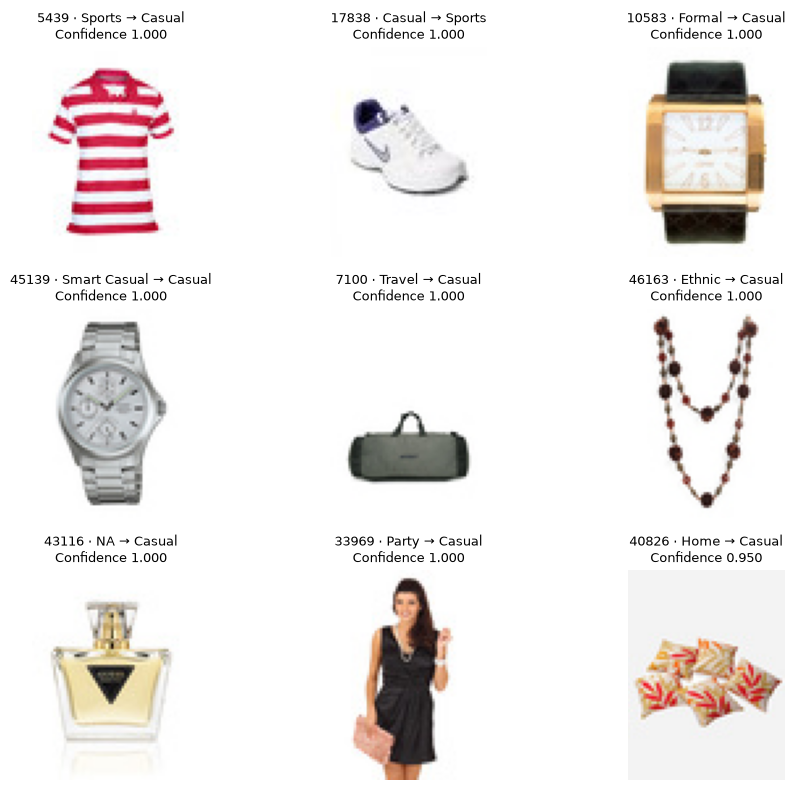

In [41]:
usage_errors = pd.concat([pd.read_csv(
    TASK3_EVIDENCE_ROOT/'baseline/usage'/run_id/'oof_predictions.csv',
    keep_default_na=False) for run_id in evidence_lock['stages']['usage1']['run_ids']])
usage_errors = usage_errors.loc[usage_errors.true_label.ne(usage_errors.predicted_label)]
usage_examples = usage_errors.sort_values(
    ['confidence', 'id'], ascending=[False, True]).drop_duplicates('true_label')
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
for ax in axes.flat:
    ax.axis('off')
for ax, row in zip(axes.flat, usage_examples.itertuples()):
    assert row.id in set(usage_development.id)
    with Image.open(REPO_DIR/row.path) as product:
        ax.imshow(product.convert('RGB'))
    ax.set_title(f'{row.id} · {row.true_label} → {row.predicted_label}\n'
                 f'Confidence {row.confidence:.3f}', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES/'usage_baseline_errors.png', dpi=150, bbox_inches='tight')
plt.show()


**The gallery supports an error audit.** A confident wrong occasion label shows that confidence
is not a guarantee of correctness. It does not prove a label is wrong or reveal which feature
the network used. Keep the supplied Usage labels, quantify the errors on all development rows,
then test the loss change on the same saved folds.


### Recompute the comparison from registered confusion counts


In [42]:
selected_stages = ['usage1', 'usage2', 'usage8']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E1 · Baseline,usage,"[0, 1, 2, 3, 4]",Original,32772,37.38,89.30
Usage E2 · Class weights,usage,"[0, 1, 2, 3, 4]",Original,32772,40.82,89.15
Usage E8 · Translation,usage,"[0, 1, 2, 3, 4]",Original,32772,41.94,88.85


**Usage E2 — accept class-balanced cross-entropy**

Usage E2 reached **0.4082 pooled macro-F1**, up **0.0344** from 0.3738, and reached
**0.4592 without Home**, up **0.0387** from 0.4205. Balanced
accuracy improved from 0.3571 to 0.3826 while ordinary accuracy moved only from 0.8930
to 0.8915. This is the intended trade: better treatment of supported minority classes with
almost no loss on the majority-dominated accuracy.

Probability loss also improved: pooled NLL fell from 0.4641 to 0.3428. E2 pooled ECE
is 0.0331; the saved audit lacks pooled E1 ECE, so no pooled ECE change is claimed here. Final fold macro-F1 values were 0.4086, 0.3818, 0.4362, 0.3999, and 0.3950.
Their standard deviation was 0.0203, higher than E1's 0.0121, so the gain is useful but
not equally strong in every fold.
The fold scores show improvement in four of five folds; only fold 4 is effectively flat. The
learning curves still show a large train-validation gap, but the mean validation macro-F1 remains well below the online training score. This supports keeping the new loss while testing one small
regularisation change next.

Casual F1 stayed flat and Sports F1 improved, so the gain did not come solely from sacrificing these common classes. The largest gains came
from NA and Travel, but Party, Smart Casual, and the one-row Home class remain unlearned.
Formal also fell by 0.0180. Weighting helped the classes that had some learnable evidence; it
could not invent evidence for tiny classes or remove semantic overlap. **E2 is accepted as the
new Usage parent, but not yet declared final.** The saved confusion counts confirm the remaining
failure: Home, Party, and Smart Casual still collapse mostly into Casual; Travel is detected only
three times and NA only ten times.

**The class plot identifies the source of the gain.** The gains need to occur in supported minority classes, not
only Casual. Look for NA and Travel improving from E1 to E2, and for the zero or near-zero
rare-class scores that survive both changes. The graph is evidence of where the benefit occurs,
not proof that the rare-class problem has been solved.


### Test one change at a time from the weighted parent

The table follows E1 → E2 → E3–E9 in experiment order. All use the same five teacher
development folds and nine labels. F1 and accuracy are recomputed from registered confusion
counts. The next table adds saved probability and corruption audits. Lower log loss (NLL)
means less probability error; lower calibration error (ECE) means closer agreement between
confidence and correctness. Corruption columns are mean fold changes from each model's own
clean F1, not pooled scores. Negative values mean damage. E1 has no pooled ECE in this audit.

Dashes mark values absent from this audit, not zeros. E1 corruption checks are discussed with the later fit audit.


In [43]:
compact_rows = []
for key in ['usage1', 'usage2', 'usage3', 'usage4', 'usage5',
            'usage6', 'usage7', 'usage8', 'usage9']:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
Usage E1 · Baseline,"0, 1, 2, 3, 4",Original,32772,37.38,89.30
Usage E2 · Class weights,"0, 1, 2, 3, 4",Original,32772,40.82,89.15
Usage E3 · Dropout 0.20,"0, 1, 2, 3, 4",Original,32772,41.61,89.17
Usage E4 · TinyResNet,"0, 1, 2, 3, 4",Original,32772,38.78,87.99
Usage E5 · Label smoothing,"0, 1, 2, 3, 4",Original,32772,40.49,89.27
Usage E6 · Focal loss,"0, 1, 2, 3, 4",Original,32772,40.94,88.82
Usage E7 · TinyConvNeXt,"0, 1, 2, 3, 4",Original,32772,34.51,85.22
Usage E8 · Translation,"0, 1, 2, 3, 4",Original,32772,41.94,88.85
Usage E9 · Exception balance,"0, 1, 2, 3, 4",Original,32772,39.55,83.70


#### Compare probability quality and photo sensitivity for every original recipe


In [44]:
usage_audit_dir = REPO_DIR/'reports/task3/usage_deep_investigation_20260905'
usage_model_audit = pd.read_csv(usage_audit_dir/'model_comparison.csv')
usage_original_audit = usage_model_audit.loc[
    usage_model_audit.scope.eq('all_available_folds')].set_index('model').reindex(
        [f'E{i}' for i in range(1, 10)])
assert usage_original_audit.support.eq(32772).all()
assert usage_original_audit.folds.eq('0,1,2,3,4').all()
np.testing.assert_allclose(usage_original_audit.macro_f1.to_numpy()*100,
                          [row[4] for row in compact_rows])
usage_all_robustness = pd.read_csv(usage_audit_dir/'robustness_means.csv').set_index('model')
usage_recipe_audit = usage_original_audit[['nll', 'ece_15']].copy()
usage_recipe_audit['ece_15'] *= 100
usage_recipe_audit['Shift change (points)'] = usage_all_robustness.translation_003*100
usage_recipe_audit['Dark change (points)'] = usage_all_robustness.brightness_085*100
display(usage_recipe_audit.rename(columns={'nll':'NLL', 'ece_15':'ECE (%)'}).round(4).fillna('—'))


,NLL,ECE (%),Shift change (points),Dark change (points)
model,,,,
E1,0.4641,—,—,—
E2,0.3428,3.309,-8.6912,-12.8868
E3,0.3334,2.6137,-8.5809,-12.5185
E4,0.5770,8.543,-13.5727,-10.6447
E5,0.3523,3.0508,-7.806,-9.512
E6,0.3286,3.184,-8.0914,-16.0895
E7,0.4473,1.2237,-11.9615,-28.5837
E8,0.3292,0.7938,-2.6929,-16.1896
E9,0.4415,1.2741,-8.187,-21.4324


**E2 → E3: reduce memorisation with classifier dropout [11].** F1 rises from 40.82% to
41.61%, and NLL falls from 0.3428 to 0.3334. The clean training–validation gap is still
51.51 points. Keep it as a close alternative, not a solved rare-class model. E3 is slightly
more accurate than E8 (89.17% versus 88.85%) and loses less under darkening (12.52 versus
16.19 points). E8 later offers much lower shift damage and ECE; its clean F1 lead over E3
is uncertain. Dropout is not carried into E8.

**E2 → E4: test residual connections [5].** The parameter-matched TinyResNet reaches
38.78% F1 and NLL 0.5770, both worse than E2. Its clean gap is 59.04 points, so this
architecture trial does not fix fitting the training set too closely. Drop this branch.

**E2 → E5: soften targets with label smoothing [19].** At epsilon 0.05, F1 is 40.49%
and NLL 0.3523, both worse than E2. But accuracy is 89.27% and darkening damage is only
9.51 points, better than E8. Keep this lighting trade-off visible; prefer E8 for observed
class coverage, shift tolerance and ECE, not because smoothing loses every comparison.

**E2 → E6: focus loss on hard cases with focal modulation [17].** F1 is 40.94%, only
0.12 points above E2. NLL 0.3286 is slightly better than E8's 0.3292: E8 is not the
best original recipe on this measure. E6 has poorer calibration (3.18% ECE), shift damage
of 8.09 points and darkening damage of 16.09 points. Its small F1 gain does not establish
that hard examples contain learnable rare-label evidence. Do not carry focal loss forward.

**E2 → E7: test the ConvNeXt block design [16].** F1 falls to 34.51% and accuracy to
85.22%. Its 33.64-point clean gap is smaller partly because training F1 is lower; validation
also worsens. Recorded mean training time is about 878 seconds versus E8's 502 seconds,
with darkening damage of 28.58 points. Drop this tested recipe. These are saved run costs,
not repeated hardware benchmarks or a verdict on every ConvNeXt configuration.

### E2 → E8: test translation, then inspect the retained path

With the loss fixed at E2, E8 adds only small shifts. The following curves, fold results and
class counts compare it with its parent and E1. They explain its 41.94% F1 alongside its
accuracy cost before the final original branch, E9, is assessed.


### Compare learning behaviour and fold stability

The curves below use the saved mean of five fold histories. They are epoch diagnostics;
the final comparison above pools confusion counts and is a different calculation. E8's online
training images are translated, while validation images are unchanged. Online training F1 is
therefore not a clean training-set evaluation. E2/E8 use weighted loss and E1 does not: compare
loss trends within a panel, not loss heights between recipes.


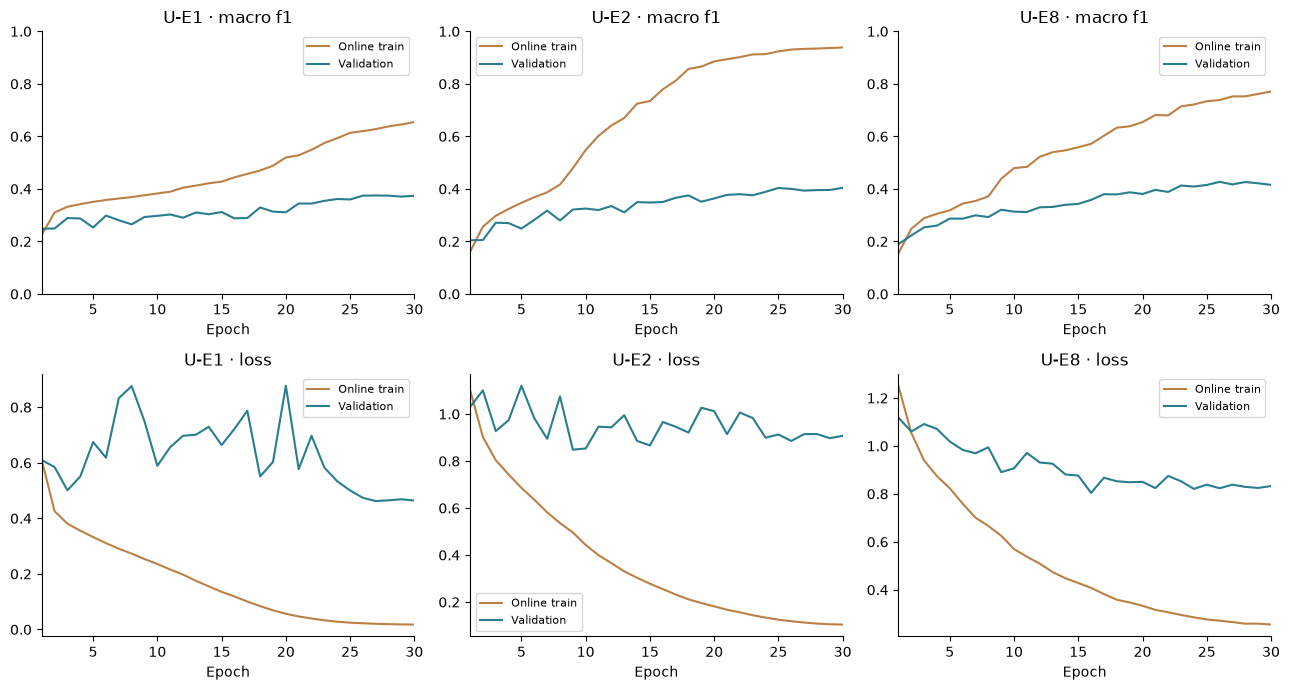

In [45]:
usage_curve_rows = historical_curves.loc[
    historical_curves.model_id.isin(['u-e1', 'u-e2', 'u-e8'])].copy()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, name in enumerate(['u-e1', 'u-e2', 'u-e8']):
    rows = usage_curve_rows.loc[usage_curve_rows.model_id.eq(name)].sort_values('epoch')
    for row, metric in enumerate(['macro_f1', 'loss']):
        ax = axes[row, column]
        ax.plot(rows.epoch, rows['train_'+metric], label='Online train', color='#bb8045')
        ax.plot(rows.epoch, rows['validation_'+metric], label='Validation', color='#287d8e')
        ax.set(title=name.upper()+' · '+metric.replace('_', ' '), xlabel='Epoch', xlim=(1, 30))
        if metric == 'macro_f1':
            ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES/'usage_development_curves.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation.** At epoch 30, E2's mean online training F1 is 93.85%, while mean validation
F1 is 40.43%. Weighting makes minority training examples easier to fit, but most of that fit
does not carry to held-out families. E8's online training F1 is lower, 77.07%, while validation
is 41.55%. This is consistent with a harder augmented training task; it is not, by itself,
proof that the clean generalisation gap closed. The clean-fit audit later in this notebook
keeps that distinction visible. None of these curves licenses choosing a new best epoch:
the reported E1/E2/E8 checkpoints all use the fixed 30-epoch rule.

### Check whether each saved fold benefits


In [46]:
usage_fold_scores = pd.DataFrame(fold_rows, columns=['Model', 'Target', 'Fold', 'F1 (%)'])
usage_fold_grid = usage_fold_scores.pivot(index='Fold', columns='Model', values='F1 (%)')
usage_fold_grid = usage_fold_grid.rename(columns={
    evidence_lock['stages'][key]['label']: name
    for key, name in [('usage1', 'E1'), ('usage2', 'E2'), ('usage8', 'E8')]})
usage_fold_grid = usage_fold_grid[['E1', 'E2', 'E8']]
usage_fold_grid['E2 − E1 (points)'] = usage_fold_grid.E2-usage_fold_grid.E1
usage_fold_grid['E8 − E2 (points)'] = usage_fold_grid.E8-usage_fold_grid.E2
display(usage_fold_grid.round(2))


Model,E1,E2,E8,E2 − E1 (points),E8 − E2 (points)
Fold,,,,,
0,37.27,40.86,44.40,3.59,3.54
1,36.09,38.18,38.68,2.09,0.50
2,37.57,43.62,44.20,6.05,0.58
3,36.54,39.99,41.37,3.46,1.38
4,39.60,39.50,39.12,-0.09,-0.39


**Decision from the folds.** Weighting improves four folds, with fold 4 nearly unchanged.
Translation also improves four folds, but its largest rise is on fold 0 and fold 4 regresses.
That supports checking the class composition rather than treating the pooled gain as uniform.
The folds share training data, so five positive-looking estimates are not five independent
replications. The family-resampling intervals, class losses and dark-image results below remain part of the decision.


### Compare class behaviour across the three retained steps


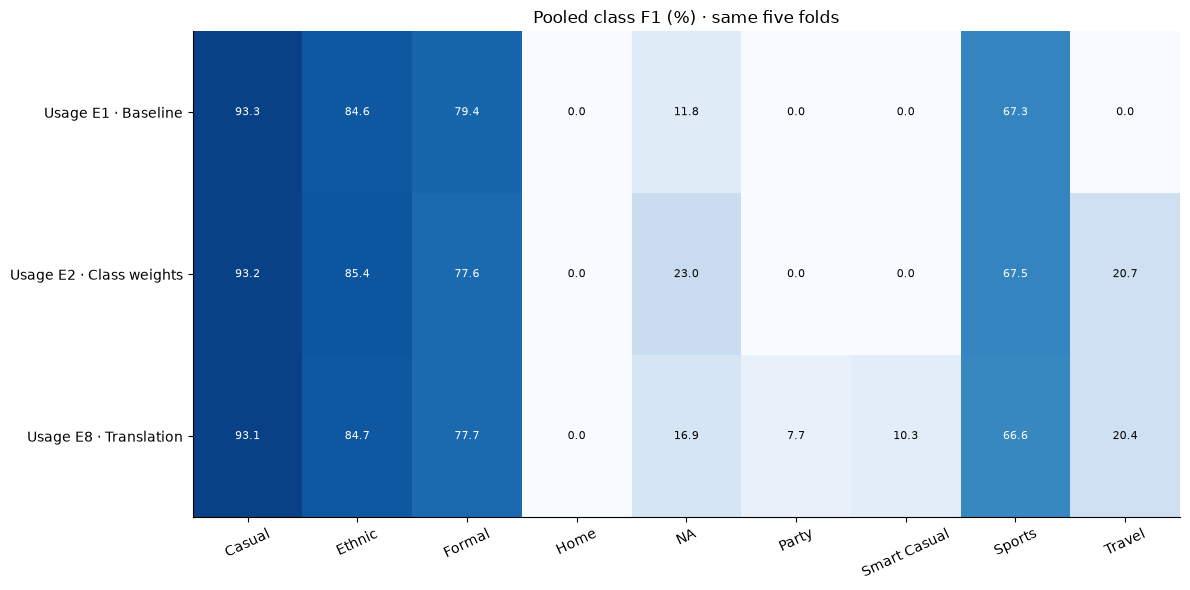

In [47]:
class_scores = pd.DataFrame(class_rows, columns=['Stage','Target','Class','F1 (%)'])
score_grid = class_scores.pivot(index='Stage', columns='Class', values='F1 (%)')
score_grid = score_grid.reindex([evidence_lock['stages'][key]['label'] for key in selected_stages])
fig, ax = plt.subplots(figsize=(12,6))
ax.imshow(score_grid, cmap='Blues', vmin=0, vmax=100, aspect='auto')
ax.set(xticks=range(len(score_grid.columns)), xticklabels=score_grid.columns,
       yticks=range(len(score_grid)), yticklabels=score_grid.index,
           title='Pooled class F1 (%) · same five folds')
ax.tick_params(axis='x', rotation=25)
for i,j in np.ndindex(score_grid.shape):
    value=score_grid.iloc[i,j]
    ax.text(j,i,f'{value:.1f}',ha='center',va='center',fontsize=8,
        color='white' if value>60 else 'black')
fig.tight_layout()
fig.savefig(FIGURES / "usage_all_experiments.png", dpi=150, bbox_inches="tight")
plt.show()

### Count rare detections, false alarms and the main error route

F1 alone can hide how a gain happened. The next table counts true detections and total predicted
labels on exactly the same development rows. Precision measures how often a predicted label is right;
recall measures how many real examples were found. Tiny classes need their counts beside both rates.


In [48]:
usage_count_rows, usage_matrices = [], {}
for key, name in [('usage1', 'E1'), ('usage2', 'E2'), ('usage8', 'E8')]:
    metrics = registry.loc[evidence_lock['stages'][key]['run_ids']].metrics_json.map(json.loads)
    cm = np.sum([metric['confusion_matrix'] for metric in metrics], axis=0)
    labels = [row['class_name'] for row in metrics.iloc[0]['per_class']]
    usage_matrices[name] = pd.DataFrame(cm, index=labels, columns=labels)
    for j, label in enumerate(labels):
        support, predicted, correct = int(cm[j].sum()), int(cm[:, j].sum()), int(cm[j, j])
        usage_count_rows.append([name, label, support, correct, predicted,
            100*correct/predicted if predicted else 0, 100*correct/support if support else 0])
usage_counts = pd.DataFrame(usage_count_rows, columns=[
    'Model', 'Class', 'Images', 'Correct', 'Predictions', 'Precision (%)', 'Recall (%)'])
rare_counts = usage_counts.loc[
    usage_counts.Class.isin(['Home','NA','Party','Smart Casual','Travel'])]
display(rare_counts.set_index(['Class', 'Model']).sort_index().round(2))
display(pd.DataFrame({name: matrix.loc[['Casual', 'Sports'], ['Casual', 'Sports']].stack()
    for name, matrix in usage_matrices.items()}).rename_axis(['True', 'Predicted']))


Images  Correct  Predictions  Precision (%)  Recall (%)
Class        Model                                                         
Home         E1          1        0            0           0.00        0.00
             E2          1        0            0           0.00        0.00
             E8          1        0            0           0.00        0.00
NA           E1         61        4            7          57.14        6.56
             E2         61       10           26          38.46       16.39
             E8         61       12           81          14.81       19.67
Party        E1         12        0            0           0.00        0.00
             E2         12        0            1           0.00        0.00
             E8         12        1           14           7.14        8.33
Smart Casual E1         47        0            0           0.00        0.00
             E2         47        0            5           0.00        0.00
             E8         47        6           69           8.70       12.77
Travel       E1         22        0            1           0.00        0.00
             E2         22        3            7          42.86       13.64
             E8         22        5           27          18.52       22.73

E1     E2     E8
True   Predicted                     
Casual Casual     23923  23861  23880
       Sports       712    722    574
Sports Casual      1255   1249   1363
       Sports      2070   2085   1966

**Weighting recovered some rare detections.** NA detections rise from four to ten and Travel from zero to three.
But Home, Party and Smart Casual remain at zero. E2 raises the cost of their errors without
creating enough useful examples to learn a transferable boundary. This supports retaining the
loss for supported minority classes, while rejecting the claim that weighting solves the tail.

**Translation extended coverage at a precision cost.** E8 finds 12 NA, one Party, six Smart Casual and five Travel items.
It also predicts NA 81 times, Party 14 times, Smart Casual 69 times and Travel 27 times.
Most of these rare predictions are wrong. NA recall rises, yet its precision falls enough for
F1 to decline. Sports detections fall from 2,085 to 1,966 as Sports→Casual errors rise from
1,249 to 1,363. Conversely, Casual→Sports errors fall from 722 to 574. Translation changes
the boundary in both directions; the equal-class gain is not a free improvement for every class.


**Usage E8 — translation fixes alignment sensitivity, not the class problem**

Translation improved four of five folds, pooled macro-F1 by 0.0112, macro-F1 without Home by 0.0126, NLL from 0.3428 to 0.3292, and ECE-15 from 0.0331 to 0.0079. The clean train-validation gap fell to 0.3750. Translation corruption improved by 0.0600 to only -0.0269, and wrong predictions at confidence at least 0.99 fell from 278 to 64. These tests show reduced sensitivity to shifts and fewer extremely confident errors; they do not identify the internal feature responsible.

The clean gain is not reliable across product families: the paired interval against E2 crosses zero, and the interval against E3 is -0.0239 to +0.0318. The main score misses 0.4262, and the no-Home score misses 0.4782. NA F1 fell from 0.2299 to 0.1690. The apparent rare-tail gain includes only one correct Party row and six correct Smart Casual rows. Fold 0 supplies most of the gain, fold 4 regresses, and dark-image robustness is 0.0330 worse than E2. The shift test improved, but the rare-class counts and uncertainty do not establish a stable clean-score gain or resolved label ambiguity.

**Decision at this stage.** E2 remains the accepted parent under the original improvement gates.
E8 does not pass those gates: its higher point score and shift tolerance come with uncertain
rare-class gains and worse dark-image performance. Keep E8 as a trade-off candidate for the
broader final judgement in Section 18; that choice must explain these costs rather than turn
the failed checks into passes.


**E2 → E9: rebalance ArticleType–Usage exceptions.** This separate branch reaches 39.55%
F1 and 83.70% accuracy, below E2. Its mean F1 over NA, Party, Smart Casual and Travel is
13.95%, slightly above E8's 13.84%, but the common-class cost is much larger. Its NLL
is 0.4415 and darkening damage is 21.43 points. Drop this balancing rule: a tiny gain on
four rare classes does not offset those losses. Group-robust work [18] motivates studying
weak groups, but this rule is not Group DRO.

**What survives the original branches?** E2 remains the accepted parent under the original
gates. E3 remains a close clean-score alternative; E5 has a lighting advantage and E6 a
small NLL advantage. E8 becomes the candidate for the next data branch because of its
observed coverage, shift tolerance and low ECE, with the failed gates still recorded.
This is a comparison of tested recipes, not proof that one model family is always best.

### Test the intended robustness gain and its cost

The all-recipe audit above shows the alternatives. This plot isolates E2 → E8: average each
saved fold's corrupted-minus-clean macro-F1. Negative values mean damage. This is a mean
fold change, not pooled F1 or a result on final-refit weights.


Model,E2,E8
corruption,,
brightness_085,-12.89,-16.19
brightness_115,-3.16,-4.22
grayscale,-1.45,-2.08
jpeg_75,-0.07,-0.19
translation_003,-8.69,-2.69


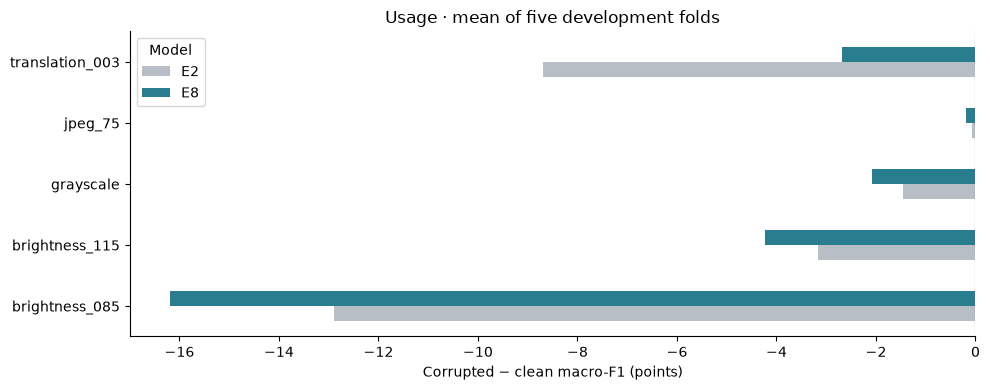

In [49]:
usage_robustness_parts = []
for key, name in [('usage2', 'E2'), ('usage8', 'E8')]:
    for relative in evidence_lock['stages'][key]['robustness_paths']:
        rows = pd.read_csv(REPO_DIR/relative, keep_default_na=False)
        rows['Model'] = name
        usage_robustness_parts.append(rows)
usage_robustness = pd.concat(usage_robustness_parts, ignore_index=True)
usage_robustness_means = usage_robustness.pivot_table(
    index='corruption', columns='Model', values='macro_f1_change', aggfunc='mean')*100
display(usage_robustness_means.round(2))
fig, ax = plt.subplots(figsize=(10, 4))
usage_robustness_means.plot.barh(ax=ax, color=['#b8bec6', '#287d8e'])
ax.axvline(0, color='#555555', linewidth=0.8)
ax.set(xlabel='Corrupted − clean macro-F1 (points)', ylabel='',
       title='Usage · mean of five development folds')
fig.tight_layout()
fig.savefig(FIGURES/'usage_robustness_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation and next step.** The translation loss shrinks by about six F1 points, but
darkening costs about 3.3 points more than E2. The intended position-tolerance gain is visible;
it does not establish general robustness. The worse dark-image result and uncertainty around the clean-score gain remain
limitations. Section 18 weighs the shift benefit and probability quality against these costs
when choosing E8 for reviewed catalogue suggestions.
Because class coverage remains weak, the next branch tests a different representation with
HOG-SVM, then tests additional rare-class data. Neither hypothesis follows from accuracy alone.


### Test a classical alternative on the same two folds

Full-RGB HOG plus a linear SVM tests whether fixed edge features are more useful than the CNN
for rare occasions. Calibration turns SVM scores into probabilities and is fitted only within the
saved training folds. Scarce positive examples can make that probability fit unstable. Compare
folds 0 and 4 only; a balanced probe is a different population.

Guo et al. [20] distinguish reliable probabilities from classification accuracy. That distinction
is relevant here, although their temperature-scaling method is not the SVM sigmoid calibration
used in this screen. The saved raw-margin and calibrated results below test the local effect.


In [50]:
selected_stages = ['usage204', 'hog_u']
comparison_rows, class_rows, fold_rows = [], [], []
for key in selected_stages:
    stage = evidence_lock['stages'][key]
    runs = registry.loc[stage['run_ids']]
    assert runs.status.eq('complete').all()
    assert sorted(runs.validation_fold.tolist()) == stage['folds']
    metrics = [json.loads(value) for value in runs.metrics_json]
    cm = np.sum([value['confusion_matrix'] for value in metrics], axis=0)
    assert int(cm.sum()) == int(runs.validation_product_count.sum())
    denom = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denom, out=np.zeros(len(cm)), where=denom>0)
    labels = [value['class_name'] for value in metrics[0]['per_class']]
    comparison_rows.append([stage['label'], stage['target'], stage['folds'],
                            stage['labels'], cm.sum(), 100*f1.mean(), 100*np.trace(cm)/cm.sum()])
    class_rows.extend([[stage['label'], stage['target'], label, 100*score]
                       for label, score in zip(labels, f1)])
    fold_rows.extend([[stage['label'], stage['target'], int(run.validation_fold),
                       100*metric['macro_f1']] for run, metric in zip(runs.itertuples(), metrics)])
comparison = pd.DataFrame(comparison_rows, columns=['Stage','Target','Folds','Labels',
    'Images','F1 (%)','Accuracy (%)'])
display(comparison.set_index('Stage').round(2))

,Target,Folds,Labels,Images,F1 (%),Accuracy (%)
Stage,,,,,,
Usage E2 · Class weights,usage,"[0, 4]",Original,13110,40.73,89.06
Usage U2 · HOG SVM,usage,"[0, 4]",Original,13110,36.29,86.57


**U2 hypothesis and failure.** Full-RGB HOG plus a linear SVM tests the promising fixed-feature probe on a full, naturally imbalanced population. The saved calibrated model scores 36.29% F1 against E2's matched 40.73%. The paired change is −4.44 points, with a family-bootstrap interval from −6.89 to −2.44 points; both admission routes fail. All solvers converged, so an unfinished optimiser is not the explanation.

Raw SVM margins would score 40.59%, but the saved calibrated probabilities score 36.29%. Two of eight Party calibration sigmoids have reversed slopes, each based on only two or three positives from one or two families. This directly shows that the fitted calibration step damaged the saved decisions. The raw-margin readout still predicts no Party or Smart Casual and is a diagnostic, not a replacement accepted model. Base SVM train/inner-validation gaps remain about 46–47 points; the smaller ensemble training gap masks different exposures to fitting and calibration.

The earlier balanced probe also used a different estimator and population. Its stronger score is not a contradiction and cannot isolate one cause. Scarce calibration examples, representation differences and fewer base-fitting folds all matter.

**Decision.** Reject the saved calibrated U2 model. Its raw-margin diagnostic is retained
below, alongside the other representation and weighting screens. None of these two-fold
scores should be ranked against five-fold totals.


In [51]:
compact_rows = []
for key in ['usage104', 'usage204', 'usage8', 'type_u', 'swin_u', 'u1', 'hog_u']:
    stage = dict(evidence_lock['stages'][key])
    runs = registry.loc[stage['run_ids']]
    if key == 'usage8':
        runs = runs.loc[runs.validation_fold.isin([0, 4])]
        stage['folds'] = [0, 4]
    metrics = runs.metrics_json.map(json.loads)
    cm = np.sum([row['confusion_matrix'] for row in metrics], axis=0)
    denominator = cm.sum(axis=0) + cm.sum(axis=1)
    f1 = np.divide(2*cm.diagonal(), denominator,
                   out=np.zeros(len(cm)), where=denominator > 0)
    compact_rows.append([stage['label'], ', '.join(map(str, stage['folds'])),
                         stage['labels'], int(cm.sum()),
                         100*f1.mean(), 100*np.trace(cm)/cm.sum()])
display(pd.DataFrame(compact_rows, columns=[
    'Experiment', 'Folds', 'Label basis', 'Images', 'Macro-F1 (%)', 'Accuracy (%)'
]).set_index('Experiment').round(2))


,Folds,Label basis,Images,Macro-F1 (%),Accuracy (%)
Experiment,,,,,
Usage E1 · Baseline,"0, 4",Original,13110,38.43,89.07
Usage E2 · Class weights,"0, 4",Original,13110,40.73,89.06
Usage E8 · Translation,"0, 4",Original,13110,42.43,88.93
Usage S1 · Type cascade,"0, 4",Original,13110,31.93,85.86
Usage · Scratch Micro-Swin,"0, 4",Original,13110,39.73,87.56
U1 · Component weights,"0, 4",Original,13110,41.38,88.99
Usage U2 · HOG SVM,"0, 4",Original,13110,36.29,86.57


### Follow the remaining two-fold branches

Use E2's matched **40.73% F1** as the reference for folds 0 and 4 (13,110 images).
The matching E8 score is **42.43%**, not its five-fold 41.94%. These screens explore
different explanations for E2's remaining errors; they do not form a cumulative recipe.

**S1, type cascade:** use product type to help infer occasion. F1 is 31.93%, with NLL
0.4776. Its small 6.21-point clean gap accompanies low training and validation scores;
it is not evidence of a better model. Reject this tested cascade.

**S2, scratch Micro-Swin:** test a different visual representation. F1 is 39.73%, NLL
0.7296 and ECE 10.19%, all worse than matched E2. Shift damage averages 15.15 points
on its two folds. Reject this transformer screen under its saved budget.

**U1, component weights:** change the weighting unit to reduce the influence of related
examples. F1 rises to 41.38%, but NLL 0.3474 and ECE 3.58% worsen versus matched E2.
It does not establish a reliable rare-class replacement. Retain the simpler weighted parent.

**U2, fixed HOG features:** the preceding calibration audit explains why the promising
balanced probe did not transfer to the full population. Saved calibrated F1 is 36.29%;
raw margins give 40.59%. Neither beats matched E2. The raw-margin paired interval crosses
zero, and Party and Smart Casual still have no correct predictions. Reject the saved model;
do not relabel its raw-margin diagnostic as an accepted replacement.

**U3, two-stage rebalancing:** first learn features with ordinary loss (Stage A, 30 epochs),
then freeze those features and retrain the head with weighted loss (Stage B, 10 epochs).
This tests whether separating feature learning from rebalancing helps more than E2's
one-stage weighted loss. The next table uses the saved U3 review, including its registry limit.


In [52]:
usage_u3_scores = pd.read_csv(REPO_DIR/'reports/task3/usage_u3_review_20260905/summary.csv')
usage_u3_scores[['macro_f1', 'accuracy', 'ece_15']] *= 100
display(usage_u3_scores.rename(columns={'model':'Model', 'macro_f1':'F1 (%)',
    'accuracy':'Accuracy (%)', 'nll':'NLL', 'brier':'Brier', 'ece_15':'ECE (%)'}
).set_index('Model').round(4))


,F1 (%),NLL,Brier,ECE (%),Accuracy (%)
Model,,,,,
E2,40.7319,0.3424,0.1723,3.2938,89.0618
U3 Stage A,38.4302,0.4654,0.1820,6.8872,89.0694
U3 Stage B,40.3390,0.4717,0.1845,4.5725,88.6804


**U3 result and decision.** Stage B raises F1 from 38.43% to 40.34%, still below matched
E2's 40.73%. Its paired family interval versus E2 is −3.09 to +2.38 F1 points; NLL worsens
37.77% and Brier probability error worsens 7.10%. Stage B finds no Party and only one
Smart Casual item. Travel loses precision, and the brightening guard also fails. Freezing
features did not solve transfer. Stop this branch at the fixed B10 checkpoint; the later
rise in validation loss does not justify choosing an earlier epoch after seeing the results.

The saved U3 review (`reports/task3/usage_u3_review_20260905/REVIEW.md`) verifies both
artifact bundles but records fold 4 as still running in its registry snapshot. These are
audited artifact scores, not proof of two fully registered completions. The earlier failed
attempt is excluded. No training or registry repair is performed by this report.

### Check whether changing predictions helps before adding data

The saved audit also tested equal probability averages and class-prior adjustments. These
reuse development predictions after model fitting; they are diagnostics, not extra training
runs. Display every saved combination, keeping the five-fold and two-fold scopes separate.


In [53]:
for filename in ['fixed_blend_diagnostics.csv', 'fixed_prior_diagnostics.csv']:
    diagnostic = pd.read_csv(usage_audit_dir/filename)
    diagnostic['scope'] = diagnostic.support.map({32772:'Five folds', 13110:'Folds 0 and 4'})
    diagnostic[['macro_f1', 'accuracy', 'ece_15']] *= 100
    display(diagnostic[['model', 'scope', 'support', 'macro_f1', 'accuracy', 'nll', 'ece_15']]
        .rename(columns={'model':'Diagnostic', 'scope':'Scope', 'support':'Images',
            'macro_f1':'F1 (%)', 'accuracy':'Accuracy (%)', 'nll':'NLL', 'ece_15':'ECE (%)'})
        .set_index(['Diagnostic', 'Scope']).round(4))


,,Images,F1 (%),Accuracy (%),NLL,ECE (%)
Diagnostic,Scope,,,,,
E2+E3,Five folds,32772,41.8203,89.7351,0.3155,2.0327
E2+E8,Five folds,32772,41.2454,89.6497,0.3092,1.0084
E3+E8,Five folds,32772,41.8999,89.6161,0.3095,0.9103
E2+E3+E8,Five folds,32772,42.3147,89.9121,0.3032,1.1632
E2+U2,Folds 0 and 4,13110,41.4585,89.8474,0.3136,3.6291
E2+E9,Five folds,32772,41.8062,88.7160,0.3374,2.5291


Images   F1 (%)  Accuracy (%)     NLL  ECE (%)
Diagnostic    Scope                                                        
E2 prior^0.25 Five folds      32772  41.4989       88.3101  0.3547   2.5733
              Folds 0 and 4   13110  42.5704       88.1159  0.3572   2.5024
E3 prior^0.25 Five folds      32772  40.7900       88.3986  0.3475   1.8385
              Folds 0 and 4   13110  41.2199       88.2761  0.3493   2.0632
E8 prior^0.25 Five folds      32772  39.5893       86.5403  0.3889   2.1310
              Folds 0 and 4   13110  40.2607       86.5065  0.3865   2.2286

**The three-model average has a real development advantage.** Equal E2+E3+E8 probabilities
reach 42.31% F1, 89.91% accuracy and NLL 0.3032 on five folds, exceeding E8 on all three.
Its paired interval versus E2 is +0.30 to +2.89 F1 points; this is not an interval versus E8.
All other saved two-model averages have lower point F1 than their matched E8 reference.
The three-model average still detects no Party and only one Smart Casual item. It has no
matched corruption audit and requires three model passes. It was not advanced to final
refits. Retain it as a promising unconfirmed alternative: choosing single E8 gives up its
observed clean-score advantage for the tested shift behaviour and a one-model package.
This is a scope and evidence trade-off, not proof that the average failed numerically.

**Class-prior adjustment does not improve E8.** At the saved exponent 0.25, five-fold F1
is 41.50% for E2, 40.79% for E3 and 39.59% for E8. NLL worsens for all three versus
their unadjusted probabilities. Reject this adjustment for the final recipe; do not tune a
new exponent from these results.

**Next hypothesis: improve the evidence available for rare classes.** The early balanced
feature probes motivated learner changes but used a different population; they are not
matched final candidates. The full-population branches above leave rare occasions weak.
We therefore follow E8 into the saved added-data trials and judge transfer on teacher rows.


### Audit the admitted rare-Usage additions


Version,teacher_plus_rare_usage_20260906,teacher_plus_rare_usage_v2_20260906
Usage,,
Home,16,136
Party,97,224
Smart Casual,6,162
Travel,1,165


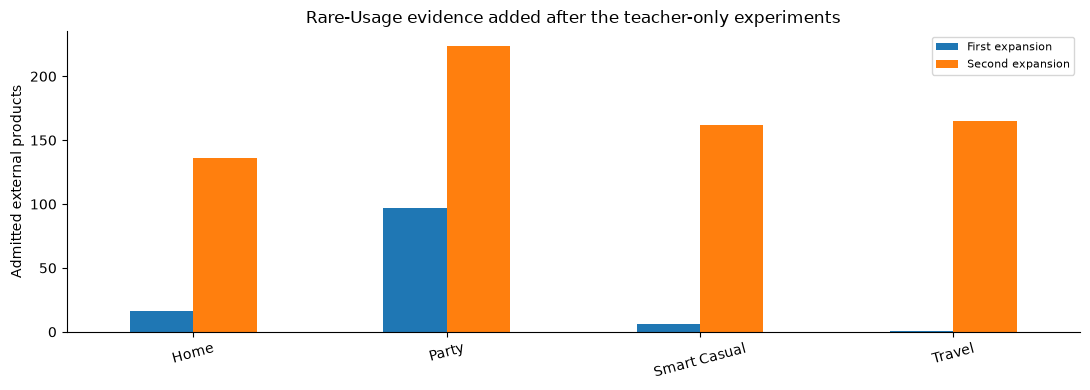

In [54]:
expanded_paths = ['data/processed/teacher_plus_rare_usage_20260906/splits.csv',
                  'data/processed/teacher_plus_rare_usage_v2_20260906/splits.csv']
intake_rows=[]
teacher_ids=set(splits.id.astype(str))
for path in expanded_paths:
    expanded=pd.read_csv(REPO_DIR/path,keep_default_na=False,low_memory=False)
    external=expanded.loc[~expanded.id.astype(str).isin(teacher_ids)]
    for label,count in external.usage.value_counts().items():
        intake_rows.append([Path(path).parent.name,label,count])
intake=pd.DataFrame(intake_rows,columns=['Version','Usage','Added products'])
display(intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).astype(int))
fig,ax=plt.subplots(figsize=(11,4))
intake.pivot(index='Usage',columns='Version',values='Added products').fillna(0).plot.bar(
    ax=ax,rot=15)
ax.set(ylabel='Admitted external products',xlabel='',
    title='Rare-Usage evidence added after the teacher-only experiments')
ax.legend(['First expansion','Second expansion'],fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "usage_expansion_intake.png", dpi=150, bbox_inches="tight")
plt.show()

**The remaining failures motivated additional data.** More independent families can give a small class more examples to learn from. Yet outside retail photos may have different products, backgrounds or label meanings. The fair test is performance on the same teacher rows. A better score on a mixture of teacher and outside images does not establish that benefit. Literal `NA` remains a class; the one blank target remains excluded.


## 17. Usage: the effect of adding rare-class images

Weighting, translation and alternative learners had left the rare occasions poorly recognised.
The next intervention therefore changed the available examples: additional rare-class families
were introduced while retaining the teacher folds and E8 recipe. Success was judged on the
same teacher images, because a gain on the new retail source alone would not solve the
original task.

The tables read pinned, completed evidence. Original model scores come from registered fold
confusion counts. Expanded runs use their saved teacher-only prediction audits because their
registry totals also include outside images.


### Verify the saved evidence and compare the same five teacher folds


In [55]:
usage_lock = json.loads((USAGE_HISTORY/'evidence_lock.json').read_text())
usage_files = usage_lock['sources']
verify_development_files(REPO_DIR, usage_lock['files'])
usage120 = json.loads((REPO_DIR/usage_files['expanded120_confusions']).read_text())
usage687 = json.loads((REPO_DIR/usage_files['expanded687_summary']).read_text())
usage_dev_rows = []
for label, key in [('E1', 'usage1'), ('E8', 'usage8')]:
    rows = registry.loc[evidence_lock['stages'][key]['run_ids']]
    assert rows.status.eq('complete').all() and sorted(rows.validation_fold) == list(range(5))
    matrices = [json.loads(value)['confusion_matrix'] for value in rows.metrics_json]
    matrix = np.sum(matrices, axis=0)
    denominator = matrix.sum(axis=0) + matrix.sum(axis=1)
    f1 = np.divide(2*matrix.diagonal(), denominator,
                   out=np.zeros(9), where=denominator>0).mean()
    usage_dev_rows.append([label, int(matrix.sum()), np.trace(matrix)/matrix.sum(), f1])
for label, result in [('E8 +120', usage120['teacher']),
                      ('E8 +687', usage687['sources']['teacher']['metrics'])]:
    matrix = np.asarray(result['confusion_matrix'])
    usage_dev_rows.append([label, int(matrix.sum()), result['accuracy'], result['macro_f1']])
usage_development_scores = pd.DataFrame(usage_dev_rows,
    columns=['Model','Images','Accuracy','Macro-F1']).set_index('Model')
assert usage_development_scores.Images.eq(32772).all()
display(usage_development_scores.round(6))

,Images,Accuracy,Macro-F1
Model,,,
E1,32772,0.892988,0.373756
E8,32772,0.888533,0.419393
E8 +120,32772,0.887495,0.408634
E8 +687,32772,0.895093,0.409277


**Result.** E1 scores 89.30% accuracy and 0.373756 macro-F1. E8 scores 88.85% and 0.419393. Adding 120 images lowers teacher macro-F1 to 0.408634; adding 687 gives 0.409277. The larger set raises teacher accuracy to 89.51%, so E1 is not the accuracy winner of this expanded development comparison.

The 687-image change against original E8 has a family-resampling 95% interval of −0.0348 to +0.0144 F1. It includes zero. There is no demonstrated gain; the observed decrease is not proof that adding data always hurts. One seed and repeated use of these folds limit the claim.


### Locate the effect of extra data on teacher classes

Keep the evaluation population fixed: original teacher development images, predicted out of fold.
The table below recomputes each class F1 from teacher-only confusion matrices. Extra-source
validation rows are excluded from these scores. This avoids mistaking success on retailer photos
for success on the original task.


In [56]:
expanded_class_scores = {}
for name, matrix in [('E8', usage_matrices['E8'].to_numpy()),
    ('E8 +120', np.asarray(usage120['teacher']['confusion_matrix'])),
    ('E8 +687', np.asarray(usage687['sources']['teacher']['metrics']['confusion_matrix']))]:
    denominator = matrix.sum(axis=0)+matrix.sum(axis=1)
    expanded_class_scores[name] = np.divide(2*matrix.diagonal(), denominator,
        out=np.zeros(len(matrix)), where=denominator > 0)*100
expanded_class_view = pd.DataFrame(expanded_class_scores, index=usage_matrices['E8'].index)
expanded_class_view['+120 change (points)'] = expanded_class_view['E8 +120']-expanded_class_view.E8
expanded_class_view['+687 change (points)'] = expanded_class_view['E8 +687']-expanded_class_view.E8
display(expanded_class_view.round(2))


,E8,E8 +120,E8 +687,+120 change (points),+687 change (points)
Casual,93.05,92.97,93.39,-0.08,0.34
Ethnic,84.74,85.02,86.24,0.28,1.50
Formal,77.71,76.98,79.91,-0.73,2.21
Home,0.00,0.00,0.00,0.00,0.00
NA,16.90,22.22,23.62,5.32,6.72
Party,7.69,0.00,0.00,-7.69,-7.69
Smart Casual,10.34,3.85,0.00,-6.50,-10.34
Sports,66.61,66.33,69.05,-0.28,2.44
Travel,20.41,20.41,16.13,0.00,-4.28


**The class breakdown explains the aggregate result.** With 687 additions, NA gains 6.72 F1 points, Sports
gains 2.44 and Formal gains 2.21. But Party loses 7.69, Smart Casual loses 10.34 and Travel
loses 4.28. Party and Smart Casual reach zero despite being targets of the collection effort.
The 120-image trial already shows that tension: NA improves while Party and Smart Casual fall.
The common-class gains help accuracy, but they do not establish the intended rare-class benefit.

**The comparison isolates the added-data package.** The +120 and +687 runs retain the E8 recipe, so they
test added training evidence more directly than changing both learner and data. More images
still change source mix and family support. The aggregate teacher F1 fails to improve, so this
branch has not met its purpose even if accuracy increases. The following source comparison
tests a possible reason: whether the rare labels were learned mainly from the new photo source.
It can expose a transfer failure, but cannot isolate background, product type or label meaning
as its cause without an additional controlled test.


### Check whether learning transfers between sources


cohort,Newest 567 images,Teacher
class_name,,
Home,116 / 120,0 / 1
Party,125 / 127,0 / 12
Smart Casual,147 / 156,0 / 47
Travel,137 / 164,5 / 22


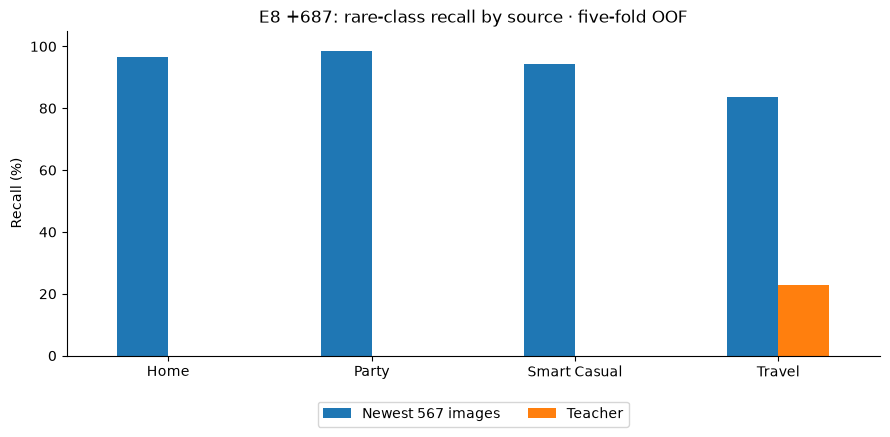

In [57]:
source_scores = pd.read_csv(REPO_DIR/usage_files['source_classes'], keep_default_na=False)
rare_names = ['Home','Party','Smart Casual','Travel']
source_view = source_scores.loc[source_scores.class_name.isin(rare_names) &
    source_scores.cohort.isin(['teacher','new_added'])].copy()
source_view['Correct / images'] = (source_view.correct.astype(str) +
                                  ' / ' + source_view.support.astype(str))
source_labels = {'teacher':'Teacher','new_added':'Newest 567 images'}
display(source_view.pivot(index='class_name', columns='cohort',
    values='Correct / images').reindex(rare_names).rename(columns=source_labels))
fig, ax = plt.subplots(figsize=(9,4.5))
source_view.pivot(index='class_name', columns='cohort', values='recall').reindex(
    rare_names).rename(columns=source_labels).mul(100).plot.bar(ax=ax, rot=0)
ax.set(xlabel='', ylabel='Recall (%)', ylim=(0,105),
       title='E8 +687: rare-class recall by source · five-fold OOF')
ax.legend(title='', loc='upper center', bbox_to_anchor=(.5,-.12), ncol=2)
fig.tight_layout()
fig.savefig(FIGURES/'usage_source_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** The 687-image model detects 125/127 new-source Party and 147/156 new-source Smart Casual images. On the teacher rows, it detects 0/12 Party and 0/47 Smart Casual. It learns the outside examples, but that success does not carry to these teacher classes. The earlier 120-image model also missed all teacher Party cases.

The mixed-source F1 of 0.7567 measures a changed class and source mix. It cannot replace the teacher-only score of 0.4093. Coverage was uneven: the teacher Smart Casual class contains 18 watches, while the 162 added Smart Casual images contain none. Product types also overlap: a dress can be Casual or Party. These are useful clues, not proof of wrong labels or a faulty architecture.

The next experiments followed these two observations separately in intent: reduce the
expanded model's exact fit, then improve the types of outside products represented. Their
teacher-only results, rather than the new-source scores, determined whether either helped.


## 18. Usage: follow-up failures and the fixed refits

The expansion revealed a gap between strong recognition on the added source and continued
failure on teacher rare classes. Two follow-ups examined that gap. The first combined MixUp
and SAM to reduce exact fitting; the second replaced 130 outside images to address coverage
differences. Their results determined whether the expanded-data path should continue before
the final teacher-only refits were completed.


### Separate the two follow-up hypotheses

**V2 MixUp + SAM:** the expanded model fits outside examples much better than teacher rare
examples. MixUp [13] changes the training examples and SAM [14] changes the weight update.
Together they test whether a less exact fit improves transfer; success in Gender does not
establish success for Usage's different labels and added image sources. Both methods change together, so this is a combined-recipe test. A smaller training gap
counts as progress only if teacher validation holds up; underfitting can also shrink a gap.

**V3 replacements:** after that failure, 130 outside images are replaced with reviewed products
intended to better match the missing teacher categories. Class totals and all teacher rows stay
fixed, along with retained outside rows and folds. This tests the replacement package, not simply
the number of images. Score it against V2 on the same folds 0 and 4. The table and paired error
counts below determine whether the more suitable examples actually transfer.


In [58]:
usage_mix = json.loads((REPO_DIR/usage_files['mixup_summary']).read_text())
usage_v3 = json.loads((REPO_DIR/usage_files['v3_summary']).read_text())
assert usage_mix['folds'] == usage_v3['folds'] == [0,4]
assert usage_mix['teacher_rows'] == usage_v3['teacher_rows'] == 13110
screen = pd.DataFrame([
    ['E8 +687', usage_mix['baseline_teacher_f1']],
    ['v2 MixUp + SAM', usage_mix['candidate_teacher_f1']],
    ['v3 MixUp + SAM', usage_v3['candidate_teacher_f1']]],
    columns=['Model','Teacher macro-F1'])
display(screen.set_index('Model').round(6))
fit_rows = pd.DataFrame(usage_mix['mean_teacher_fit']).T.rename(
    index={'mixup_sam':'v2 MixUp + SAM','v2_e8':'E8 +687'})
fit_rows.loc['v3 MixUp + SAM'] = pd.Series(usage_v3['mean_teacher_fit']['v3'])
fit_rows = fit_rows.reindex(screen.Model)
fit_labels = {'teacher_train_f1':'Clean train F1',
              'teacher_validation_f1':'Validation F1','teacher_gap':'Gap'}
display(fit_rows.rename(columns=fit_labels).round(4))

,Teacher macro-F1
Model,
E8 +687,0.400984
v2 MixUp + SAM,0.389790
v3 MixUp + SAM,0.377773


,Gap,Clean train F1,Validation F1
Model,,,
E8 +687,0.4173,0.8182,0.4010
v2 MixUp + SAM,0.2157,0.6049,0.3892
v3 MixUp + SAM,0.2158,0.5938,0.3780


**Result.** On the same 13,110 teacher images, E8 +687 scores 0.400984, v2 MixUp + SAM scores 0.389790, and v3 scores 0.377773. These are two-fold scores; they must not be ranked against the five-fold table in Section 17.

The v2 gap falls from 0.4173 to 0.2157 mainly because training F1 falls. Validation F1 falls too. V3 leaves the gap almost unchanged at 0.2158. It fixes 208 teacher errors but adds 242. Its paired family interval against v2 is −0.0263 to −0.0012 F1, supporting a decrease for these saved predictions. It does not measure variation across training seeds.

**Failure and decision.** Both trials miss all six teacher Party and all 18 Smart Casual cases on these folds. V3 also loses the one Travel case v2 detected. It gets only 27/76 replacement validation photos right despite fitting many replacement training photos. More suitable product types alone were insufficient under this recipe. Keep both completed trials as evidence; neither is the final model. MixUp and SAM changed together, so their separate effects are unknown.


**The accumulated evidence ended this branch.** The new-source recall gains did not transfer to teacher Party and
Smart Casual. Regularisation reduced training fit without improving teacher validation; more suitable
replacement product types were also insufficient under this recipe.

E1 still has a large training–validation difference. Its development corruption checks lose a mean
6.68 F1 points under darkening and 6.42 under translation. Expanded models also retain large clean
gaps. Their corruption audits include outside images, so they cannot prove a matched teacher-only
robustness gain. A smaller gap alone is not a selection reason. The v2/v3 fit gaps are displayed above. The historical original-fit table below labels
online training scores separately from clean checkpoint scores; they are not interchangeable.


In [59]:
historical_fit = pd.read_csv(
    REPO_DIR/'reports/task3/usage_deep_investigation_20260905/fit_summary.csv',
    keep_default_na=False)
fit_view = historical_fit[['model', 'train_source', 'macro_f1', 'train_macro_f1', 'gap']].copy()
fit_view[['macro_f1', 'train_macro_f1', 'gap']] *= 100
display(fit_view.rename(columns={'model':'Model', 'train_source':'Training score basis',
    'macro_f1':'Validation F1 (%)', 'train_macro_f1':'Training F1 (%)',
    'gap':'Gap (points)'}).set_index('Model').round(2))


,Training score basis,Validation F1 (%),Training F1 (%),Gap (points)
Model,,,,
E1,last online epoch,37.41,65.46,28.05
E2,last online epoch,40.43,93.85,53.42
E3,clean final checkpoint,41.40,92.91,51.51
E4,clean final checkpoint,38.58,97.62,59.04
E5,clean final checkpoint,40.33,94.20,53.87
E6,clean final checkpoint,40.56,93.73,53.17
E7,clean final checkpoint,34.74,68.38,33.64
E8,clean final checkpoint,41.55,79.05,37.50
E9,clean final checkpoint,39.47,77.75,38.28


### Compare every Usage model visually

The chart brings the original recipes, alternative learners, added-data trials and all saved
probability diagnostics together. Scores use teacher rows only, with separate panels for five
folds and folds 0/4. Green marks E8; orange marks prediction diagnostics. U3's artifact audit
remains labelled because its fold-4 registry receipt is incomplete. Refits and sampled EDA
probes have no comparable OOF score and remain in the Section 2 inventory.

Read the trade-off before choosing: the three-model average has a higher clean score, while
single E8 has matched shift evidence and needs one model pass. The sections above define each
label and record class failures, confidence and lighting costs; point rank alone is insufficient.

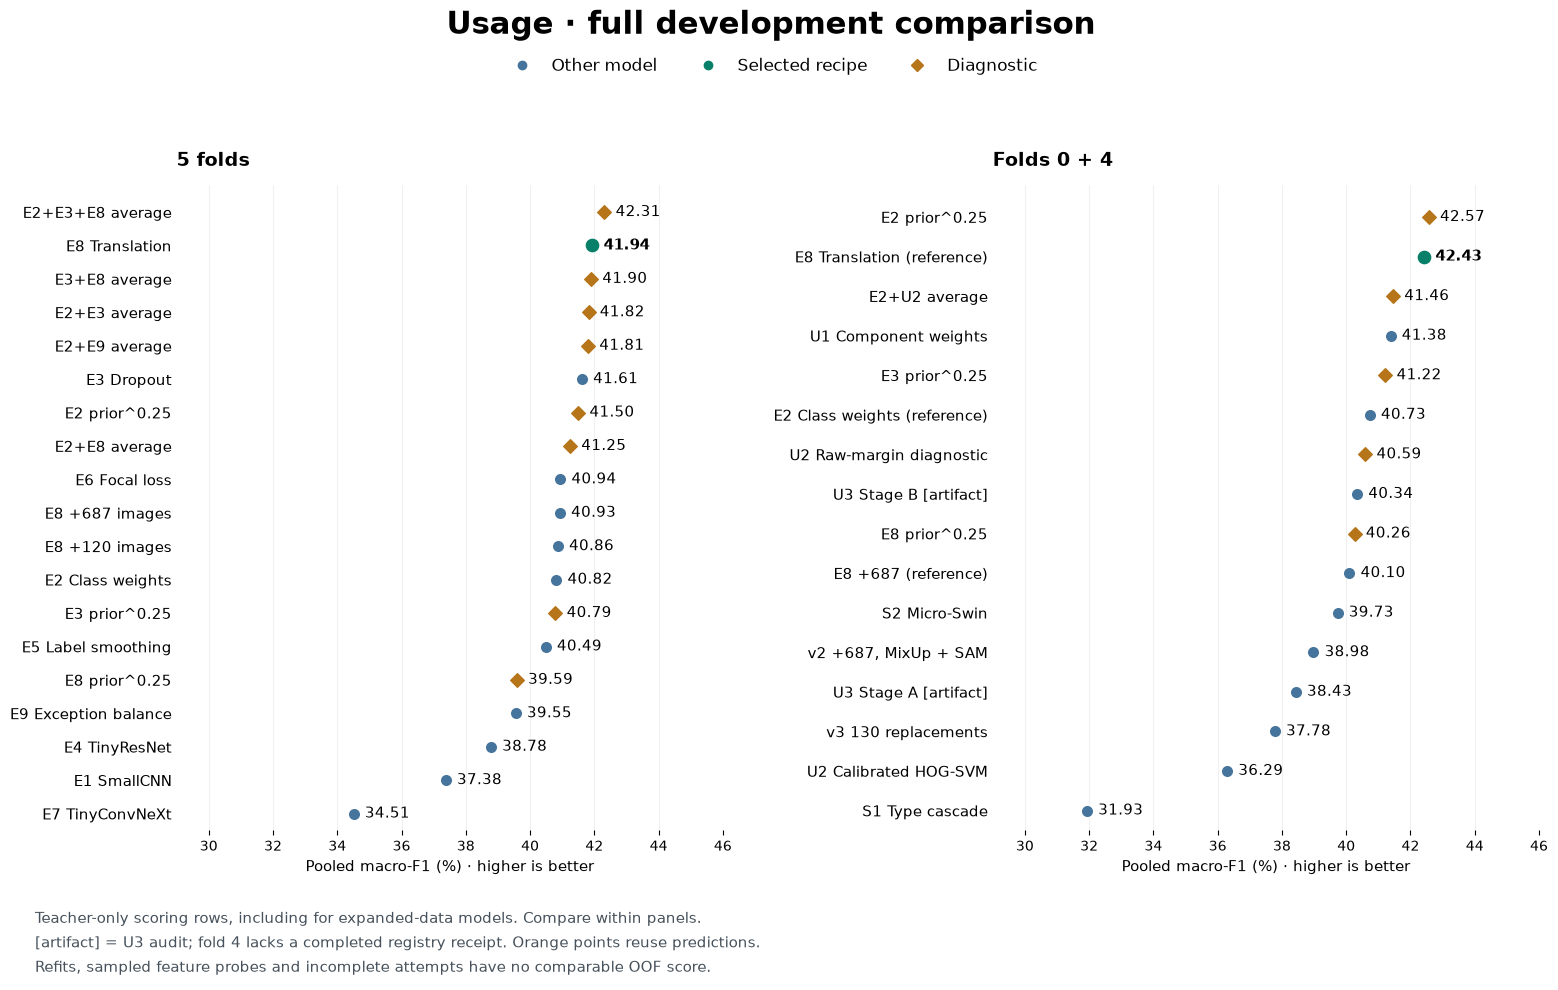

In [60]:
from fashion.task3_comparison_figures import plot_model_comparison

fig = plot_model_comparison(REPO_DIR, "usage", FIGURES.parent)
plt.show()

### Choose the E8 recipe for the full-development refit

**Selected Usage recipe: teacher-only E8 with a fixed 30-epoch schedule.** We choose the E8 recipe
for reviewed catalogue suggestions because it combines broader observed class coverage,
better tolerance of small shifts and better-calibrated confidence. This judgement accepts
lower overall accuracy and worse dark-image behaviour. It does not claim that E8 wins every
test or that its small lead over nearby alternatives is statistically established.

**This choice follows the full development path.** E1 established the rare-class failure;
E2's weighting became the parent. The E3–E9 branches tested one change each. S1/S2,
U1/U2/U3 and the saved probability diagnostics tested other explanations before E8's
added-data branch. The +120 and +687 trials, then v2/v3 MixUp + SAM, failed to establish
the intended teacher rare-class transfer. Each result and decision is recorded above.

E3 remains close in clean F1 and better in accuracy and dark-image behaviour. E5 has less
darkening damage, and E6 slightly lower NLL. E4/E7 and S1/S2 did not justify their architecture
changes; E9 traded too much common-class performance for rare-class emphasis. U1's small
gain came with worse probability scores; U2 and U3 did not beat their matched parent.
The equal E2+E3+E8 average is the strongest clean-score diagnostic, at 42.31% F1. It lacks
matched corruption evidence and needs three models. We retain single E8's
measured shift benefit and simpler inference package, while acknowledging that unconfirmed
alternative. E8 is therefore a selected compromise, not the winner of every saved comparison.

**Class coverage is worth a modest accuracy cost.** On the same five teacher development
folds, E8 reaches **41.94% macro-F1 and 88.85% accuracy**, compared with E1's **37.38% and
89.30%**. We accept the 0.45-point accuracy loss for the observed 4.56-point macro-F1 gain
because all nine Usage labels matter. E1 misses every Party, Smart Casual and Travel example;
E8 detects one, six and five respectively. Those counts show added coverage, not reliable
rare-class tagging: most of E8's predictions for these rare labels are still wrong.

**The step from E2 to E8 buys position tolerance and probability quality.** E2 already
provides class weighting; E8 adds translation. The mean five-fold macro-F1 loss under small
shifts falls from **8.69 to 2.69 points**. Development log loss falls from **0.3428 to 0.3292**,
and 15-bin calibration error falls from **3.31% to 0.79%**. Errors made with confidence of
at least 99% fall from **278 to 64**. These measured benefits support choosing E8 when
catalogue image alignment varies and people review its suggestions. They do not establish
reliable confidence for each rare label.

**The lighting cost and bootstrap uncertainty remain part of the choice.** Darkening causes
a **16.19-point** mean fold macro-F1 loss for E8 versus **12.89 points** for E2. E8 also loses
NA F1 and some Sports detections. Whole-family bootstrap resampling keeps related products
together: the paired clean-score interval against E2 crosses zero, and the 95% interval
against E3 is **−2.39 to +3.18 F1 points**. Thus the clean lead over E2/E3 is uncertain. These
intervals describe the saved predictions; they do not cover training-seed variation or
remove the effect of trying many recipes. E8's original improvement gates remain failed.
Our final choice is an explicit judgement across these benefits and costs, rather than a
claim that the original gates selected E8. E2 remains the simpler, stronger dark-image
alternative, and E1 remains the original accuracy alternative.

**Keep the teacher-only recipe.** The added-data trials did not establish a teacher macro-F1
gain, and the later matched MixUp/SAM and replacement screens did not resolve rare-class
failure. These results support retaining the compact E8 recipe without the added source
mix or training changes. They do not prove that every expanded-data approach would fail.

**Fix the recipe, then refit.** Use the teacher-only SmallCNN with class weighting
and translation. Keep the 30-epoch schedule fixed. Do not add MixUp, SAM, external
images or probability adjustments. The next section records the completed refit;
its training loss is not evidence for choosing this recipe.


### Refit the fixed Usage recipes on all development images

A refit trains a fresh model using all eligible development rows after the recipe is set.
Both E1 and E8 completed **30 fixed epochs on 32,772 teacher images**. One blank Usage target
is masked; literal `NA` remains a class. They use the same canonical split, class order,
391,209-parameter SmallCNN and seed 2753. No external additions enter these refits.

E1 uses ordinary cross-entropy and no augmentation. E8 uses effective-number weighted
cross-entropy and a translation of up to two pixels with probability 0.5. Both refit their
normalization on full-development content pixels, excluding padding. E8 also recalculates
its class weights from those same rows. Neither run uses validation or early stopping.

#### Completed registered runs

The table comes from the two completed `results/runs.csv` records, preserved in a checked
snapshot. It records training completion and cost, not performance on unseen images.


In [61]:
from fashion.task3_final import verify_usage_final

usage_final_manifest = verify_usage_final(REPO_DIR, saved_training_source=True)
refit_runs = pd.read_csv(USAGE_FINAL/'refit_runs.csv', keep_default_na=False)
assert len(refit_runs) == 2 and refit_runs.status.eq('complete').all()
refit_metrics = refit_runs.metrics_json.map(json.loads)
refit_training = pd.DataFrame({
    'Model': ['E1 refit', 'E8 refit'],
    'Images': refit_runs.training_product_count.astype(int),
    'Epochs': refit_metrics.map(lambda row: row['epochs_completed']),
    'Validation images': refit_runs.validation_product_count.astype(int),
    'Train minutes': refit_runs.train_seconds.astype(float)/60,
    'Parameters': refit_runs.parameter_count.astype(int),
    'Checkpoint bytes': refit_runs.checkpoint_bytes.astype(int)})
pd.testing.assert_frame_equal(refit_training,
    pd.read_csv(USAGE_FINAL/'refit_training_summary.csv', keep_default_na=False))
display(refit_training.set_index('Model').round({'Train minutes': 2}))

,Images,Epochs,Validation images,Train minutes,Parameters,Checkpoint bytes
Model,,,,,,
E1 refit,32772,30,0,8.32,391209,1581813
E8 refit,32772,30,0,8.81,391209,1584821


#### Training behaviour

The loss curves use separate panels because E1's unweighted loss and E8's weighted loss have
different definitions. A lower loss across these panels does not identify the better model.


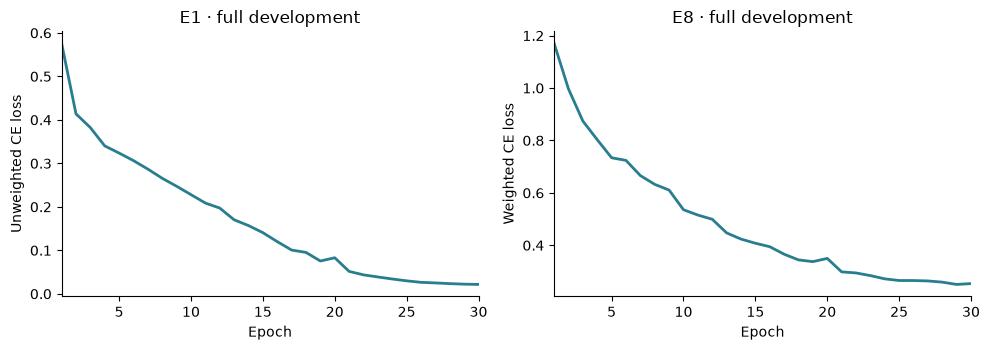

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, name, loss in zip(axes, ['E1', 'E8'], ['Unweighted CE', 'Weighted CE']):
    folder = TASK3_EVIDENCE_ROOT/f'usage_{name.lower()}_refit_20260907'
    history = pd.read_csv(folder/'history.csv', keep_default_na=False)
    assert history.epoch.tolist() == list(range(1, 31))
    assert history.training_rows.eq(32772).all()
    ax.plot(history.epoch, history.train_loss, color='#287d8e', linewidth=2)
    ax.set(xlabel='Epoch', ylabel=f'{loss} loss', title=f'{name} · full development',
           xlim=(1, 30))
fig.tight_layout()
fig.savefig(FIGURES/'usage_refit_training.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding.** E1's training loss falls from 0.5759 to 0.0216; E8's falls from 1.1703 to 0.2540.
Both fits complete their planned budget. E8 takes 8.81 minutes on an NVIDIA L4, compared with
E1's 8.32 minutes. These are recorded runs, not repeated hardware benchmarks.

There is no validation curve for either refit. Their earlier five-fold OOF scores belong to the
fold models; those scores cannot be assigned to these new checkpoints. Predicting development
rows with the refit would measure training exposure, not independent validation. Training loss
alone cannot show whether the known generalization gap or rare-class failures have improved.


### Retain the completed single E8 refit

**Final Usage model: the single teacher-only E8 refit, epoch 30.** The development
comparison above explains the recipe choice. The completed run implements that fixed recipe.

**Refitting puts the chosen recipe into one final model.** Train from scratch on all
**32,772 eligible teacher development rows**, using the fixed **30-epoch** schedule. Fit
normalization and class weights on those rows only. This uses all available development
examples, including the scarce labels, while retaining the tested training recipe. Epoch
30 is fixed; neither training loss nor a later score selects another checkpoint. The
completed training record confirms that this refit ran, not that it beats the fold models.
The scores, bootstrap intervals and robustness tests above belong to development fold
models and must not be assigned to the refit's weights. One checkpoint also gives a simple
inference package, but no measured application speedup is claimed.

#### Retained E8 recipe and evaluation handoff

**Frozen prediction recipe**

Use RGB at height 80 and width 60, EXIF orientation, aspect-preserving LANCZOS resize and
centred letterboxing. Apply the refit's saved full-development RGB mean and standard deviation,
with padding zeroed after normalization. Run this model in evaluation mode, apply softmax,
then choose the class with the largest probability. Keep all nine labels, including literal `NA`.
Translation and class weights apply during training only. Do not adjust prediction probabilities.

The model uses channels 32/64/128/256 and global average pooling, with no classifier dropout.
The fixed fit uses AdamW at 0.001, weight decay 0.0001, batch 128 and cosine decay over 30 epochs
to 0.00001. E8's class-weight settings are beta 0.999 and cap 5. Epoch 30 is final, not a best epoch.
The manifest pins the exact weights, class order, configuration, normalization and source hashes.


In [63]:
print('Final run:', usage_final_manifest['run_id'])
print('Checkpoint:', usage_final_manifest['checkpoint']['path'])
print('SHA-256:', usage_final_manifest['checkpoint']['sha256'])
print('Class order:', ', '.join(usage_final_manifest['class_names']))
print('Artifact: one scratch SmallCNN; epoch 30; 391,209 parameters')
usage_normalization = json.loads(
    (REPO_DIR/usage_final_manifest['normalization']['path']).read_text())
display(pd.DataFrame({'Channel': ['R', 'G', 'B'],
    'Mean': usage_normalization['mean'],
    'Standard deviation': usage_normalization['std']
}).set_index('Channel').round(6))


Final run: t3_usage_e8_translation_teacher_all_development_refit_5553be0c138243e9
Checkpoint: results/evidence/task3/usage_e8_refit_20260907/final_epoch.pt
SHA-256: 18da75a4ec935ab0d18c9ebdf9d1dabb6fa87ee484ead5f439de0192c4af2747
Class order: Casual, Ethnic, Formal, Home, NA, Party, Smart Casual, Sports, Travel
Artifact: one scratch SmallCNN; epoch 30; 391,209 parameters


,Mean,Standard deviation
Channel,,
R,0.849998,0.271110
G,0.833253,0.282661
B,0.827605,0.286203


**Limits and handoff.** Small and overlapping occasion classes still need careful review.
The development study uses one seed and repeated fold comparisons; it cannot prove a stable
ranking across future runs or new catalogues. A single refit reduces the number of forward passes,
but an application speedup has not been measured. The frozen model supports catalogue-tag
suggestions; the evidence does not establish reliable automatic tagging of every Usage class.


## 19. Development findings and limits

**Gender.** The full development comparison selects MixUp 0.20 with 30 epochs for the
single refit. Original-label five-fold F1 is 75.73%, compared with 71.18% for the baseline,
73.35% for GeM, 74.12% for early stopping, 74.51% for semantic filtering, 75.02% for translation
and 75.33% for SAM25. The remaining architectures and screens, including their different
folds and labels, are weighed in Section 14. Original-label accuracy is 0.32 points lower
than translation. The corrected-label matched audit gives 80.46% F1 versus SAM25's 79.73%,
129 fewer errors, better probability quality and higher F1 under all five tested corruptions.
The cost is a larger clean fit gap (13.37 versus 10.15 points), slightly more fold spread,
and greater relative damage in four corruption tests. Unisex remains weak.

The 100,000-draw paired family interval for the +0.74-point F1 gain crosses zero, as do the
additional-fold and original-label intervals. We choose the observed overall balance without
claiming certain superiority. The alternative models, probes and SAM gate results provide the comparison context.
The complete development evidence supports MixUp as the best observed balance among these
tested recipes, with the uncertainty and regressions stated above. The completed refit has no independent development score.

**Usage.** Class weighting improves supported minority classes; translation improves position
tolerance but leaves unstable rare-class gains and a darkening cost. E1 has the highest accuracy
among the original nine teacher-only experiments; E8 leads their macro-F1 comparison. On the
same teacher development rows, the 687-image expansion raises accuracy above E1, yet fails to
improve E8's macro-F1. Its strong outside-source recall does not carry to teacher Party and Smart
Casual. Later regularisation and photo replacements lower teacher validation F1. These results
show why neither extra complexity nor a smaller training gap is enough to establish progress.
The completed E1 and E8 refits use all eligible development rows. Their loss curves show training
completion, not new validation evidence. We retain E8 for its observed class coverage,
shift tolerance and probability quality while accepting the accuracy loss, worse dark-image
performance and uncertain clean lead over E2/E3. This is a judgement across development
trade-offs, not a claim that bootstrap or the original improvement gates proved E8 superior.
Refitting uses all development rows with the fixed recipe; it adds no new validation score.

**Remaining uncertainty.** Most comparisons use one seed and repeatedly consulted development
folds. Family resampling measures uncertainty within saved predictions, not variation across seeds
or the full cost of trying many recipes. Two-fold screens cannot be ranked against five-fold totals;
changed labels and source mixtures also require separate comparisons. Ambiguous images,
rare support and catalogue-specific cues remain competing explanations for the errors.

The development study therefore hands two fixed models to final evaluation with different
claims to test: a simpler Gender refit following the label and regularisation study, and a
Usage refit whose broader class coverage must be weighed against common-class errors. The
separate evaluation notebook assesses the selected refits.


## 20. References

[1] Y. Bengio and Y. Grandvalet, “No Unbiased Estimator of the Variance of K-Fold Cross-Validation,” *Journal of Machine Learning Research*, vol. 5, pp. 1089–1105, 2004.

[2] N. Dalal and B. Triggs, “Histograms of Oriented Gradients for Human Detection,” in *CVPR*, 2005. doi: 10.1109/CVPR.2005.177.

[3] D. Hendrycks and T. Dietterich, “Benchmarking Neural Network Robustness to Common Corruptions and Perturbations,” in *ICLR*, 2019. arXiv:1903.12261.

[4] F. Radenović, G. Tolias, and O. Chum, “Fine-Tuning CNN Image Retrieval with No Human Annotation,” *IEEE Transactions on Pattern Analysis and Machine Intelligence*, vol. 41, no. 7, pp. 1655–1668, 2019. doi: 10.1109/TPAMI.2018.2846566.

[5] K. He, X. Zhang, S. Ren, and J. Sun, “Deep Residual Learning for Image Recognition,” in *CVPR*, 2016. arXiv:1512.03385.

[6] R. Zhang, “Making Convolutional Networks Shift-Invariant Again,” in *ICML*, PMLR, vol. 97, pp. 7324–7334, 2019.

[7] K. Sun, B. Xiao, D. Liu, and J. Wang, “Deep High-Resolution Representation Learning for Human Pose Estimation,” in *CVPR*, 2019. arXiv:1902.09212.

[8] R. Caruana, “Multitask Learning,” *Machine Learning*, vol. 28, pp. 41–75, 1997. doi: 10.1023/A:1007379606734.

[9] T. Standley et al., “Which Tasks Should Be Learned Together in Multi-task Learning?,” in *ICML*, PMLR, vol. 119, pp. 9120–9132, 2020.

[10] I. Loshchilov and F. Hutter, “Decoupled Weight Decay Regularization,” in *ICLR*, 2019. arXiv:1711.05101.

[11] N. Srivastava et al., “Dropout: A Simple Way to Prevent Neural Networks from Overfitting,” *Journal of Machine Learning Research*, vol. 15, pp. 1929–1958, 2014.

[12] C. G. Northcutt, L. Jiang, and I. L. Chuang, “Confident Learning: Estimating Uncertainty in Dataset Labels,” *Journal of Artificial Intelligence Research*, vol. 70, pp. 1373–1411, 2021. doi: 10.1613/jair.1.12125.

[13] H. Zhang, M. Cisse, Y. N. Dauphin, and D. Lopez-Paz, “mixup: Beyond Empirical Risk Minimization,” in *ICLR*, 2018. arXiv:1710.09412.

[14] P. Foret, A. Kleiner, H. Mobahi, and B. Neyshabur, “Sharpness-Aware Minimization for Efficiently Improving Generalization,” in *ICLR*, 2021. arXiv:2010.01412.

[15] Y. Cui, M. Jia, T.-Y. Lin, Y. Song, and S. Belongie, “Class-Balanced Loss Based on Effective Number of Samples,” in *CVPR*, 2019. arXiv:1901.05555.

[16] Z. Liu et al., “A ConvNet for the 2020s,” in *CVPR*, 2022. arXiv:2201.03545.

[17] T.-Y. Lin et al., “Focal Loss for Dense Object Detection,” in *ICCV*, 2017. arXiv:1708.02002.

[18] S. Sagawa, P. W. Koh, T. B. Hashimoto, and P. Liang, “Distributionally Robust Neural Networks for Group Shifts: On the Importance of Regularization for Worst-Case Generalization,” in *ICLR*, 2020. arXiv:1911.08731.

[19] C. Szegedy et al., “Rethinking the Inception Architecture for Computer Vision,” in *CVPR*, 2016. arXiv:1512.00567.

[20] C. Guo, G. Pleiss, Y. Sun, and K. Q. Weinberger, “On Calibration of Modern Neural Networks,” in *ICML*, PMLR, vol. 70, pp. 1321–1330, 2017.
